# Batch Run

Below is a notebook used for analyzing numeric behaviors from batch runs of Higgs and Deformed Quadratic Inflationary Potentials. 

In [183]:
import sys
import os
import glob
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numdifftools as nd
import pygsl.rng

from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib import colors as mcolors
from matplotlib.ticker import ScalarFormatter

from scipy.integrate import (
    solve_ivp,
    odeint,
    cumulative_trapezoid,
)

from scipy.interpolate import (
    UnivariateSpline,
    splrep,
    splev,
    CubicSpline,
    interp1d,
    PchipInterpolator,
    InterpolatedUnivariateSpline,
)

INFLATION_MODELS_PATH = Path(
    "/Users/epmeador/Desktop/research/rwarthur/"
    "inflation_gravitywaves/inflation_code/InflationModels"
)

if str(INFLATION_MODELS_PATH) not in sys.path:
    sys.path.append(str(INFLATION_MODELS_PATH))

## Grabbing the Models

In [184]:
base_path_root = Path(
    "/Users/epmeador/Desktop/research/rwarthur/"
    "inflation_gravitywaves/inflation_code/"
    "Slow-Roll Parameters Tests/higgs_potential_tests"
)

MODEL_TAGS = {
    "higgs": "higgs",
    "nonhiggs": "nonhiggs",
}

SCAN_INFO = {
    5: ("lam2",  r"\lambda_2"),
    6: ("lam3",  r"\lambda_3"),
    7: ("lam4",  r"\lambda_4"),
    8: ("lam5",  r"\lambda_5"),
    9: ("lam6",  r"\lambda_6"),
    10: ("lam7", r"\lambda_7"),
    11: ("lam8", r"\lambda_8"),
    12: ("lam9", r"\lambda_9"),
    13: ("lam10", r"\lambda_{10}"),
}

colors = {
    5: "pink",
    6: "turquoise",
    7: "plum",
    8: "mediumslateblue",
    9: "blue",
}

## Loading Models from Batch:

In [185]:
def validate_model_tag(model_tag):
    """Check that the requested model tag is supported."""
    if model_tag not in MODEL_TAGS:
        raise ValueError(
            f"Unknown model_tag={model_tag!r}. "
            f"Choose from {list(MODEL_TAGS)}."
        )


def batch_dirs_for(
    NEQS,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Return all batch directories for a given model and NEQS."""
    validate_model_tag(model_tag)

    base_path_root = Path(base_path_root)

    pattern = (
        base_path_root
        / f"neqs{NEQS}_{model_tag}_batch*"
    )

    return sorted(Path(p) for p in glob.glob(str(pattern)))


def folder_for(
    NEQS,
    param_name,
    value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """
    Locate the saved model directory corresponding to a parameter value.
    """
    val_str = f"{value:.10e}"

    for batch_dir in batch_dirs_for(
        NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        folder = batch_dir / f"{param_name}_{val_str}"

        if folder.exists():
            return folder

    raise FileNotFoundError(
        f"Missing folder for {param_name}_{val_str} in "
        f"neqs{NEQS}_{model_tag}_batch*"
    )


def load_path_data(
    NEQS,
    param_name,
    value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Load the saved background trajectory for one model."""
    val_str = f"{value:.10e}"

    folder = folder_for(
        NEQS,
        param_name,
        value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    file_path = (
        folder
        / f"path_neqs{NEQS}_{param_name}_{val_str}.dat"
    )

    if not file_path.exists():
        raise FileNotFoundError(
            f"Path file does not exist: {file_path}"
        )

    return pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None,
    ).values


def load_specs(
    NEQS,
    param_name,
    value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Load scalar and tensor spectra for one saved model."""
    folder = folder_for(
        NEQS,
        param_name,
        value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    scalar_file = folder / f"spec_s_neqs{NEQS}.dat"
    tensor_file = folder / f"spec_t_neqs{NEQS}.dat"

    if not scalar_file.exists():
        raise FileNotFoundError(
            f"Scalar spectrum file does not exist: {scalar_file}"
        )

    if not tensor_file.exists():
        raise FileNotFoundError(
            f"Tensor spectrum file does not exist: {tensor_file}"
        )

    scalar_data = np.loadtxt(scalar_file)
    tensor_data = np.loadtxt(tensor_file)

    k_s = scalar_data[:, 0]
    Ps = np.abs(scalar_data[:, 1])

    k_t = tensor_data[:, 0]
    Pt = np.abs(tensor_data[:, 1])

    return k_s, Ps, k_t, Pt


def get_base_dir(
    NEQS,
    param_name,
    base_value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Locate the directory containing a chosen base model."""
    return folder_for(
        NEQS,
        param_name,
        base_value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )


def get_param_values_from_dirs(
    NEQS,
    param_name,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
    show_summary=True,
):
    """
    Extract parameter values from all saved model-directory names.

    Returns
    -------
    list of tuple
        Each tuple contains `(value, label)`.
    """
    values = []

    for batch_dir in batch_dirs_for(
        NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        pattern = batch_dir / f"{param_name}_*"

        for folder in glob.glob(str(pattern)):
            folder = Path(folder)

            if not folder.is_dir():
                continue

            try:
                folder_name = folder.name

                value_string = folder_name.replace(
                    f"{param_name}_",
                    "",
                    1,
                )

                # Handles names such as:
                # lam5_-1.234e-05_trial_000123
                value_string = value_string.split("_trial_")[0]

                value = float(value_string)
                label = rf"${param_name} = {value:.1e}$"

                values.append((value, label))

            except ValueError as exc:
                print(f"Skipping {folder}: {exc}")

    # Remove duplicate parameter values.
    unique_values = {}

    for value, label in values:
        unique_values[value] = label

    values = sorted(
        unique_values.items(),
        key=lambda item: item[0],
    )

    if show_summary:
        print("\n" + "=" * 60)
        print(
            f"Summary for model={model_tag}, "
            f"NEQS={NEQS}, parameter={param_name}"
        )
        print("=" * 60)
        print(f"Total models found: {len(values)}")

        if values:
            print(
                "Parameter range: "
                f"{values[0][0]:.3e} to {values[-1][0]:.3e}"
            )
        else:
            print("Parameter range: none found")

        print("=" * 60 + "\n")

    return values

## Re-used Functions:

In [186]:
def prepare_increasing(x, y):
    """
    Sort paired arrays by increasing x.

    Duplicate x values are retained.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.shape != y.shape:
        raise ValueError(
            f"x and y must have the same shape; got {x.shape} and {y.shape}"
        )

    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]

    if len(x) == 0:
        raise ValueError("No finite data points remain.")

    order = np.argsort(x)

    return x[order], y[order]


def normalize_curve_at_Nref(
    N,
    Y,
    N_ref=60.0,
    ref_floor=1e-20,
):
    """
    Normalize a curve Y(N) by its value at N_ref.
    """
    N_use, Y_use = prepare_increasing(N, Y)

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range "
            f"[{N_use.min():.6g}, {N_use.max():.6g}]"
        )

    Y_ref = np.interp(N_ref, N_use, Y_use)

    if not np.isfinite(Y_ref):
        raise ValueError(
            f"Non-finite reference value at N_ref={N_ref}"
        )

    if np.abs(Y_ref) < ref_floor:
        raise ValueError(
            f"Reference value is too small at N_ref={N_ref}: "
            f"{Y_ref:.3e}"
        )

    return N_use, Y_use / Y_ref, Y_ref


def normalize_at_ref(
    k,
    P,
    k_ref=0.05,
    ref_floor=1e-30,
):
    """
    Normalize a spectrum P(k) by its value at k_ref.
    """
    k_use, P_use = prepare_increasing(k, P)

    if not (k_use.min() <= k_ref <= k_use.max()):
        raise ValueError(
            f"k_ref={k_ref} outside range "
            f"[{k_use.min():.3e}, {k_use.max():.3e}]"
        )

    P_ref = np.interp(k_ref, k_use, P_use)

    if not np.isfinite(P_ref):
        raise ValueError(
            f"Non-finite spectrum value at k_ref={k_ref}"
        )

    if np.abs(P_ref) < ref_floor:
        raise ValueError(
            f"Spectrum reference is too small at k_ref={k_ref}: "
            f"{P_ref:.3e}"
        )

    return k_use, P_use / P_ref, P_ref


def fractional_difference_on_overlap(
    x,
    y,
    x_ref,
    y_ref,
    frac_floor=1e-30,
):
    """
    Compute (y - y_ref) / y_ref over the shared x-domain.

    The reference curve is interpolated onto the model's x-grid.
    """
    x_use_all, y_use_all = prepare_increasing(x, y)
    x_ref_use, y_ref_use = prepare_increasing(x_ref, y_ref)

    xmin = max(x_use_all.min(), x_ref_use.min())
    xmax = min(x_use_all.max(), x_ref_use.max())

    if xmin >= xmax:
        return np.array([]), np.array([])

    mask = (
        (x_use_all >= xmin)
        & (x_use_all <= xmax)
    )

    x_use = x_use_all[mask]
    y_use = y_use_all[mask]

    if len(x_use) == 0:
        return np.array([]), np.array([])

    y_ref_interp = np.interp(
        x_use,
        x_ref_use,
        y_ref_use,
    )

    valid_ref = np.abs(y_ref_interp) > frac_floor

    frac = np.full_like(y_use, np.nan, dtype=float)

    frac[valid_ref] = (
        y_use[valid_ref] - y_ref_interp[valid_ref]
    ) / y_ref_interp[valid_ref]

    return x_use, frac

## Identify Available Models

For both model families, loop through the operations and read out the models I have for both.

In [187]:
MODEL_CONFIG = {
    "higgs": {
        "label": "Higgs",
        "lam_base": {
            8: ("lam5", -8.92461e-9),
        },
    },

    "nonhiggs": {
        "label": "Deformed Quadratic",
        "lam_base": {
            8: ("lam5", -3.3792701497e-05),
        },
    },
}

base_dirs_by_model = {}
param_values_by_model = {}
batch_dirs_by_model = {}
batch_counts_by_model = {}

In [188]:
for model_tag, config in MODEL_CONFIG.items():

    print("\n" + "=" * 70)
    print(f"Loading {config['label']} models")
    print("=" * 70)

    # --------------------------------------------------
    # Find fiducial/base-model directories
    # --------------------------------------------------

    base_dirs_by_model[model_tag] = {}

    for NEQS, (param_name, base_val) in config["lam_base"].items():

        folder = get_base_dir(
            NEQS=NEQS,
            param_name=param_name,
            base_value=base_val,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )

        base_dirs_by_model[model_tag][NEQS] = {
            "param_name": param_name,
            "value": base_val,
            "folder": folder,
        }

        print(
            f"{config['label']} base model: "
            f"NEQS={NEQS}, "
            f"{param_name}={base_val:.10e}"
        )
        print(f"  {folder}")

    # --------------------------------------------------
    # Find all scanned parameter values
    # --------------------------------------------------

    param_values_by_model[model_tag] = {}

    for NEQS, (param_name, _) in config["lam_base"].items():

        values = get_param_values_from_dirs(
            NEQS=NEQS,
            param_name=param_name,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )

        param_values_by_model[model_tag][NEQS] = values

    # --------------------------------------------------
    # Find batch directories
    # --------------------------------------------------

    batch_dirs_by_model[model_tag] = {}
    batch_counts_by_model[model_tag] = {}

    for NEQS, (param_name, _) in config["lam_base"].items():

        batch_dirs = batch_dirs_for(
            NEQS=NEQS,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )

        batch_dirs_by_model[model_tag][NEQS] = batch_dirs
        batch_counts_by_model[model_tag][NEQS] = {}

        print(f"\nBatch directories for {config['label']}, NEQS={NEQS}:")

        for batch_dir in batch_dirs:
            print(f"  {batch_dir}")

        # --------------------------------------------------
        # Count model directories in each batch
        # --------------------------------------------------

        print(f"\nModels per batch for {config['label']}, NEQS={NEQS}:")

        for batch_dir in batch_dirs:

            pattern = os.path.join(
                str(batch_dir),
                f"{param_name}_*",
            )

            model_dirs = [
                folder
                for folder in glob.glob(pattern)
                if os.path.isdir(folder)
            ]

            count = len(model_dirs)
            batch_name = os.path.basename(str(batch_dir))

            batch_counts_by_model[model_tag][NEQS][batch_name] = count

            print(f"  {batch_name}: {count}")


Loading Higgs models
Higgs base model: NEQS=8, lam5=-8.9246100000e-09
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8_higgs_batch001/lam5_-8.9246100000e-09

Summary for model=higgs, NEQS=8, parameter=lam5
Total models found: 120
Parameter range: -4.982e-05 to 1.791e-05


Batch directories for Higgs, NEQS=8:
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8_higgs_batch001
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8_higgs_batch002
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8_higgs_batch003

Models per batch for Higgs, NEQS=8:
  neqs8_higgs_batch001: 40
  neqs8_higgs_batch002: 40
  neqs8_higgs_batch003: 40

Loading Deformed Quadratic

## Examine $\Delta N$

In [189]:
def plot_deltaN_histogram_neqs8(
    base_path_root,
    base8_value,
    model_tag,
    ns_min=None,
    ns_max=None,
    r_min=None,
    r_max=None,
    max_abs_alpha_s=None,
    bins=30,
    deltaN_guides=None,
    save_name=None,
    show=True,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 13,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    NEQS = 8
    param_name = "lam5"

    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)

    # --------------------------------------------------
    # Load all batch summaries
    # --------------------------------------------------

    df = load_batch_summaries(
        NEQS=NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ).copy()

    required_columns = {
        param_name,
        "n_s",
        "r",
        "alpha_s",
        "original_N_end",
    }

    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise ValueError(
            f"Missing required summary columns for {model_tag}: "
            f"{sorted(missing_columns)}"
        )

    # Remove unusable rows.
    df = df[
        np.isfinite(df["original_N_end"])
        & np.isfinite(df[param_name])
    ].copy()

    # --------------------------------------------------
    # Locate reference model
    # --------------------------------------------------

    base_mask = np.isclose(
        df[param_name].to_numpy(dtype=float),
        base8_value,
        rtol=1e-8,
        atol=max(1e-15, abs(base8_value) * 1e-8),
    )

    base_rows = df.loc[base_mask]

    if base_rows.empty:
        available = df[param_name].to_numpy(dtype=float)

        if len(available) == 0:
            raise ValueError(
                f"No finite {param_name} values found for {model_tag}."
            )

        closest_index = np.argmin(
            np.abs(available - base8_value)
        )

        closest_value = available[closest_index]

        raise ValueError(
            f"Could not find base {param_name}={base8_value:.10e} "
            f"in neqs{NEQS}_{model_tag}_batch* summaries. "
            f"Closest value found: {closest_value:.10e}"
        )

    if len(base_rows) > 1:
        print(
            f"Warning: found {len(base_rows)} matching reference rows "
            f"for {model_label}. Using the first one."
        )

    base_N_end = float(
        base_rows.iloc[0]["original_N_end"]
    )

    # --------------------------------------------------
    # Calculate delta N
    # --------------------------------------------------

    df["deltaN_from_base"] = (
        df["original_N_end"] - base_N_end
    )

    df["abs_deltaN_from_base"] = np.abs(
        df["deltaN_from_base"]
    )

    # --------------------------------------------------
    # Apply observable cuts
    # --------------------------------------------------

    if ns_min is not None:
        df = df[df["n_s"] >= ns_min].copy()

    if ns_max is not None:
        df = df[df["n_s"] <= ns_max].copy()

    if r_min is not None:
        df = df[df["r"] >= r_min].copy()

    if r_max is not None:
        df = df[df["r"] <= r_max].copy()

    if max_abs_alpha_s is not None:
        df = df[
            np.abs(df["alpha_s"]) <= max_abs_alpha_s
        ].copy()

    if df.empty:
        raise ValueError(
            f"No {model_label} models remain after applying cuts."
        )

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(10, 6.5),
        constrained_layout=True,
    )

    ax.hist(
        df["deltaN_from_base"],
        bins=bins,
        alpha=0.78,
        edgecolor="black",
        linewidth=0.9,
    )

    ax.axvline(
        0.0,
        color="black",
        linestyle="--",
        linewidth=2.0,
        label="Reference model",
    )

    if deltaN_guides is not None:
        for index, guide in enumerate(deltaN_guides):
            ax.axvline(
                guide,
                color="gray",
                linestyle=":",
                linewidth=1.6,
                label=(
                    r"$|\Delta N|$ guide"
                    if index == 0
                    else None
                ),
            )

    ax.set_xlabel(
        r"$\Delta N_{\rm end}"
        r"=N_{\rm end}-N_{\rm end,ref}$"
    )

    ax.set_ylabel("Number of models")
    ax.grid(True, alpha=0.25)

    # --------------------------------------------------
    # Construct title
    # --------------------------------------------------

    cuts = []

    if ns_min is not None and ns_max is not None:
        cuts.append(
            rf"${ns_min:g}\leq n_s\leq {ns_max:g}$"
        )
    elif ns_min is not None:
        cuts.append(rf"$n_s\geq {ns_min:g}$")
    elif ns_max is not None:
        cuts.append(rf"$n_s\leq {ns_max:g}$")

    if r_min is not None and r_max is not None:
        cuts.append(
            rf"${r_min:.4g}\leq r\leq {r_max:.4g}$"
        )
    elif r_min is not None:
        cuts.append(rf"$r\geq {r_min:.4g}$")
    elif r_max is not None:
        cuts.append(rf"$r\leq {r_max:.4g}$")

    if max_abs_alpha_s is not None:
        cuts.append(
            rf"$|\alpha_s|\leq {max_abs_alpha_s:g}$"
        )

    title = (
        rf"{model_label}: distribution of "
        rf"$\Delta N_{{\rm end}}$"
    )

    if cuts:
        title += "\n" + ", ".join(cuts)

    ax.set_title(title)

    ax.legend(
        frameon=False,
        loc="best",
    )

    # --------------------------------------------------
    # Short console summary
    # --------------------------------------------------

    print("\n" + "=" * 60)
    print(f"{model_label} (NEQS={NEQS})")
    print("=" * 60)

    print(f"Models passing cuts : {len(df)}")
    print(f"Reference N_end     : {base_N_end:.6f}")
    print(
        f"Median |ΔN|         : "
        f"{df['abs_deltaN_from_base'].median():.3f}"
    )
    print(
        f"Mean |ΔN|           : "
        f"{df['abs_deltaN_from_base'].mean():.3f}"
    )
    print(
        f"Maximum |ΔN|        : "
        f"{df['abs_deltaN_from_base'].max():.3f}"
    )

    # --------------------------------------------------
    # Save or display
    # --------------------------------------------------

    if save_name is None:
        save_name = (
            f"deltaN_histogram_neqs8_"
            f"{model_tag}_batches.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return df

*Load batch summaries is needed for $\Delta N$ plot*

In [190]:
def load_batch_summaries(
    NEQS,
    base_path_root,
    model_tag="higgs",
):
    """
    Load and combine all summary CSV files for one model family.
    """
    summary_files = []

    for batch_dir in batch_dirs_for(
        NEQS=NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        summary_file = os.path.join(
            str(batch_dir),
            f"neqs{NEQS}_summary.csv",
        )

        if os.path.exists(summary_file):
            summary_files.append(summary_file)

    if len(summary_files) == 0:
        raise FileNotFoundError(
            f"No summary files found for "
            f"NEQS={NEQS}, model_tag={model_tag}"
        )

    dfs = []

    for summary_file in summary_files:
        df = pd.read_csv(summary_file)

        df["summary_file"] = summary_file
        df["batch_dir"] = os.path.basename(
            os.path.dirname(summary_file)
        )

        dfs.append(df)

    return pd.concat(
        dfs,
        ignore_index=True,
    )

### For Higgs:


Higgs (NEQS=8)
Models passing cuts : 120
Reference N_end     : 946.349733
Median |ΔN|         : 6.974
Mean |ΔN|           : 6.706
Maximum |ΔN|        : 11.517


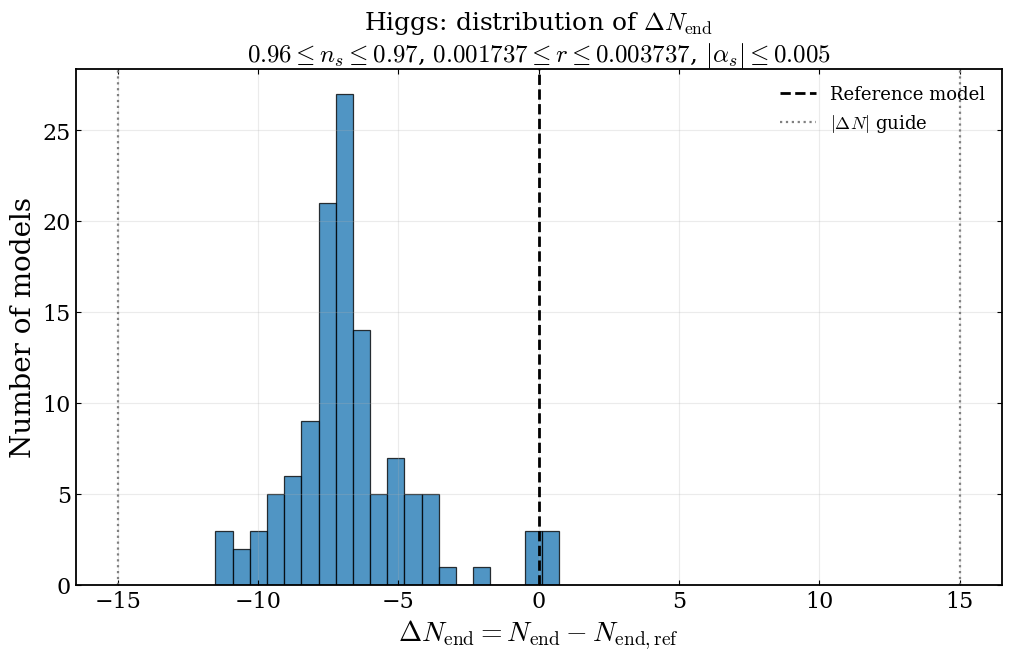

In [191]:
df_deltaN_higgs = plot_deltaN_histogram_neqs8(
    base_path_root=base_path_root,
    base8_value=MODEL_CONFIG["higgs"]["lam_base"][8][1],
    model_tag="higgs",
    ns_min=0.96,
    ns_max=0.97,
    r_min=2.737e-3 - 0.001,
    r_max=2.737e-3 + 0.001,
    max_abs_alpha_s=0.005,
    bins=20,
    deltaN_guides=[-15, 15],
    save_name="neqs8_higgs_deltaN_histogram.pdf",
)

### For Deformed Quadratic:


Deformed Quadratic (NEQS=8)
Models passing cuts : 120
Reference N_end     : 941.156262
Median |ΔN|         : 1.359
Mean |ΔN|           : 1.377
Maximum |ΔN|        : 2.780


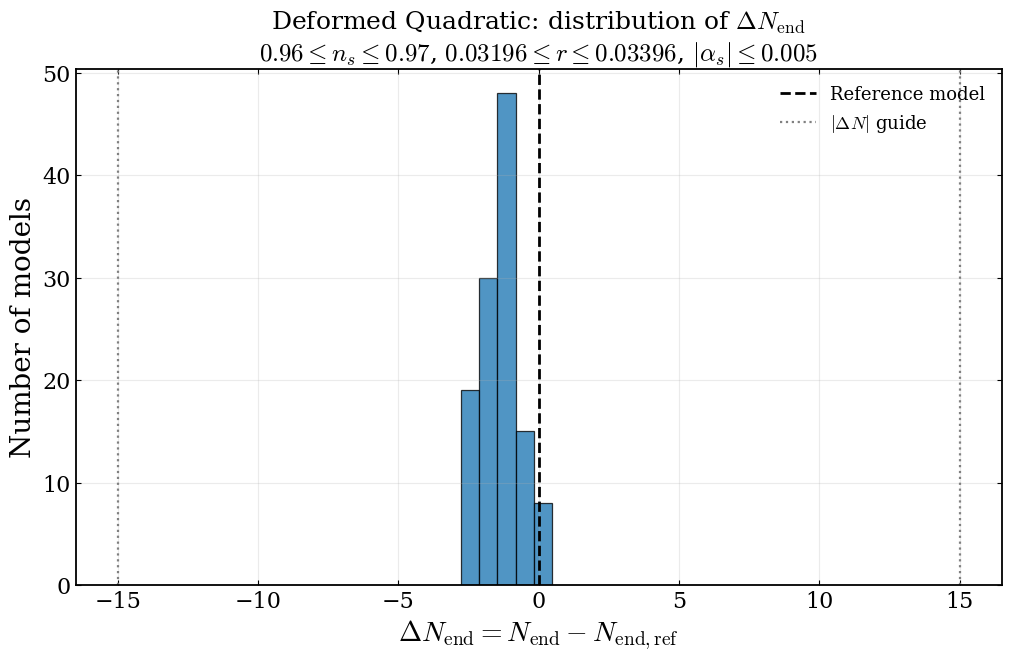

In [192]:
df_deltaN_nonhiggs = plot_deltaN_histogram_neqs8(
    base_path_root=base_path_root,
    base8_value=MODEL_CONFIG["nonhiggs"]["lam_base"][8][1],
    model_tag="nonhiggs",
    ns_min=0.96,
    ns_max=0.97,
    r_min=3.2958886892e-2 - 0.001,
    r_max=3.2958886892e-2 + 0.001,
    max_abs_alpha_s=0.005,
    bins=5,
    deltaN_guides=[-15, 15],
    save_name="neqs8_nonhiggs_deltaN_histogram.pdf",
)

## Examine Unshifted Scalar and Tensor Power Spectra

In [193]:
def plot_filtered_spectra_by_ns_colored_by_Nend(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    model_tag="higgs",
    ns_min=0.955,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_min_scalar=None,
    k_max_scalar=10.0,
    Nend_min=None,
    Nend_max=None,
    cmap_name="plasma",
    save_name=None,
    show=True,
):

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 22,
        "axes.titlesize": 20,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 15,
        "figure.titlesize": 24,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    scan_name, scan_symbol = SCAN_INFO[NEQS]
    
    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float,
        )

    def load_observables_from_summary(value):
        summary_all = load_batch_summaries(
            NEQS,
            base_path_root,
            model_tag=model_tag
        )

        row_match = summary_all.loc[
            np.isclose(summary_all[scan_name], value)
        ]

        if len(row_match) == 0:
            raise FileNotFoundError(
                f"No summary row found for {scan_name}={value:.10e}"
            )

        row = row_match.iloc[0]

        return (
            row["r"],
            row["n_s"],
            row["alpha_s"],
            row["original_N_end"],
        )

    def load_specs_batch(value):
        folder = folder_for(
            NEQS=NEQS,
            param_name=scan_name,
            value=value,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        return k_s, Ps, k_t, Pt

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)

        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            order = np.argsort(x)
            return x[order], y[order]

    def normalize_at_ref_local(x, y, x_ref):
        x, y = prepare_increasing(x, y)

        if not (np.min(x) <= x_ref <= np.max(x)):
            raise ValueError(
                f"k_ref={x_ref} outside range [{np.min(x):.4e}, {np.max(x):.4e}]"
            )

        y_ref = np.interp(x_ref, x, y)

        if np.abs(y_ref) < 1e-30:
            raise ValueError(f"Reference value too small at k_ref={x_ref}")

        return x, y / y_ref

    def scalar_k_mask(k):
        mask = np.ones_like(k, dtype=bool)

        if k_min_scalar is not None:
            mask &= k >= k_min_scalar

        if k_max_scalar is not None:
            mask &= k <= k_max_scalar

        return mask

    def frac_on_base_grid(
        x_base,
        y_base,
        x_cmp,
        y_cmp,
        xmin=None,
        xmax=None,
    ):
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xlo = max(np.min(x_base), np.min(x_cmp))
        xhi = min(np.max(x_base), np.max(x_cmp))

        if xmin is not None:
            xlo = max(xlo, xmin)

        if xmax is not None:
            xhi = min(xhi, xmax)

        mask = (x_base >= xlo) & (x_base <= xhi)

        x_use = x_base[mask]
        y_base_use = y_base[mask]

        if len(x_use) == 0:
            raise ValueError(
                f"No overlapping k-values in requested range [{xlo:.4e}, {xhi:.4e}]"
            )

        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        frac = (y_cmp_interp - y_base_use) / y_base_use

        return x_use, frac

    lam_vals = sanitize_lam_values(lamX_values)
    
    #Loading that ref model and its spectra that are normalized

    r_base, ns_base, alpha_base, Nend_base = load_observables_from_summary(baseX) 

    k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs_batch(baseX)

    k_s_base, Ps_base_norm = normalize_at_ref_local(
        k_s_base_raw,
        Ps_base_raw,
        k_ref
    )

    k_t_base, Pt_base_norm = normalize_at_ref_local(
        k_t_base_raw,
        Pt_base_raw,
        k_ref
    )

    #then for all lamX values it will load same observables and original Nend
    #every spectra gets dividided by its own value at 0.05, using normalize_at_ref_local
    
    rows = []
    kept_models = [] #defining models we will keep

    for lamX in lam_vals:
        try:
            r, ns, alpha_s, N_end = load_observables_from_summary(lamX)

            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_batch(lamX)

            k_s, Ps_norm = normalize_at_ref_local(k_s_raw, Ps_raw, k_ref)
            k_t, Pt_norm = normalize_at_ref_local(k_t_raw, Pt_raw, k_ref)

            #we then compare that model to the base and get frac ps and pt
            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base,
                Ps_base_norm,
                k_s,
                Ps_norm,
                xmin=k_min_scalar,
                xmax=k_max_scalar,
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base,
                Pt_base_norm,
                k_t,
                Pt_norm,
                xmin=None,
                xmax=None,
            )

            #then we store stats in terms of percentages
            mean_dPs_pct = 100.0 * np.nanmean(frac_ps)
            max_dPs_pct = 100.0 * np.nanmax(np.abs(frac_ps))
            mean_dPt_pct = 100.0 * np.nanmean(frac_pt)
            max_dPt_pct = 100.0 * np.nanmax(np.abs(frac_pt))

            #apply ns cut here
            keep_ns = ns_min <= ns <= ns_max

            #and N cut here
            keep_Nend = True

            if Nend_min is not None:
                keep_Nend &= N_end >= Nend_min

            if Nend_max is not None:
                keep_Nend &= N_end <= Nend_max

            keep = keep_ns and keep_Nend

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "original_N_end": N_end,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "mean_dPs_pct": mean_dPs_pct,
                "max_dPs_pct": max_dPs_pct,
                "mean_dPt_pct": mean_dPt_pct,
                "max_dPt_pct": max_dPt_pct,
                "kept_by_ns_cut": keep_ns,
                "kept_by_Nend_cut": keep_Nend,
                "kept": keep,
            }

            rows.append(row)
#as long as keep is true and it is, we save all vals for the models
            if keep:
                kept_models.append({
                    **row,
                    "k_s": k_s,
                    "Ps_norm": Ps_norm,
                    "k_t": k_t,
                    "Pt_norm": Pt_norm,
                    "k_ps_err": k_ps_err,
                    "frac_ps": frac_ps,
                    "k_pt_err": k_pt_err,
                    "frac_pt": frac_pt,
                })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns") #sort by ns values
    kept_df = stats_df[stats_df["kept"]].copy()

    print("\n=== All models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Base original_N_end: {Nend_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {stats_df['kept_by_ns_cut'].sum()}")
    print(f"Models kept after all cuts: {len(kept_df)}")

    if len(kept_models) == 0:
        print("No models passed the cuts.")
        return stats_df, kept_df
    #Makes an array for all Nend that are kept
    Nends_kept = np.array([m["original_N_end"] for m in kept_models]) #m is just one model in kept_models

    cmap = plt.get_cmap(cmap_name)
    #create our color scale from Nends
    norm = mcolors.Normalize(
        vmin=np.nanmin(Nends_kept),
        vmax=np.nanmax(Nends_kept),
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    for m in kept_models:
        color = cmap(norm(m["original_N_end"]))

        mask_ps_plot = scalar_k_mask(m["k_s"])

        ax_ps.loglog(
            m["k_s"][mask_ps_plot],
            m["Ps_norm"][mask_ps_plot],
            color=color,
            lw=1.8,
            alpha=0.85,
        )

        ax_pt.loglog(
            m["k_t"],
            m["Pt_norm"],
            color=color,
            lw=1.8,
            alpha=0.85,
        )

        ax_ps_err.semilogx(
            m["k_ps_err"],
            100.0 * m["frac_ps"],
            color=color,
            lw=1.5,
            alpha=0.85,
        )

        ax_pt_err.semilogx(
            m["k_pt_err"],
            100.0 * m["frac_pt"],
            color=color,
            lw=1.5,
            alpha=0.85,
        )

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=axes, pad=0.02)
    cbar.set_label(r"$N_{\rm end}^{\rm original}$")
    cbar.ax.tick_params(direction="in")

    mask_base_s = scalar_k_mask(k_s_base)

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=0.8,
            alpha=0.6,
        )

    ax_ps.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax_pt.axvline(k_ref, color="black", ls=":", alpha=0.7)

    ax_ps.set_title(
        rf"Filtered normalized scalar spectra: $P_s/P_s({k_ref})$"
    )
    ax_pt.set_title(
        rf"Filtered normalized tensor spectra: $P_t/P_t({k_ref})$"
    )
    ax_ps_err.set_title(r"Filtered scalar fractional error")
    ax_pt_err.set_title(r"Filtered tensor fractional error")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(r"$P_s/P_s(k_{\rm ref})$")
    ax_pt.set_ylabel(r"$P_t/P_t(k_{\rm ref})$")
    ax_ps_err.set_ylabel(r"$100\times\Delta P_s/P_{s,\rm base}$")
    ax_pt_err.set_ylabel(r"$100\times\Delta P_t/P_{t,\rm base}$")

    xmin_scalar = (
        k_min_scalar
        if k_min_scalar is not None
        else np.min(k_s_base[mask_base_s])
    )

    xmax_scalar = (
        k_max_scalar
        if k_max_scalar is not None
        else np.max(k_s_base[mask_base_s])
    )

    ax_ps.set_xlim(xmin_scalar, xmax_scalar)
    ax_ps_err.set_xlim(xmin_scalar, xmax_scalar)

    for ax in axes.ravel():
        ax.grid(True, alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=15)

    fig.suptitle(
        rf"NEQS={NEQS} {model_label} models with "
        rf"${ns_min} \leq n_s \leq {ns_max}$, "
        rf"colored by $N_{{\rm end}}^{{\rm original}}$",
        fontsize=24,
    )

    if save_name is None:
        save_name = (
            f"neqs{NEQS}_{scan_name}_filtered_ns_"
            f"colored_by_original_Nend.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )
    
    if show:
        plt.show()
    else:
        plt.close(fig)

    kept_df = kept_df.sort_values("original_N_end")


    return stats_df, kept_df


Running N_end-colored spectra: Higgs

=== All models summary ===
Total loaded: 120
Base ns: 0.969485
Base original_N_end: 946.349733
Models in ns window [0.96, 0.97]: 120
Models kept after all cuts: 120


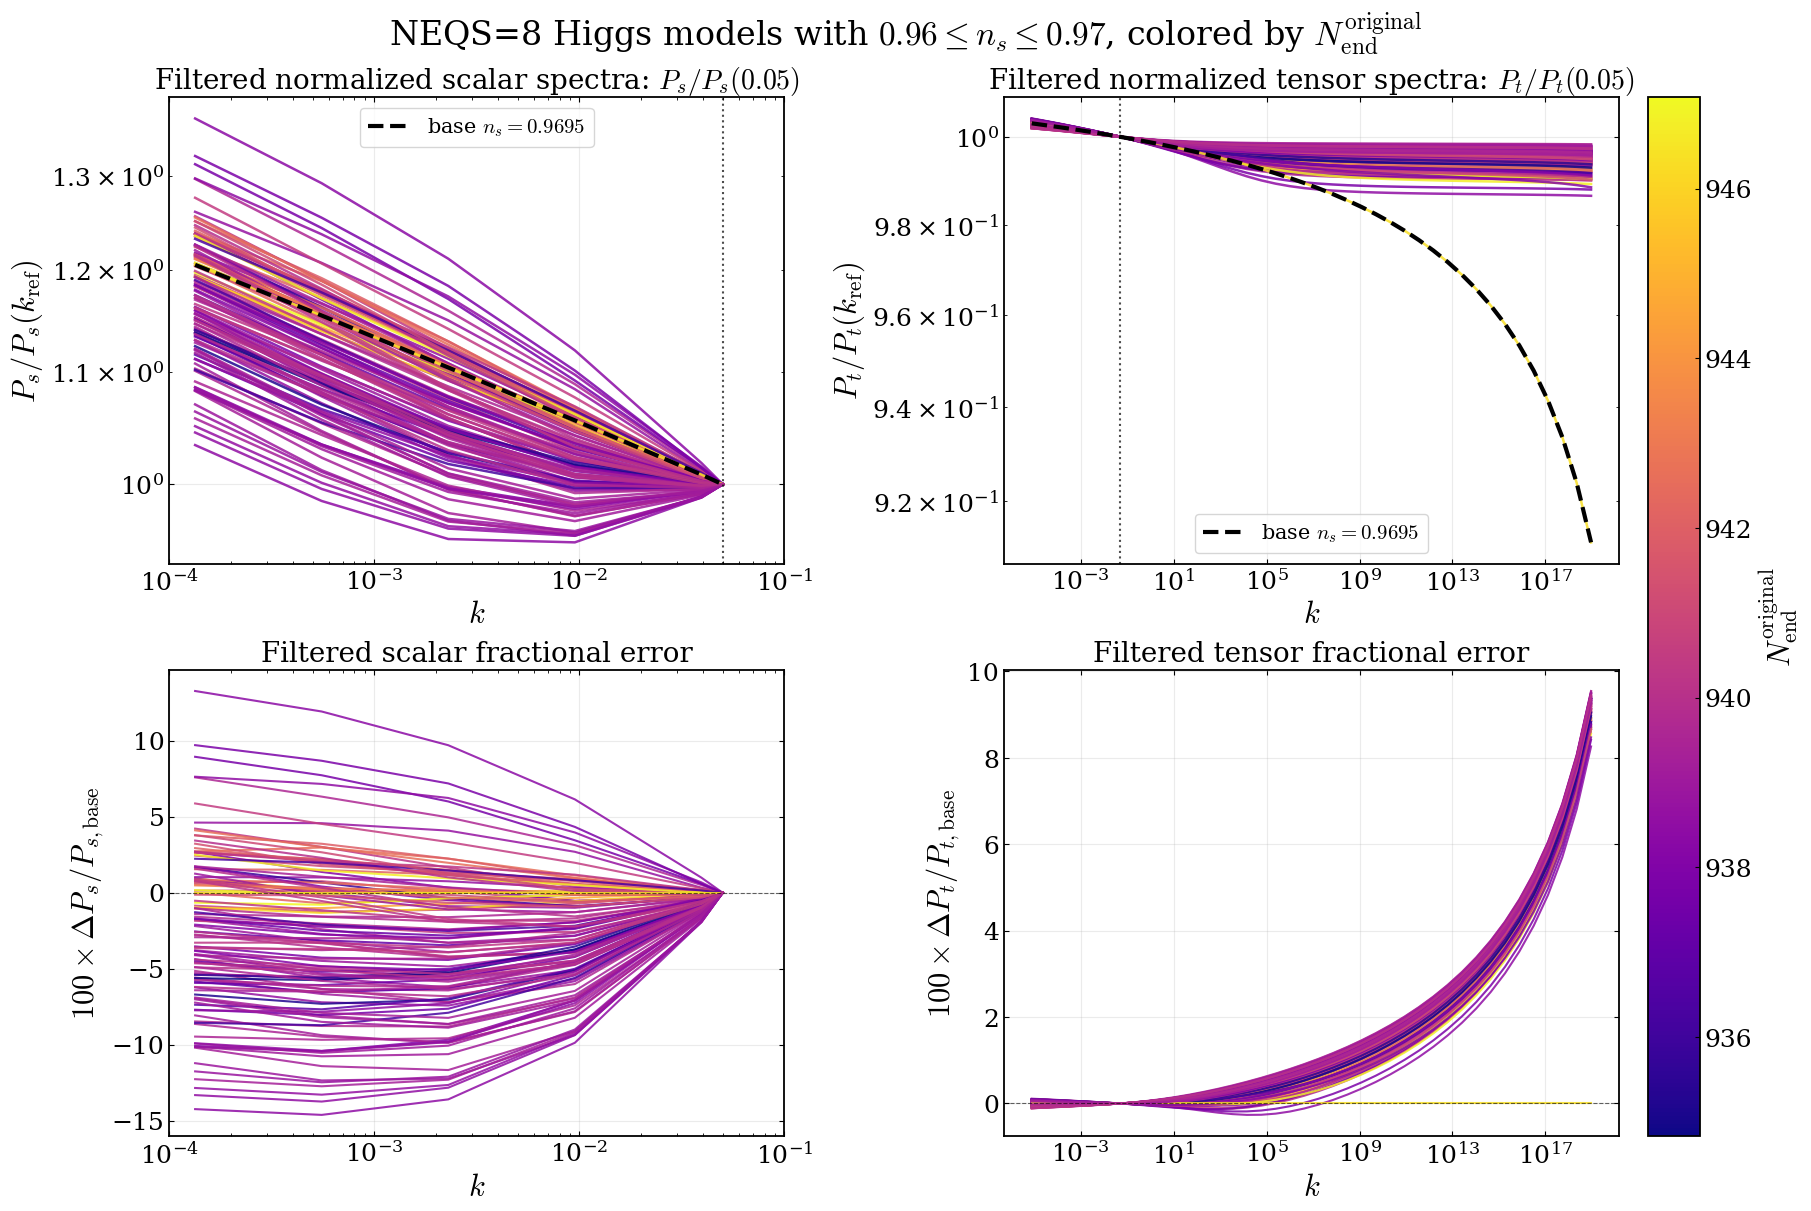


Running N_end-colored spectra: Deformed Quadratic

=== All models summary ===
Total loaded: 120
Base ns: 0.960824
Base original_N_end: 941.156262
Models in ns window [0.96, 0.97]: 120
Models kept after all cuts: 120


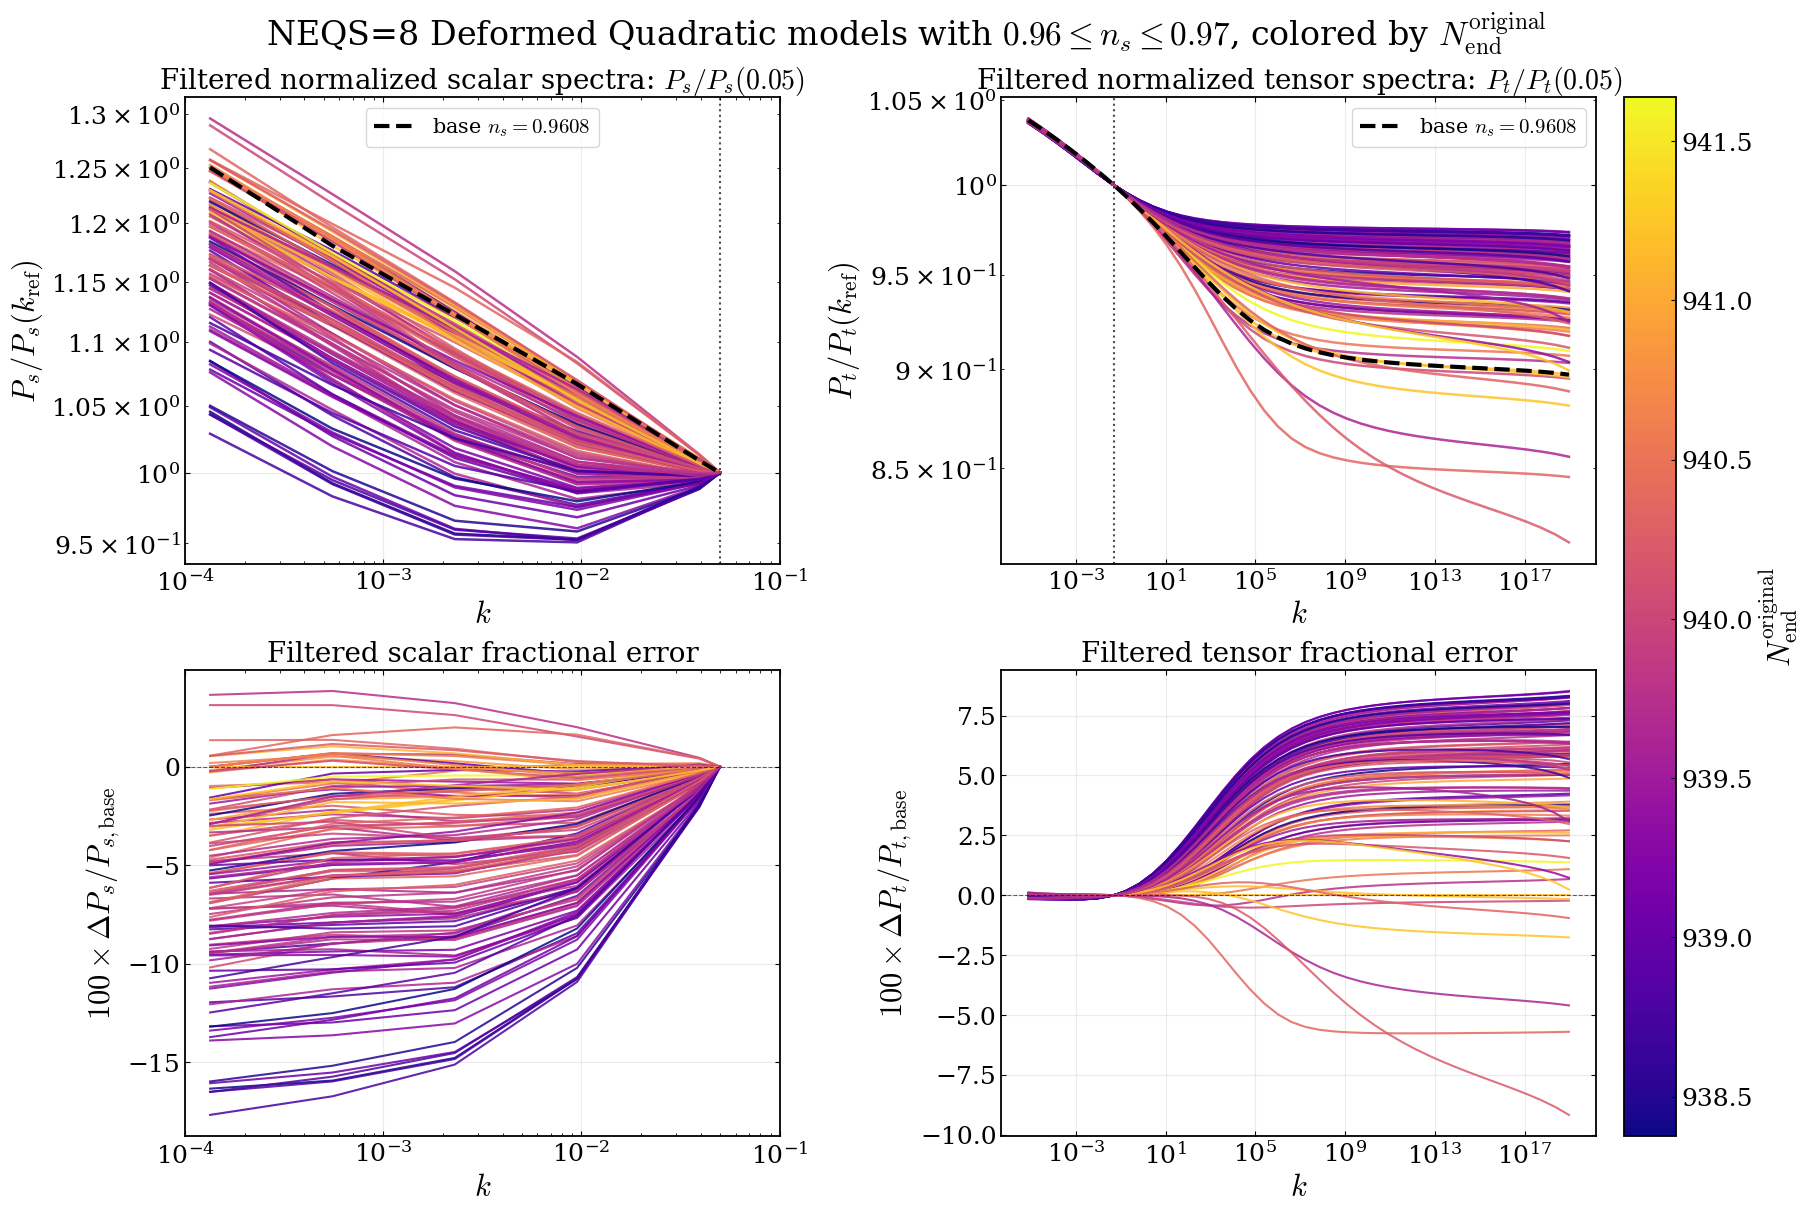

In [194]:
COLORED_SPECTRA_CONFIG = {
    "higgs": {
        "base_value": -8.92461e-9,
        "save_name": (
            "paper_higgs_neqs8_lam5_"
            "filtered_ns_spectra_colored_by_Nend.pdf"
        ),
    },

    "nonhiggs": {
        "base_value": -3.3792701497e-5,
        "save_name": (
            "paper_nonhiggs_neqs8_lam5_"
            "filtered_ns_spectra_colored_by_Nend.pdf"
        ),
    },
}

colored_spectra_results = {}

for model_tag, config in COLORED_SPECTRA_CONFIG.items():

    print("\n" + "=" * 70)
    print(
        f"Running N_end-colored spectra: "
        f"{MODEL_CONFIG[model_tag]['label']}"
    )
    print("=" * 70)

    lam5_values = param_values_by_model[model_tag][8]

    stats_df, kept_df = (
        plot_filtered_spectra_by_ns_colored_by_Nend(
            NEQS=8,
            lamX_values=lam5_values,
            baseX=config["base_value"],
            base_path_root=base_path_root,
            model_tag=model_tag,

            ns_min=0.96,
            ns_max=0.97,
            ns_target=0.967,

            k_ref=0.05,

            k_min_scalar=1e-4,
            k_max_scalar=1e-1,

            save_name=config["save_name"],
        )
    )

    colored_spectra_results[model_tag] = {
        "stats": stats_df,
        "kept": kept_df,
    }

## Examine Scalar and Tensor Power Spectra Relative to Base Model

Define Function:

In [195]:
def plot_valid_ns_before_after_kshift_percentile_envelopes_tensorK_batch(
    base_path_root,
    lam_values_by_neqs,
    ref_NEQS=8,
    ref_param="lam5",
    ref_value=-8.92461e-9,
    model_tag="higgs",
    ns_min=0.963,
    ns_max=0.970,
    r_min=None,
    r_max=None,
    alpha_min=None,
    alpha_max=None,
    max_abs_alpha_s=None,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    k_min_tensor=None,
    k_max_tensor=None,
    max_abs_deltaN=None,
    tolerance=5.0,
    skip_zero=True,
    zero_tol=1e-30,
    show_max=True,
    save_name=None,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 18,
        "axes.titlesize": 17,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 10,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    colors_by_neqs = {
        7: "plum",
        8: "mediumslateblue",
        9: "royalblue",
    }

    summary_cache = {}

    def get_summary(NEQS):
        if NEQS not in summary_cache:
            summary_cache[NEQS] = load_batch_summaries(
                NEQS,
                base_path_root,
                model_tag=model_tag,
            )
        return summary_cache[NEQS]

    def get_summary_row(NEQS, param_name, value):
        summary_df = get_summary(NEQS)

        matches = summary_df.loc[
            np.isclose(summary_df[param_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return matches.iloc[0]

    def load_observables(NEQS, param_name, value):
        row = get_summary_row(NEQS, param_name, value)
        return row["r"], row["n_s"], row["alpha_s"]

    def get_original_N_end(NEQS, param_name, value):
        row = get_summary_row(NEQS, param_name, value)
        return float(row["original_N_end"])

    def load_specs_local(NEQS, param_name, value):
        folder = folder_for(
            NEQS=NEQS,
            param_name=param_name,
            value=value,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside range [{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref

    def frac_on_ref_grid(
        k_ref_grid,
        P_ref_norm,
        k_cmp,
        P_cmp_norm,
        kmin=None,
        kmax=None,
    ):
        k_ref_grid, P_ref_norm = prepare_increasing(k_ref_grid, P_ref_norm)
        k_cmp, P_cmp_norm = prepare_increasing(k_cmp, P_cmp_norm)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmin is not None:
            xmin = max(xmin, kmin)

        if kmax is not None:
            xmax = min(xmax, kmax)

        if xmin >= xmax:
            return np.array([]), np.array([])

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)
        k_use = k_ref_grid[mask]

        if len(k_use) == 0:
            return np.array([]), np.array([])

        P_ref_use = P_ref_norm[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp_norm)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    #This fun is the main difference, instead of mean and max, i do mean and 68% and 95% spread
    
    def collect_percentile_envelope(frac_curves, k_ref_grid):
        if len(frac_curves) == 0:
            return None

        k_env = k_ref_grid.copy()
        frac_stack = []

        #takes k and frac err for k range
        for k_curve, frac_curve in frac_curves:
            if len(k_curve) < 2:
                continue
#interpolates every model's fractional error curve on the same reference grid
#each model might have slightly different k-values
#percentiles make sense only if all models are compared at the same k
            interp = np.interp(
                k_env,
                k_curve,
                frac_curve,
                left=np.nan,
                right=np.nan,
            )

            if np.all(~np.isfinite(interp)):
                continue
#will stack all k so we have a row of mode, columns of k vals, and entries are frac error at that k
            frac_stack.append(interp)

        if len(frac_stack) == 0:
            return None

        frac_stack = np.array(frac_stack)

        valid_cols = np.any(np.isfinite(frac_stack), axis=0)
        frac_stack = frac_stack[:, valid_cols]
        k_env = k_env[valid_cols]

        #i do take absolute values here
        abs_stack = np.abs(frac_stack)

        #so at every k it computes in percent the median (50th percentile), 68th percentiles and 95th and the max
        return {
            "k": k_env,
            "median": 100.0 * np.nanmedian(abs_stack, axis=0),
            "p68": 100.0 * np.nanpercentile(abs_stack, 68, axis=0),
            "p95": 100.0 * np.nanpercentile(abs_stack, 95, axis=0),
            "max": 100.0 * np.nanmax(abs_stack, axis=0),
        }

    # Reference spectra
    ref_N_end = get_original_N_end(ref_NEQS, ref_param, ref_value)

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs_local(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, Ps_ref_norm = normalize_at_k(k_s_ref_raw, Ps_ref_raw, k_norm)
    k_t_ref, Pt_ref_norm = normalize_at_k(k_t_ref_raw, Pt_ref_raw, k_norm)

    curves = {
        NEQS: {
            "Ps_unshift": [],
            "Ps_shift": [],
            "Pt_unshift": [],
            "Pt_shift": [],
            "rows": [],
            "skipped_deltaN": 0,
            "skipped_ns": 0,
            "skipped_r": 0,
            "skipped_alpha": 0,
            "skipped_other": 0,
        }
        for NEQS in lam_values_by_neqs.keys()
    }

    for NEQS, lam_values in lam_values_by_neqs.items():
        param_name, _ = SCAN_INFO[NEQS]

        for item in lam_values:
            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                r, ns, alpha_s = load_observables(NEQS, param_name, value)
                
                summary_row = get_summary_row(
                    NEQS,
                    param_name,
                    value,
                )

                if not (ns_min <= ns <= ns_max):
                    curves[NEQS]["skipped_ns"] += 1
                    continue

                if r_min is not None and r < r_min:
                    curves[NEQS]["skipped_r"] += 1
                    continue

                if r_max is not None and r > r_max:
                    curves[NEQS]["skipped_r"] += 1
                    continue

                if alpha_min is not None and alpha_s < alpha_min:
                    curves[NEQS]["skipped_alpha"] += 1
                    continue

                if alpha_max is not None and alpha_s > alpha_max:
                    curves[NEQS]["skipped_alpha"] += 1
                    continue

                if max_abs_alpha_s is not None and np.abs(alpha_s) > max_abs_alpha_s:
                    curves[NEQS]["skipped_alpha"] += 1
                    continue

                model_N_end = get_original_N_end(NEQS, param_name, value)
                deltaN = model_N_end - ref_N_end
                abs_deltaN = np.abs(deltaN)

                if max_abs_deltaN is not None and abs_deltaN > max_abs_deltaN:
                    curves[NEQS]["skipped_deltaN"] += 1
                    continue

                k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_local(
                    NEQS,
                    param_name,
                    value,
                )

                # Unshifted
                k_s_un, Ps_un = normalize_at_k(k_s_raw, Ps_raw, k_norm)
                k_t_un, Pt_un = normalize_at_k(k_t_raw, Pt_raw, k_norm)

                k_ps_un, frac_ps_un = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_un,
                    Ps_un,
                    kmin=k_min_scalar,
                    kmax=k_max_scalar,
                )

                k_pt_un, frac_pt_un = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_un,
                    Pt_un,
                    kmin=k_min_tensor,
                    kmax=k_max_tensor,
                )

                # Shifted
                k_s_shifted = k_s_raw * np.exp(-deltaN)
                k_t_shifted = k_t_raw * np.exp(-deltaN)

                k_s_sh, Ps_sh = normalize_at_k(k_s_shifted, Ps_raw, k_norm)
                k_t_sh, Pt_sh = normalize_at_k(k_t_shifted, Pt_raw, k_norm)

                k_ps_sh, frac_ps_sh = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_sh,
                    Ps_sh,
                    kmin=k_min_scalar,
                    kmax=k_max_scalar,
                )

                k_pt_sh, frac_pt_sh = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_sh,
                    Pt_sh,
                    kmin=k_min_tensor,
                    kmax=k_max_tensor,
                )

                if (
                    len(frac_ps_un) == 0
                    or len(frac_ps_sh) == 0
                    or len(frac_pt_un) == 0
                    or len(frac_pt_sh) == 0
                ):
                    curves[NEQS]["skipped_other"] += 1
                    continue
                    
                # --------------------------------------------------
                # Per-model spectral distances
                # Median absolute percent difference over the selected k-range
                # --------------------------------------------------

                D_s_unshift = 100.0 * np.nanmedian(
                    np.abs(frac_ps_un)
                )

                D_s_shift = 100.0 * np.nanmedian(
                    np.abs(frac_ps_sh)
                )

                D_t_unshift = 100.0 * np.nanmedian(
                    np.abs(frac_pt_un)
                )

                D_t_shift = 100.0 * np.nanmedian(
                    np.abs(frac_pt_sh)
                )

                curves[NEQS]["Ps_unshift"].append((k_ps_un, frac_ps_un))
                curves[NEQS]["Ps_shift"].append((k_ps_sh, frac_ps_sh))
                curves[NEQS]["Pt_unshift"].append((k_pt_un, frac_pt_un))
                curves[NEQS]["Pt_shift"].append((k_pt_sh, frac_pt_sh))

#                 curves[NEQS]["rows"].append({
#                     "NEQS": NEQS,
#                     "param_name": param_name,
#                     "value": value,
#                     "r": r,
#                     "ns": ns,
#                     "alpha_s": alpha_s,
#                     "original_N_end": model_N_end,
#                     "deltaN_from_ref_base": deltaN,
#                     "abs_deltaN_from_ref_base": abs_deltaN,
#                 })


#                 curves[NEQS]["rows"].append({
#                     "NEQS": NEQS,
#                     "param_name": param_name,
#                     "value": value,

#                     "r": r,
#                     "ns": ns,
#                     "alpha_s": alpha_s,

#                     "original_N_end": model_N_end,
#                     "deltaN_from_ref_base": deltaN,
#                     "abs_deltaN_from_ref_base": abs_deltaN,

#                     "D_s_unshift": D_s_unshift,
#                     "D_s_shift": D_s_shift,

#                     "D_t_unshift": D_t_unshift,
#                     "D_t_shift": D_t_shift,
#                 })

                curves[NEQS]["rows"].append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,

                    # Higher-order hierarchy values for this exact model
                    "lam2": float(summary_row["lam2"]),
                    "lam3": float(summary_row["lam3"]),
                    "lam4": float(summary_row["lam4"]),
                    "lam5": float(summary_row["lam5"]),

                    "r": float(r),
                    "ns": float(ns),
                    "alpha_s": float(alpha_s),

                    "original_N_end": model_N_end,
                    "deltaN_from_ref_base": deltaN,
                    "abs_deltaN_from_ref_base": abs_deltaN,

                    "D_s_unshift": D_s_unshift,
                    "D_s_shift": D_s_shift,

                    "D_t_unshift": D_t_unshift,
                    "D_t_shift": D_t_shift,
                })

            except FileNotFoundError:
                print(f"Missing files for NEQS={NEQS}, {param_name}={value:.5e}")
                curves[NEQS]["skipped_other"] += 1

            except ValueError as e:
                print(f"Skipping NEQS={NEQS}, {param_name}={value:.5e}: {e}")
                curves[NEQS]["skipped_other"] += 1

    # Plot
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10.5),
        constrained_layout=True,
    )

    ax_ps_un, ax_ps_sh = axes[0]
    ax_pt_un, ax_pt_sh = axes[1]

    plot_specs = [
        ("Ps_unshift", ax_ps_un, k_s_ref, k_min_scalar, k_max_scalar, r"$P_s$", "Before $k$-shift"),
        ("Ps_shift", ax_ps_sh, k_s_ref, k_min_scalar, k_max_scalar, r"$P_s$", r"After $k \to k e^{-\Delta N}$"),
        ("Pt_unshift", ax_pt_un, k_t_ref, k_min_tensor, k_max_tensor, r"$P_t$", "Before $k$-shift"),
        ("Pt_shift", ax_pt_sh, k_t_ref, k_min_tensor, k_max_tensor, r"$P_t$", r"After $k \to k e^{-\Delta N}$"),
    ]

    envelope_rows = []

    for key, ax, k_ref_grid, kmin, kmax, quantity_label, title_suffix in plot_specs:
        for NEQS in lam_values_by_neqs.keys():
            color = colors_by_neqs.get(NEQS, None)

            env = collect_percentile_envelope(
                curves[NEQS][key],
                k_ref_grid,
            )

            if env is None:
                continue

            k_env = env["k"]
            median = env["median"]
            p68 = env["p68"]
            p95 = env["p95"]
            max_env = env["max"]

            mask = np.ones_like(k_env, dtype=bool)

            if kmin is not None:
                mask &= k_env >= kmin

            if kmax is not None:
                mask &= k_env <= kmax

            k_env = k_env[mask]
            median = median[mask]
            p68 = p68[mask]
            p95 = p95[mask]
            max_env = max_env[mask]

            if len(k_env) == 0:
                continue

            ax.fill_between(
                k_env,
                0.0,
                p95,
                color=color,
                alpha=0.16,
                label=rf"NEQS={NEQS} 95% spread",
            )

            ax.fill_between(
                k_env,
                0.0,
                p68,
                color=color,
                alpha=0.30,
                label=rf"NEQS={NEQS} 68% spread",
            )

            ax.plot(
                k_env,
                median,
                color=color,
                lw=2.5,
                label=rf"NEQS={NEQS} median",
            )

            if show_max:
                ax.plot(
                    k_env,
                    max_env,
                    color=color,
                    lw=1.25,
                    ls=":",
                    alpha=0.9,
                    label=rf"NEQS={NEQS} max",
                )

            envelope_rows.append({
                "NEQS": NEQS,
                "case": key,
                "n_models": len(curves[NEQS][key]),
                "median_abs_pct": np.nanmedian(median),
                "max_p68_abs_pct": np.nanmax(p68),
                "max_p95_abs_pct": np.nanmax(p95),
                "max_envelope_pct": np.nanmax(max_env),
                "k_min_scalar": k_min_scalar if "Ps" in key else np.nan,
                "k_max_scalar": k_max_scalar if "Ps" in key else np.nan,
                "k_min_tensor": k_min_tensor if "Pt" in key else np.nan,
                "k_max_tensor": k_max_tensor if "Pt" in key else np.nan,
                "max_abs_deltaN_cut": max_abs_deltaN,
                "max_abs_alpha_s_cut": max_abs_alpha_s,
                "r_min": r_min,
                "r_max": r_max,
            })

        ax.axhline(
            tolerance,
            color="black",
            lw=1.7,
            ls="--",
            label=rf"{tolerance:.0f}% tolerance",
        )

        if "Pt" in key:
            k_N60 = 0.05
            k_N20 = 1e15

            ax.axvline(k_N60, color="darkgreen", ls="--", lw=1.8, alpha=0.9)
            ax.axvline(k_N20, color="firebrick", ls="--", lw=1.8, alpha=0.9)

            ax.text(
                k_N60,
                0.82,
                r"$N\sim60$",
                transform=ax.get_xaxis_transform(),
                rotation=90,
                color="darkgreen",
                ha="right",
                va="top",
                fontsize=10,
            )

            ax.text(
                k_N20,
                0.82,
                r"$N\sim20$",
                transform=ax.get_xaxis_transform(),
                rotation=90,
                color="firebrick",
                ha="right",
                va="top",
                fontsize=10,
            )

        ax.set_xscale("log")
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        ax.set_title(rf"{quantity_label} percentile envelope: {title_suffix}")
        ax.set_xlabel(r"$k$")
        ax.set_ylabel(rf"$|\Delta {quantity_label}/{quantity_label}|$ [\%]")

        if kmin is not None or kmax is not None:
            xmin = kmin if kmin is not None else k_ref_grid.min()
            xmax = kmax if kmax is not None else k_ref_grid.max()
            ax.set_xlim(xmin, xmax)

        ax.legend(fontsize=8, frameon=False, loc="best")

    cut_text = ""

    if max_abs_deltaN is not None:
        cut_text += rf", $|\Delta N| \leq {max_abs_deltaN}$"

    if max_abs_alpha_s is not None:
        cut_text += rf", $|\alpha_s| \leq {max_abs_alpha_s}$"

    if r_min is not None or r_max is not None:
        rmin_text = r_min if r_min is not None else 0.0
        rmax_text = r_max if r_max is not None else np.inf
        cut_text += rf", $r\in[{rmin_text:.2g},{rmax_text:.2g}]$"

    fig.suptitle(
        rf"Percentile spectral-error envelopes relative to NEQS={ref_NEQS} base "
        rf"(${ns_min}<n_s<{ns_max}$){cut_text}",
        fontsize=20,
    )

    if save_name is None:
        save_name = (
            f"valid_ns_r_tensorK_percentile_envelopes_"
            f"ref_neqs{ref_NEQS}.pdf"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    model_rows = []
    for NEQS in lam_values_by_neqs.keys():
        model_rows.extend(curves[NEQS]["rows"])

    model_df = pd.DataFrame(model_rows)
    
    #Added
    # Default distances used in later hierarchy plots:
    # use the spectra after correcting for deltaN.
    if not model_df.empty:
        model_df["D_s"] = model_df["D_s_shift"]
        model_df["D_t"] = model_df["D_t_shift"]

    
    envelope_df = pd.DataFrame(envelope_rows)

    print("\n=== Cut summary ===")
    for NEQS in lam_values_by_neqs.keys():
        print(
            f"NEQS={NEQS}: kept={len(curves[NEQS]['rows'])}, "
            f"skipped_ns={curves[NEQS]['skipped_ns']}, "
            f"skipped_r={curves[NEQS]['skipped_r']}, "
            f"skipped_alpha={curves[NEQS]['skipped_alpha']}, "
            f"skipped_deltaN={curves[NEQS]['skipped_deltaN']}, "
            f"skipped_other={curves[NEQS]['skipped_other']}"
        )

    print("\n=== Percentile envelope summary ===")
    if not envelope_df.empty:
        print(envelope_df.to_string(index=False))

    return model_df, envelope_df

Function Usage:


Running spectral-envelope analysis: higgs
Skipping NEQS=8, lam5=-4.07624e-05: k_ref=0.05 outside range [8.260e-02, 9.794e+22]
Skipping NEQS=8, lam5=-3.66361e-05: k_ref=0.05 outside range [5.602e-02, 6.642e+22]
Skipping NEQS=8, lam5=-3.56985e-05: k_ref=0.05 outside range [2.975e-01, 3.528e+23]
Skipping NEQS=8, lam5=-2.79589e-05: k_ref=0.05 outside range [5.594e-01, 6.633e+23]
Skipping NEQS=8, lam5=-2.75059e-05: k_ref=0.05 outside range [1.020e-01, 1.209e+23]
Skipping NEQS=8, lam5=-2.57986e-05: k_ref=0.05 outside range [8.281e-02, 9.819e+22]
Skipping NEQS=8, lam5=-2.34737e-05: k_ref=0.05 outside range [6.512e-02, 7.722e+22]
Skipping NEQS=8, lam5=-2.28287e-05: k_ref=0.05 outside range [5.024e-02, 5.957e+22]
Skipping NEQS=8, lam5=-1.62767e-05: k_ref=0.05 outside range [8.194e-02, 9.717e+22]
Skipping NEQS=8, lam5=-1.39168e-05: k_ref=0.05 outside range [2.020e-01, 2.395e+23]
Skipping NEQS=8, lam5=-9.19430e-06: k_ref=0.05 outside range [1.765e-01, 2.093e+23]
Skipping NEQS=8, lam5=-8.78257e-0

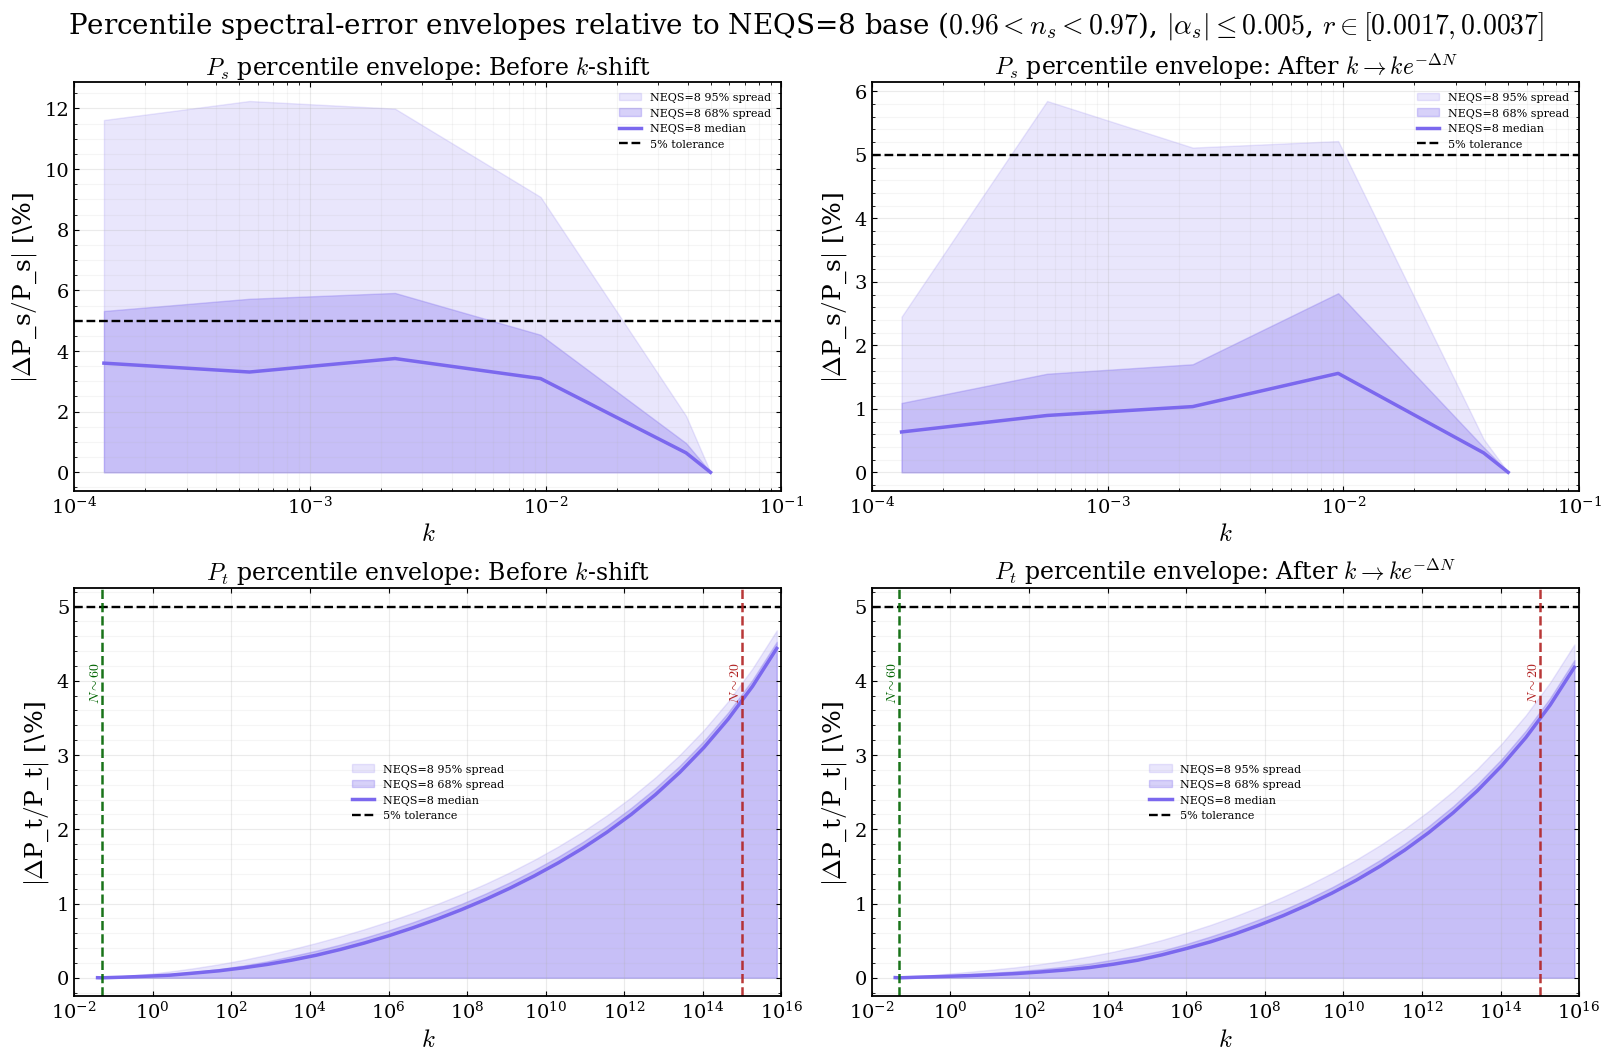


=== Cut summary ===
NEQS=8: kept=106, skipped_ns=0, skipped_r=0, skipped_alpha=0, skipped_deltaN=0, skipped_other=14

=== Percentile envelope summary ===
 NEQS       case  n_models  median_abs_pct  max_p68_abs_pct  max_p95_abs_pct  max_envelope_pct  k_min_scalar  k_max_scalar  k_min_tensor  k_max_tensor max_abs_deltaN_cut  max_abs_alpha_s_cut    r_min    r_max
    8 Ps_unshift       106        3.198837         5.913633        12.242468         14.613741        0.0001           0.1           NaN           NaN               None                0.005 0.001737 0.003737
    8   Ps_shift       106        0.765310         2.820735         5.847337          6.671476        0.0001           0.1           NaN           NaN               None                0.005 0.001737 0.003737
    8 Pt_unshift       106        0.731934         4.524695         4.678344          4.725672           NaN           NaN          0.01  1.000000e+16               None                0.005 0.001737 0.003737
    8   P

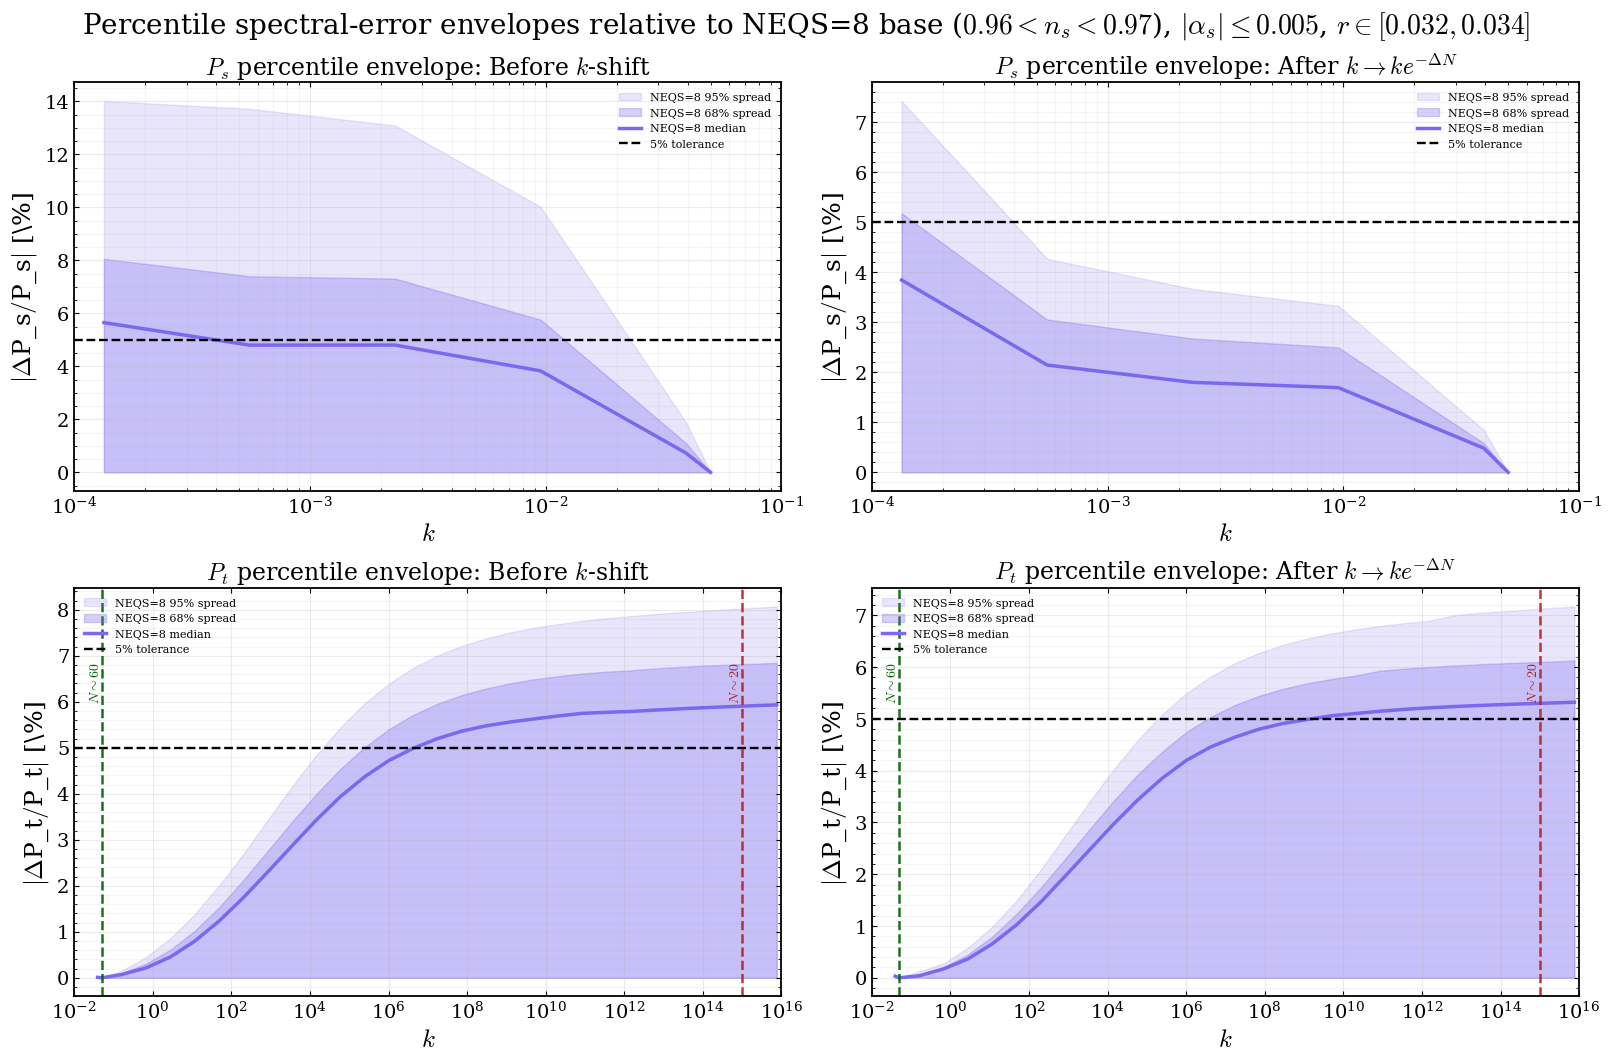


=== Cut summary ===
NEQS=8: kept=120, skipped_ns=0, skipped_r=0, skipped_alpha=0, skipped_deltaN=0, skipped_other=0

=== Percentile envelope summary ===
 NEQS       case  n_models  median_abs_pct  max_p68_abs_pct  max_p95_abs_pct  max_envelope_pct  k_min_scalar  k_max_scalar  k_min_tensor  k_max_tensor max_abs_deltaN_cut  max_abs_alpha_s_cut    r_min    r_max
    8 Ps_unshift       120        4.315165         8.056303        14.015222         17.689439        0.0001           0.1           NaN           NaN               None                0.005 0.031959 0.033959
    8   Ps_shift       120        1.746242         5.180760         7.425051          8.661936        0.0001           0.1           NaN           NaN               None                0.005 0.031959 0.033959
    8 Pt_unshift       120        5.090271         6.844808         8.069650          8.324485           NaN           NaN          0.01  1.000000e+16               None                0.005 0.031959 0.033959
    8   Pt

In [196]:
SPECTRUM_PLOT_CONFIG = {
    "higgs": {
        "ref_value": -8.92461e-9,
        "r_target": 2.737e-3,
        "r_delta": 0.001,
        "save_name": (
            "valid_ns_r_alpha_tensorK_"
            "percentile_envelopes_higgs.pdf"
        ),
    },

    "nonhiggs": {
        "ref_value": -3.3792701497e-5,
        "r_target": 3.2958886892e-2,
        "r_delta": 0.001,
        "save_name": (
            "valid_ns_r_alpha_tensorK_"
            "percentile_envelopes_nonhiggs.pdf"
        ),
    },
}

spectral_results = {}

for model_tag, config in SPECTRUM_PLOT_CONFIG.items():

    print("\n" + "=" * 70)
    print(f"Running spectral-envelope analysis: {model_tag}")
    print("=" * 70)

    lam5_values = param_values_by_model[model_tag][8]

    model_df_pct, envelope_df_pct = (
        plot_valid_ns_before_after_kshift_percentile_envelopes_tensorK_batch(
            base_path_root=base_path_root,
            lam_values_by_neqs={
                8: lam5_values,
            },

            ref_NEQS=8,
            ref_param="lam5",
            ref_value=config["ref_value"],
            model_tag=model_tag,

            ns_min=0.96,
            ns_max=0.97,

            r_min=(
                config["r_target"]
                - config["r_delta"]
            ),

            r_max=(
                config["r_target"]
                + config["r_delta"]
            ),

            max_abs_alpha_s=0.005,

            k_norm=0.05,

            k_min_scalar=1e-4,
            k_max_scalar=1e-1,

            k_min_tensor=1e-2,
            k_max_tensor=1e16,

            max_abs_deltaN=None,
            tolerance=5.0,
            skip_zero=True,
            show_max=False,

            save_name=config["save_name"],
        )
    )

    spectral_results[model_tag] = {
        "models": model_df_pct,
        "envelopes": envelope_df_pct,
    }

## Background Variables

In [197]:
def plot_filtered_background_by_ns(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    model_tag="higgs",
    ns_min=0.96,
    ns_max=0.971,
    ns_target=0.961,
    N_ref=60.0,
    N_window=None,
    cmap_name="plasma",
    frac_ylim=None,
    eps_frac_ylim=None,
    save_name=None,
    show=True,
):
    
    
    
    scan_name, scan_symbol = SCAN_INFO[NEQS]
    
    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label",model_tag)

    def sanitize_lam_values(vals):
        return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

    summary_all = load_batch_summaries(
    NEQS=NEQS,
    base_path_root=base_path_root,
    model_tag=model_tag,
)


    def get_summary_row(value):
        matches = summary_all.loc[
            np.isclose(
                summary_all[scan_name].to_numpy(dtype=float),
                value,
                rtol=1e-8,
                atol=max(1e-15, abs(value) * 1e-8),
            )
        ]

        if matches.empty:
            raise FileNotFoundError(
                f"No summary row found for "
                f"{scan_name}={value:.10e}, "
                f"model={model_tag}"
            )

        return matches.iloc[0]


    def load_observables(value):
        row = get_summary_row(value)

        return (
            float(row["r"]),
            float(row["n_s"]),
            float(row["alpha_s"]),
        )


    def load_path(value):
        val_str = f"{value:.10e}"

        folder = folder_for(
            NEQS=NEQS,
            param_name=scan_name,
            value=value,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )

        file_path = os.path.join(
            str(folder),
            f"path_neqs{NEQS}_{scan_name}_{val_str}.dat",
        )

        if not os.path.exists(file_path):
            raise FileNotFoundError(
                f"Missing path file: {file_path}"
            )

        return pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
        ).values


    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        order = np.argsort(x)
        return x[order], y[order]

    def normalize_at_ref(N, Y, N_ref):
        N_use, Y_use = prepare_increasing(N, Y)

        if not (np.min(N_use) <= N_ref <= np.max(N_use)):
            raise ValueError(
                f"N_ref={N_ref} outside range [{np.min(N_use)}, {np.max(N_use)}]"
            )

        Y_ref = np.interp(N_ref, N_use, Y_use)

        if np.abs(Y_ref) < 1e-30:
            raise ValueError(f"Reference value too small at N_ref={N_ref}")

        return N_use, Y_use / Y_ref, Y_ref

    def apply_N_window(N, Y):
        if N_window is None:
            return N, Y

        Nmin, Nmax = N_window
        mask = (N >= Nmin) & (N <= Nmax)
        return N[mask], Y[mask]

    def fractional_error_on_base_grid(N_base, Y_base, N_model, Y_model):
        N_base, Y_base = prepare_increasing(N_base, Y_base)
        N_model, Y_model = prepare_increasing(N_model, Y_model)

        Nmin = max(np.min(N_base), np.min(N_model))
        Nmax = min(np.max(N_base), np.max(N_model))

        if N_window is not None:
            Nmin = max(Nmin, N_window[0])
            Nmax = min(Nmax, N_window[1])

        mask = (N_base >= Nmin) & (N_base <= Nmax)

        N_use = N_base[mask]
        Y_base_use = Y_base[mask]

        if len(N_use) == 0:
            raise ValueError("No overlapping N range between model and base.")

        Y_model_interp = np.interp(N_use, N_model, Y_model)
        frac = (Y_model_interp - Y_base_use) / Y_base_use

        return N_use, frac

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 14,
        "figure.titlesize": 22,

        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)
    base_data = load_path(baseX)

    H_base = base_data[:, 1]
    eps_base = base_data[:, 2]
    N_base = base_data[:, NEQS]
    V_base = base_data[:, NEQS + 1]

    N_base_H, H_base_norm, H_ref = normalize_at_ref(N_base, H_base, N_ref)
    N_base_eps, eps_base_norm, eps_ref = normalize_at_ref(N_base, eps_base, N_ref)
    N_base_V, V_base_norm, V_ref = normalize_at_ref(N_base, V_base, N_ref)

    N_base_H_plot, H_base_plot = apply_N_window(N_base_H, H_base_norm)
    N_base_eps_plot, eps_base_plot = apply_N_window(N_base_eps, eps_base_norm)
    N_base_V_plot, V_base_plot = apply_N_window(N_base_V, V_base_norm)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)
            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "kept_by_ns_cut": keep,
            }
            rows.append(row)

            if not keep:
                continue

            data = load_path(lamX)

            H = data[:, 1]
            eps = data[:, 2]
            N = data[:, NEQS]
            V = data[:, NEQS + 1]

            N_H, H_norm, _ = normalize_at_ref(N, H, N_ref)
            N_eps, eps_norm, _ = normalize_at_ref(N, eps, N_ref)
            N_V, V_norm, _ = normalize_at_ref(N, V, N_ref)

            N_H_plot, H_plot = apply_N_window(N_H, H_norm)
            N_eps_plot, eps_plot = apply_N_window(N_eps, eps_norm)
            N_V_plot, V_plot = apply_N_window(N_V, V_norm)

            N_frac_H, frac_H = fractional_error_on_base_grid(
                N_base_H, H_base_norm, N_H, H_norm
            )

            N_frac_eps, frac_eps = fractional_error_on_base_grid(
                N_base_eps, eps_base_norm, N_eps, eps_norm
            )

            N_frac_V, frac_V = fractional_error_on_base_grid(
                N_base_V, V_base_norm, N_V, V_norm
            )

            kept_models.append({
                **row,

                "N_H": N_H_plot,
                "H_N": H_plot,
                "N_eps": N_eps_plot,
                "eps_N": eps_plot,
                "N_V": N_V_plot,
                "V_N": V_plot,

                "N_frac_H": N_frac_H,
                "frac_H": frac_H,
                "N_frac_eps": N_frac_eps,
                "frac_eps": frac_eps,
                "N_frac_V": N_frac_V,
                "frac_V": frac_V,

                "mean_dH_pct": 100.0 * np.nanmean(frac_H),
                "max_dH_pct": 100.0 * np.nanmax(np.abs(frac_H)),
                "mean_deps_pct": 100.0 * np.nanmean(frac_eps),
                "max_deps_pct": 100.0 * np.nanmax(np.abs(frac_eps)),
                "mean_dV_pct": 100.0 * np.nanmean(frac_V),
                "max_dV_pct": 100.0 * np.nanmax(np.abs(frac_V)),
            })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")

    if len(kept_models) > 0:
        kept_df = pd.DataFrame(kept_models).drop(
            columns=[
                "N_H", "H_N",
                "N_eps", "eps_N",
                "N_V", "V_N",
                "N_frac_H", "frac_H",
                "N_frac_eps", "frac_eps",
                "N_frac_V", "frac_V",
            ]
        )
    else:
        kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()



    fig, axes = plt.subplots(
        3,
        2,
        figsize=(18, 16),
        constrained_layout=True,
    )

    ax_HN, ax_VN = axes[0]
    ax_Herr, ax_Verr = axes[1]
    ax_epsN, ax_epserr = axes[2]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            ax_HN.plot(m["N_H"], m["H_N"], color=color, lw=1.8, alpha=0.85)
            ax_VN.plot(m["N_V"], m["V_N"], color=color, lw=1.8, alpha=0.85)
            ax_epsN.plot(m["N_eps"], m["eps_N"], color=color, lw=1.8, alpha=0.85)

            ax_Herr.plot(
                m["N_frac_H"],
                100.0 * m["frac_H"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

            ax_Verr.plot(
                m["N_frac_V"],
                100.0 * m["frac_V"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

            ax_epserr.plot(
                m["N_frac_eps"],
                100.0 * m["frac_eps"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    ax_HN.plot(
        N_base_H_plot,
        H_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_VN.plot(
        N_base_V_plot,
        V_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_epsN.plot(
        N_base_eps_plot,
        eps_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_Herr, ax_Verr, ax_epserr]:
        ax.axhline(0.0, color="black", ls="--", lw=1.0, alpha=0.7)

    ax_HN.set_title(rf"Filtered normalized Hubble evolution: $H/H(N={N_ref})$")
    ax_VN.set_title(rf"Filtered normalized potential evolution: $V/V(N={N_ref})$")
    ax_epsN.set_title(rf"Filtered normalized slow-roll evolution: $\epsilon/\epsilon(N={N_ref})$")

    ax_Herr.set_title(r"Fractional difference in normalized Hubble evolution")
    ax_Verr.set_title(r"Fractional difference in normalized potential evolution")
    ax_epserr.set_title(r"Fractional difference in normalized $\epsilon(N)$")

    for ax in axes.ravel():
        ax.set_xlabel(r"$N$")
        ax.invert_xaxis()
        ax.grid(True, alpha=0.25)

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=12)

    ax_HN.set_ylabel(rf"$H/H(N={N_ref})$")
    ax_VN.set_ylabel(rf"$V/V(N={N_ref})$")
    ax_epsN.set_ylabel(rf"$\epsilon/\epsilon(N={N_ref})$")

    ax_Herr.set_ylabel(r"$100\times\Delta H/H_{\rm base}$")
    ax_Verr.set_ylabel(r"$100\times\Delta V/V_{\rm base}$")
    ax_epserr.set_ylabel(r"$100\times\Delta\epsilon/\epsilon_{\rm base}$")

    if frac_ylim is not None:
        ax_Herr.set_ylim(frac_ylim)
        ax_Verr.set_ylim(frac_ylim)

    if eps_frac_ylim is not None:
        ax_epserr.set_ylim(eps_frac_ylim)

    
    fig.suptitle(
        rf"NEQS={NEQS} {model_label} models with "
        rf"${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$)",
        fontsize=22,
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_filtered_ns_background_errors_with_epsilon.pdf"

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )
    
    
    if show:
        plt.show()
    else:
        plt.close(fig)

    return kept_df


Running background analysis: Higgs


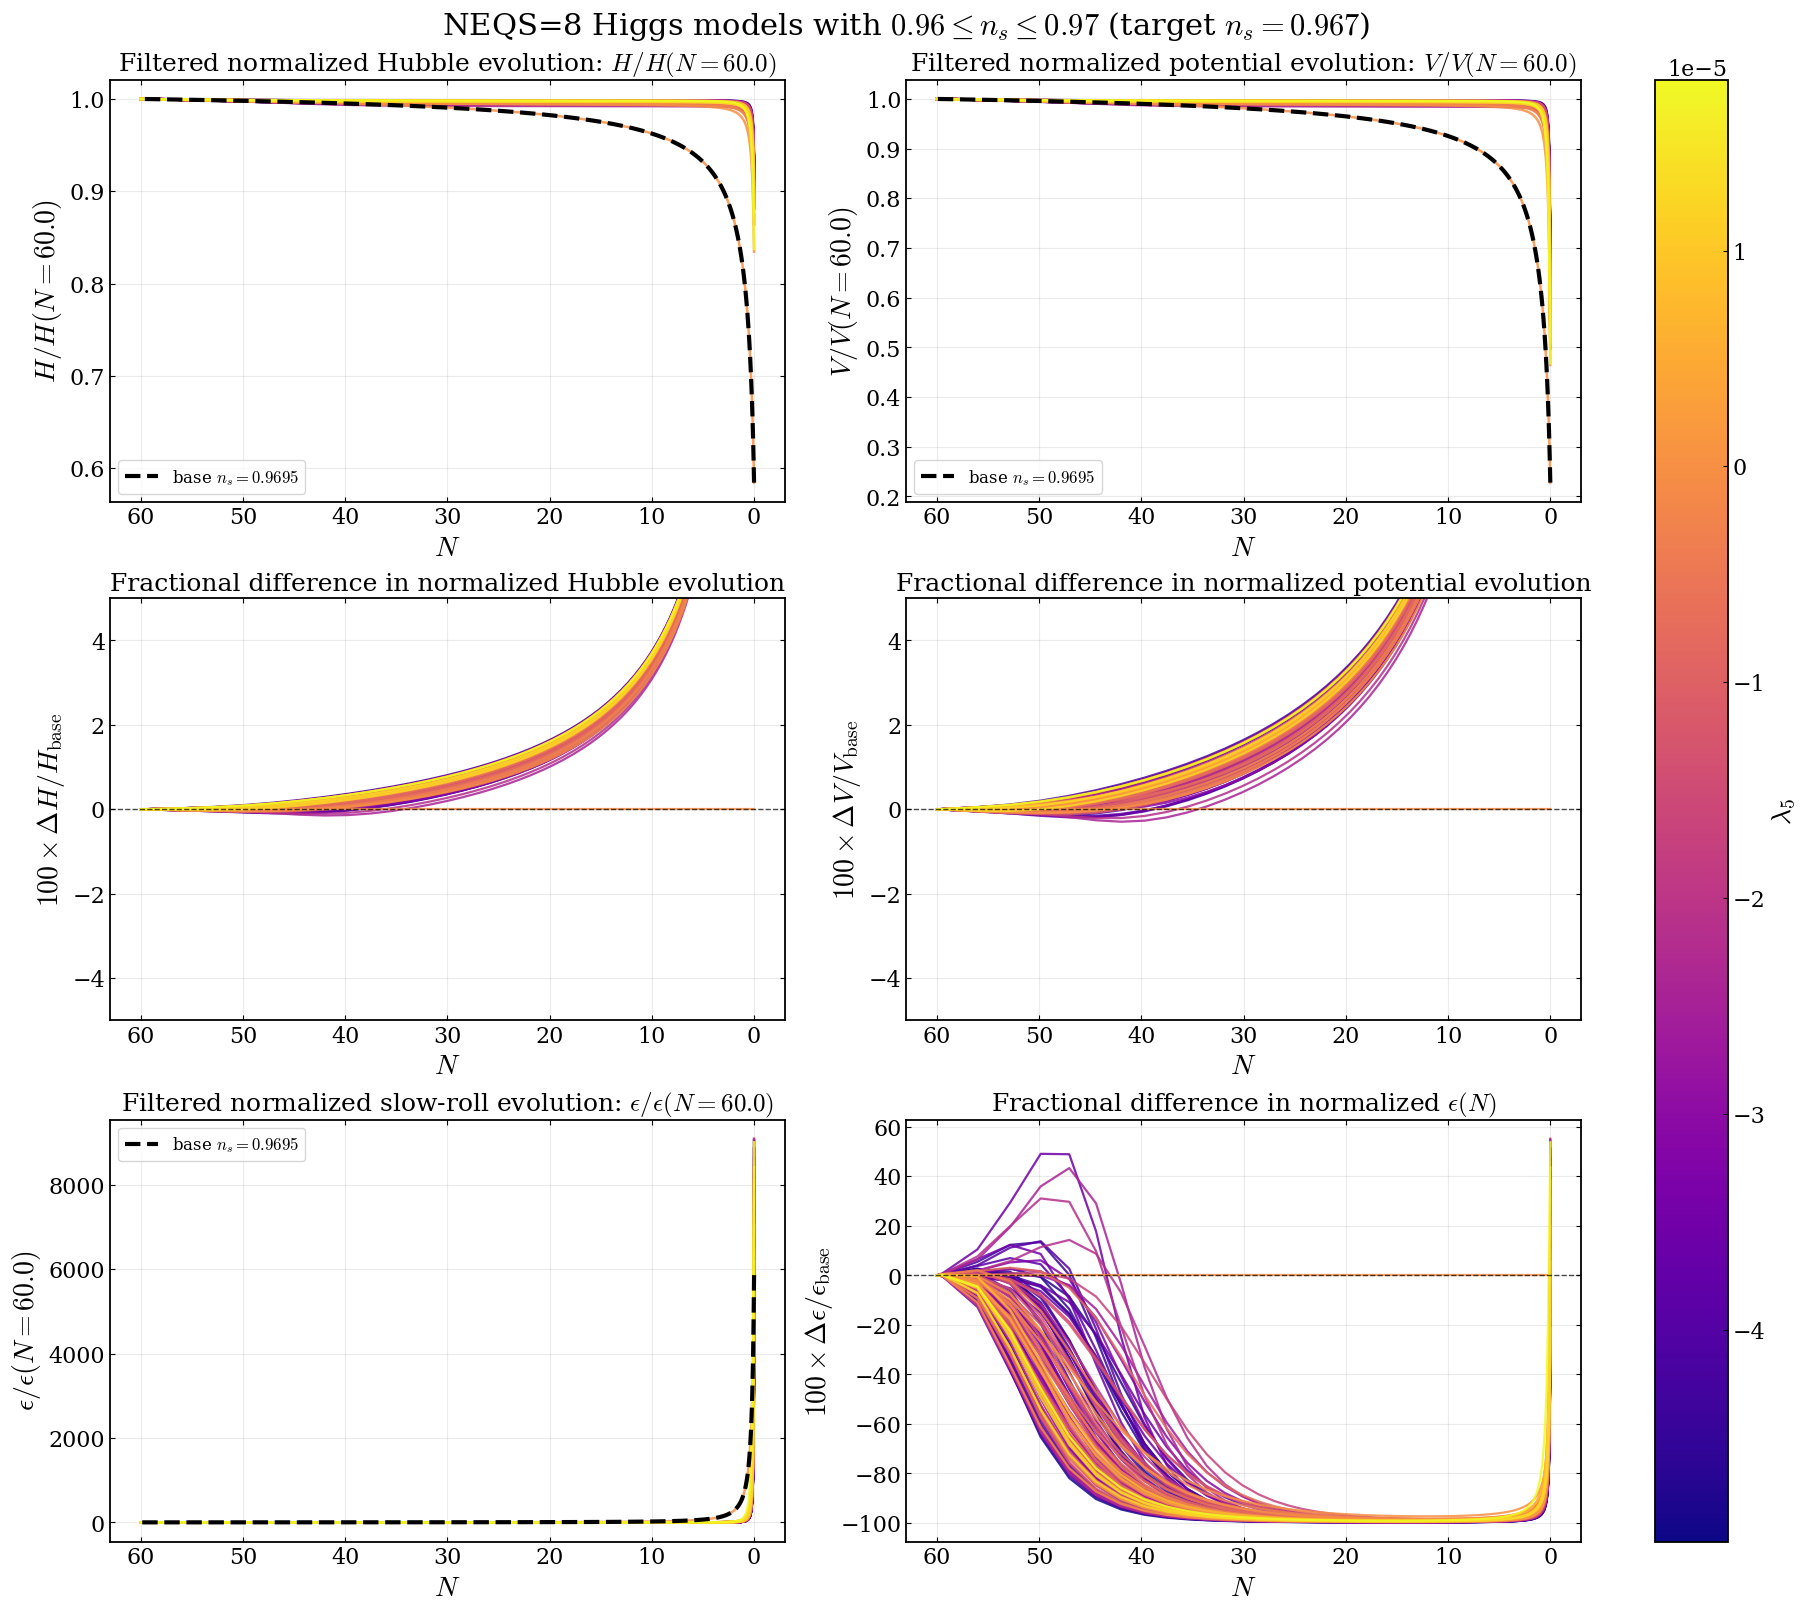


Running background analysis: Deformed Quadratic


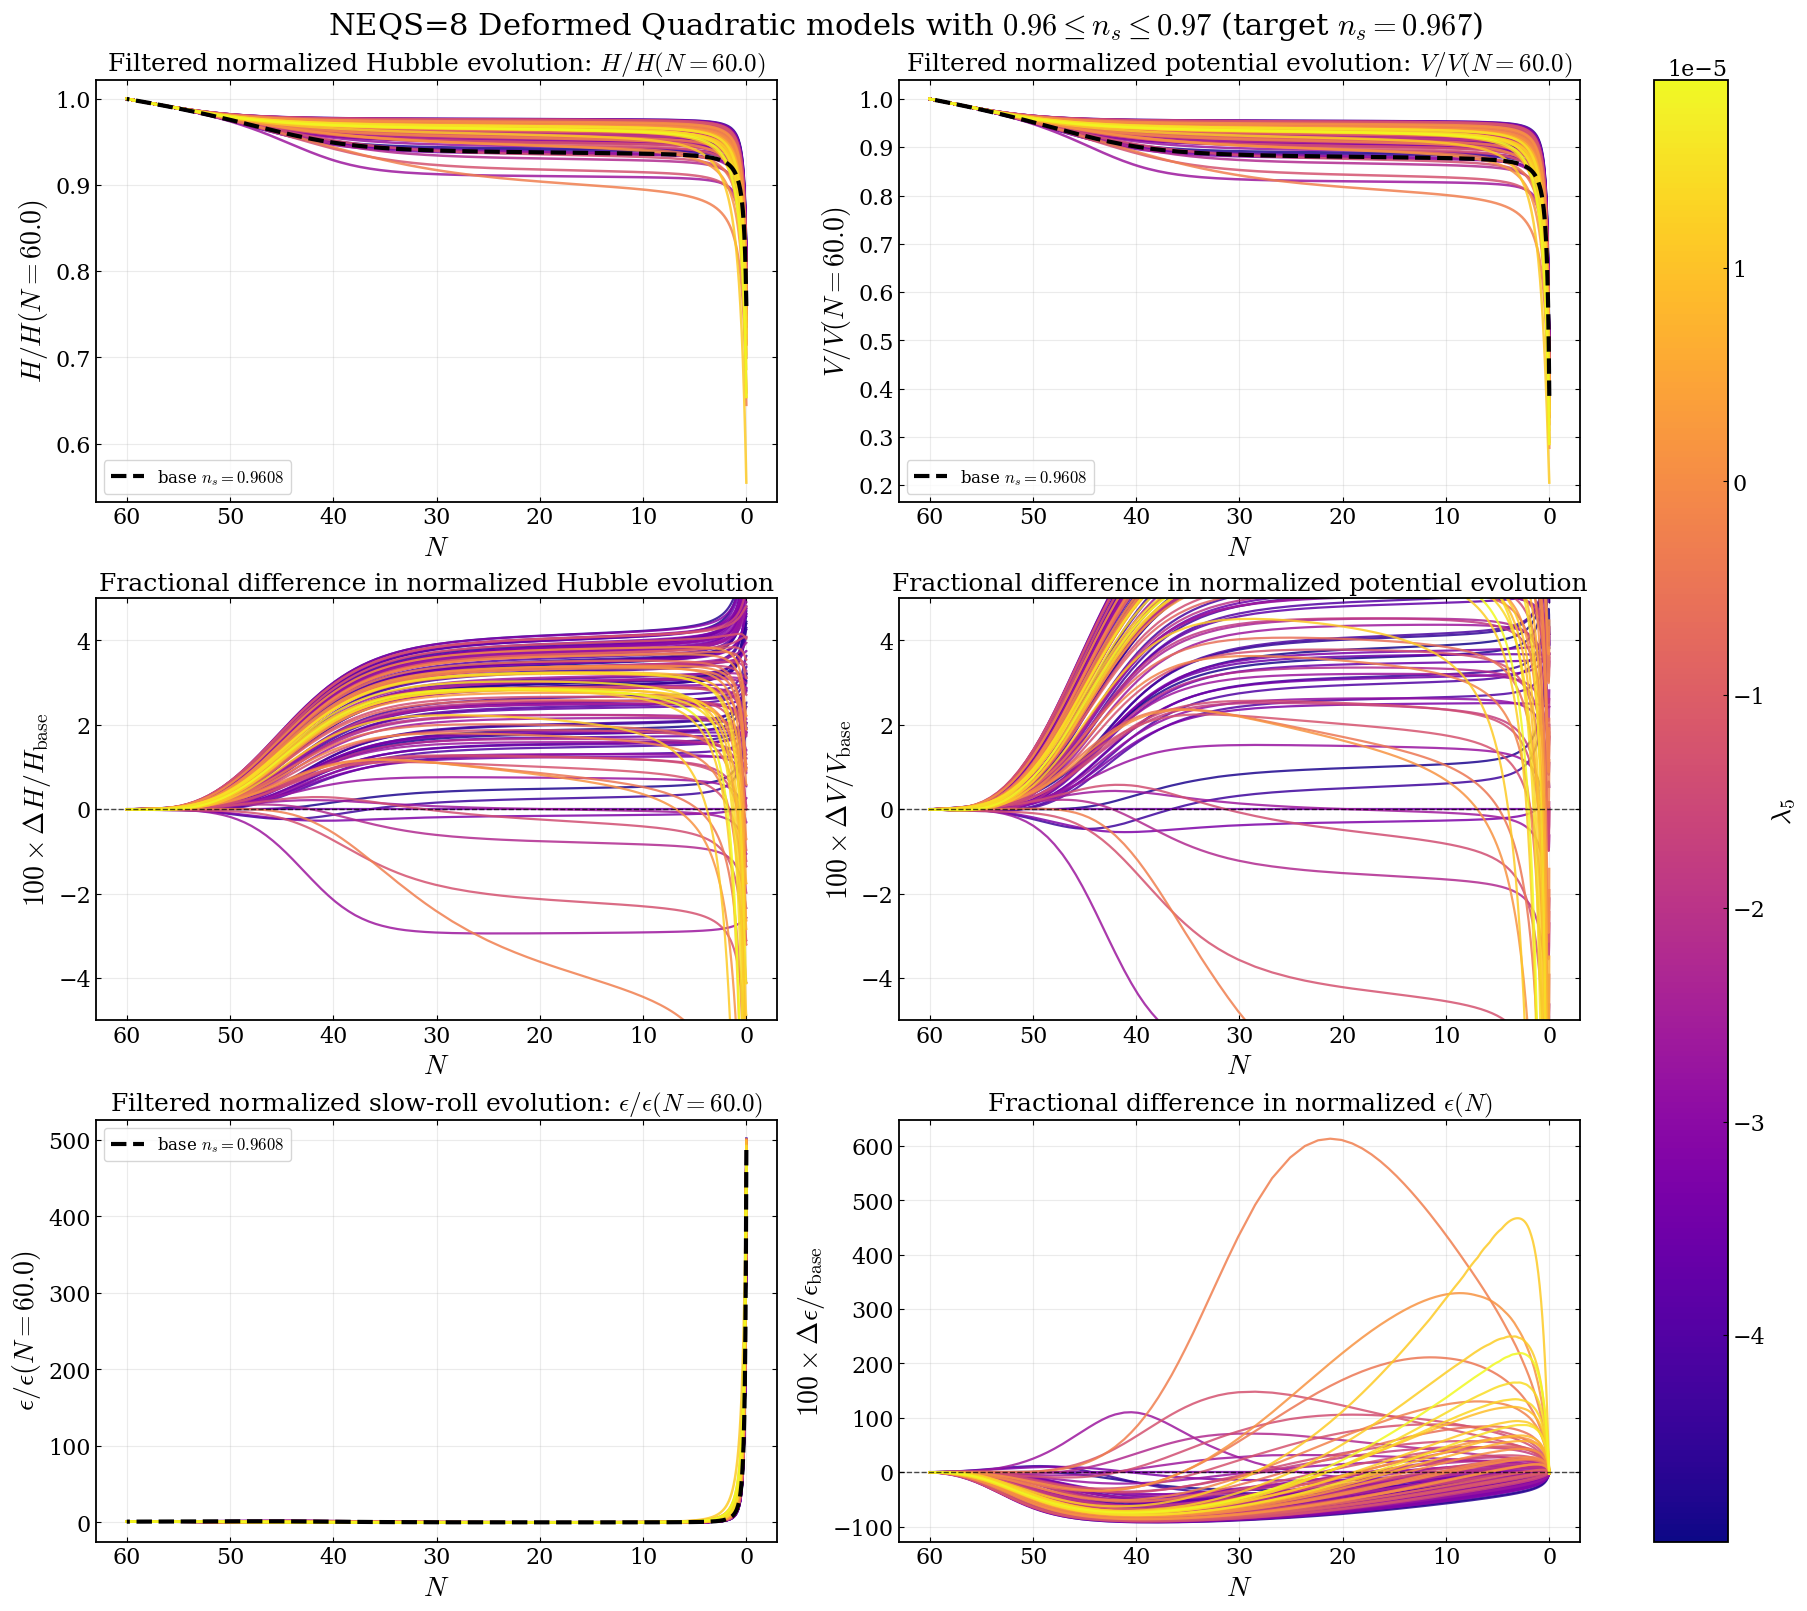

In [198]:
BACKGROUND_PLOT_CONFIG = {
    "higgs": {
        "base_value": -8.92461e-9,
        "ns_target": 0.967,
        "save_name": (
            "paper_higgs_neqs8_lam5_"
            "filtered_background.pdf"
        ),
    },

    "nonhiggs": {
        "base_value": -3.3792701497e-5,
        "ns_target": 0.967,
        "save_name": (
            "paper_nonhiggs_neqs8_lam5_"
            "filtered_background.pdf"
        ),
    },
}

background_results = {}

for model_tag, config in BACKGROUND_PLOT_CONFIG.items():

    print("\n" + "=" * 70)
    print(
        f"Running background analysis: "
        f"{MODEL_CONFIG[model_tag]['label']}"
    )
    print("=" * 70)

    lam5_values = param_values_by_model[model_tag][8]

    background_results[model_tag] = (
        plot_filtered_background_by_ns(
            NEQS=8,
            lamX_values=lam5_values,
            baseX=config["base_value"],
            base_path_root=base_path_root,
            model_tag=model_tag,

            ns_min=0.96,
            ns_max=0.97,
            ns_target=config["ns_target"],

            N_ref=60.0,
            N_window=(0, 60),

            frac_ylim=(-5, 5),
            eps_frac_ylim=None,

            save_name=config["save_name"],
        )
    )

In the plots above, EVERY curve is normalized at unitu at N=60. I am comparing relative evolution away from the CMB point, not the absolute background shapes here.

# Analyzing Parameter Relationships


One of the things I am seeing by comparing these models, is that fact that, before this section you can see that the $\Delta N$ when accounted for in Higgs case, reduces the Scalar Power spectra more so than the Deformed Quadratic Potential. **Why is that?** My suspiciton is that higher order parameters play a bigger role in mishaping the potential of the Quadratic Potential. Higgs is very flat early on and for a long time, it is like a plateau model, that is not the case with the deformed quadratic potential. So, effectively, under higher order flow perturbations the Higgs potential is more dynamically rigid, whereas it is possible that the deformed-qudratic may have more trajectory/shape freedom even when the total inflationary duration remains similar. You can also see this just by looking at the spread of the first slow roll parameter, $\epsilon$, for the Deformed Quadratic model vs the Higgs one.

In [199]:
def plot_filtered_V_vs_phi(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    model_tag="higgs",
    ns_min=0.96,
    ns_max=0.97,
    r_min=None,
    r_max=None,
    max_abs_alpha_s=None,
    N_ref=60.0,
    normalize_at_Nref=True,
    cmap_name="plasma",
    save_name=None,
    show=True,
):
    scan_name, scan_symbol = SCAN_INFO[NEQS]

    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)

    summary_all = load_batch_summaries(
        NEQS=NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    def sanitize_lam_values(values):
        return np.array(
            [
                item[0] if isinstance(item, tuple) else item
                for item in values
            ],
            dtype=float,
        )

    def get_summary_row(value):
        matches = summary_all.loc[
            np.isclose(
                summary_all[scan_name].to_numpy(dtype=float),
                value,
                rtol=1e-8,
                atol=max(1e-15, abs(value) * 1e-8),
            )
        ]

        if matches.empty:
            raise FileNotFoundError(
                f"No summary row found for "
                f"{scan_name}={value:.10e}, "
                f"model={model_tag}"
            )

        return matches.iloc[0]

    def load_path(value):
        val_str = f"{value:.10e}"

        folder = folder_for(
            NEQS=NEQS,
            param_name=scan_name,
            value=value,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )

        file_path = os.path.join(
            str(folder),
            f"path_neqs{NEQS}_{scan_name}_{val_str}.dat",
        )

        if not os.path.exists(file_path):
            raise FileNotFoundError(
                f"Missing path file: {file_path}"
            )

        return pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
        ).values

    def get_V_vs_phi(data):
        phi_raw = np.asarray(
            data[:, 0],
            dtype=float,
        )

        N_raw = np.asarray(
            data[:, NEQS],
            dtype=float,
        )

        V_raw = np.asarray(
            data[:, NEQS + 1],
            dtype=float,
        )

        finite = (
            np.isfinite(phi_raw)
            & np.isfinite(N_raw)
            & np.isfinite(V_raw)
        )

        phi_raw = phi_raw[finite]
        N_raw = N_raw[finite]
        V_raw = V_raw[finite]

        # Preserve the trajectory while arranging it by increasing N.
        dN = np.diff(N_raw)

        if np.all(dN >= 0):
            N_use = N_raw
            phi_use = phi_raw
            V_use = V_raw

        elif np.all(dN <= 0):
            N_use = N_raw[::-1]
            phi_use = phi_raw[::-1]
            V_use = V_raw[::-1]

        else:
            raise ValueError(
                "N is non-monotonic; refusing to reorder trajectory."
            )

        if normalize_at_Nref:
            if not (
                N_use.min()
                <= N_ref
                <= N_use.max()
            ):
                raise ValueError(
                    f"N_ref={N_ref} outside range "
                    f"[{N_use.min()}, {N_use.max()}]"
                )

            V_ref = np.interp(
                N_ref,
                N_use,
                V_use,
            )

            if abs(V_ref) < 1e-30:
                raise ValueError(
                    f"V(N_ref) too small at N_ref={N_ref}"
                )

            V_use = V_use / V_ref

        # Now check whether phi is monotonic along this trajectory.
        dphi = np.diff(phi_use)

        if np.all(dphi >= 0):
            return phi_use, V_use

        if np.all(dphi <= 0):
            return phi_use[::-1], V_use[::-1]

        raise ValueError(
            "phi is non-monotonic; V(phi) is multivalued "
            "along this trajectory."
        )

    # --------------------------------------------------
    # Load the base model
    # --------------------------------------------------

    base_row = get_summary_row(baseX)
    base_data = load_path(baseX)

    phi_base, V_base = get_V_vs_phi(
        base_data
    )

    # --------------------------------------------------
    # Load models passing cuts
    # --------------------------------------------------

    lam_values = sanitize_lam_values(
        lamX_values
    )

    models = []

    for lamX in lam_values:
        try:
            row = get_summary_row(lamX)

            ns = float(row["n_s"])
            r = float(row["r"])
            alpha_s = float(row["alpha_s"])
            N_end = float(row["original_N_end"])

            if not (ns_min <= ns <= ns_max):
                continue

            if r_min is not None and r < r_min:
                continue

            if r_max is not None and r > r_max:
                continue

            if (
                max_abs_alpha_s is not None
                and abs(alpha_s) > max_abs_alpha_s
            ):
                continue

            data = load_path(lamX)

            phi, V = get_V_vs_phi(data)

            models.append({
                "lamX": lamX,
                "phi": phi,
                "V": V,
                "N_end": N_end,
            })

        except (FileNotFoundError, ValueError) as exc:
            print(
                f"Skipping {scan_name}={lamX:.5e}: {exc}"
            )

    if not models:
        raise ValueError(
            f"No {model_label} models passed the cuts."
        )

    # --------------------------------------------------
    # Plot V(phi)
    # --------------------------------------------------

    N_end_values = np.array([
        model["N_end"]
        for model in models
    ])

    cmap = plt.get_cmap(cmap_name)

    norm = mcolors.Normalize(
        vmin=np.nanmin(N_end_values),
        vmax=np.nanmax(N_end_values),
    )

    fig, ax = plt.subplots(
        figsize=(10, 7),
        constrained_layout=True,
    )

    for model in models:
        ax.plot(
            model["phi"],
            model["V"],
            color=cmap(norm(model["N_end"])),
            linewidth=1.6,
            alpha=0.8,
        )

    ax.plot(
        phi_base,
        V_base,
        color="black",
        linewidth=3.0,
        linestyle="--",
        label=(
            rf"Base model, "
            rf"$n_s={float(base_row['n_s']):.4f}$"
        ),
    )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        pad=0.02,
    )

    cbar.set_label(
        r"$N_{\rm end}^{\rm original}$"
    )

    ax.set_xlabel(r"$\phi$")

    if normalize_at_Nref:
        ax.set_ylabel(
            rf"$V(\phi)/V(N={N_ref:g})$"
        )
    else:
        ax.set_ylabel(r"$V(\phi)$")

    ax.set_title(
        rf"{model_label}: reconstructed $V(\phi)$"
        "\n"
        rf"${ns_min}\leq n_s\leq {ns_max}$"
    )

    ax.grid(True, alpha=0.25)

    ax.legend(
        frameon=False,
        loc="best",
    )

    if save_name is None:
        normalization_tag = (
            "normalized"
            if normalize_at_Nref
            else "physical"
        )

        save_name = (
            f"neqs{NEQS}_{model_tag}_{scan_name}_"
            f"V_vs_phi_{normalization_tag}.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return models

In [200]:
def plot_filtered_V_vs_delta_phi(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    model_tag="higgs",
    ns_min=0.96,
    ns_max=0.97,
    r_min=None,
    r_max=None,
    max_abs_alpha_s=None,
    N_ref=60.0,
    cmap_name="plasma",
    save_name=None,
    show=True,
):
    scan_name, scan_symbol = SCAN_INFO[NEQS]

    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)

    # Load summaries only once.
    summary_all = load_batch_summaries(
        NEQS=NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    def sanitize_lam_values(values):
        return np.array(
            [
                item[0] if isinstance(item, tuple) else item
                for item in values
            ],
            dtype=float,
        )

    def get_summary_row(value):
        matches = summary_all.loc[
            np.isclose(
                summary_all[scan_name].to_numpy(dtype=float),
                value,
                rtol=1e-8,
                atol=max(1e-15, abs(value) * 1e-8),
            )
        ]

        if matches.empty:
            raise FileNotFoundError(
                f"No summary row found for "
                f"{scan_name}={value:.10e}, "
                f"model={model_tag}"
            )

        return matches.iloc[0]

    def load_path(value):
        val_str = f"{value:.10e}"

        folder = folder_for(
            NEQS=NEQS,
            param_name=scan_name,
            value=value,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )

        file_path = os.path.join(
            str(folder),
            f"path_neqs{NEQS}_{scan_name}_{val_str}.dat",
        )

        if not os.path.exists(file_path):
            raise FileNotFoundError(
                f"Missing path file: {file_path}"
            )

        return pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
        ).values

    def get_aligned_V_phi(data):
        """
        Return V/V(N_ref) as a function of

            delta_phi = phi - phi(N_ref).

        The trajectory is first ordered using N so phi, V, and N remain
        physically paired.
        """
        phi_raw = np.asarray(
            data[:, 0],
            dtype=float,
        )

        N_raw = np.asarray(
            data[:, NEQS],
            dtype=float,
        )

        V_raw = np.asarray(
            data[:, NEQS + 1],
            dtype=float,
        )

        finite = (
            np.isfinite(phi_raw)
            & np.isfinite(N_raw)
            & np.isfinite(V_raw)
        )

        phi_raw = phi_raw[finite]
        N_raw = N_raw[finite]
        V_raw = V_raw[finite]

        if len(N_raw) < 2:
            raise ValueError(
                "Not enough finite path points."
            )

        # Preserve trajectory ordering.
        dN = np.diff(N_raw)

        if np.all(dN >= 0):
            N_use = N_raw
            phi_use = phi_raw
            V_use = V_raw

        elif np.all(dN <= 0):
            N_use = N_raw[::-1]
            phi_use = phi_raw[::-1]
            V_use = V_raw[::-1]

        else:
            raise ValueError(
                "N is non-monotonic; refusing to reorder trajectory."
            )

        if not (
            N_use.min()
            <= N_ref
            <= N_use.max()
        ):
            raise ValueError(
                f"N_ref={N_ref} outside range "
                f"[{N_use.min():.4f}, {N_use.max():.4f}]"
            )

        # Pivot values.
        phi_ref = np.interp(
            N_ref,
            N_use,
            phi_use,
        )

        V_ref = np.interp(
            N_ref,
            N_use,
            V_use,
        )

        if not np.isfinite(phi_ref):
            raise ValueError(
                f"Non-finite phi at N_ref={N_ref}."
            )

        if (
            not np.isfinite(V_ref)
            or abs(V_ref) < 1e-30
        ):
            raise ValueError(
                f"Invalid V_ref at N_ref={N_ref}: "
                f"{V_ref}"
            )

        delta_phi = phi_use - phi_ref
        V_norm = V_use / V_ref

        # Check monotonicity of the field trajectory.
        dphi = np.diff(delta_phi)

        if np.all(dphi >= 0):
            return delta_phi, V_norm, phi_ref

        if np.all(dphi <= 0):
            return (
                delta_phi[::-1],
                V_norm[::-1],
                phi_ref,
            )

        raise ValueError(
            "phi is non-monotonic, so V(phi) is multivalued."
        )

    # --------------------------------------------------
    # Load base trajectory
    # --------------------------------------------------

    base_row = get_summary_row(baseX)
    base_data = load_path(baseX)

    delta_phi_base, V_base, phi_ref_base = (
        get_aligned_V_phi(base_data)
    )

    # --------------------------------------------------
    # Load accepted models
    # --------------------------------------------------

    models = []

    for lamX in sanitize_lam_values(lamX_values):
        try:
            row = get_summary_row(lamX)

            ns = float(row["n_s"])
            r = float(row["r"])
            alpha_s = float(row["alpha_s"])
            N_end = float(row["original_N_end"])

            if not (ns_min <= ns <= ns_max):
                continue

            if r_min is not None and r < r_min:
                continue

            if r_max is not None and r > r_max:
                continue

            if (
                max_abs_alpha_s is not None
                and abs(alpha_s) > max_abs_alpha_s
            ):
                continue

            data = load_path(lamX)

            delta_phi, V_norm, phi_ref = (
                get_aligned_V_phi(data)
            )

            models.append({
                "lamX": lamX,
                "delta_phi": delta_phi,
                "V_norm": V_norm,
                "phi_ref": phi_ref,
                "delta_phi_total": (
                    np.nanmax(delta_phi)
                    - np.nanmin(delta_phi)
                ),
                "N_end": N_end,
                "n_s": ns,
                "r": r,
                "alpha_s": alpha_s,
            })

        except (FileNotFoundError, ValueError) as exc:
            print(
                f"Skipping {scan_name}={lamX:.5e}: {exc}"
            )

    if not models:
        raise ValueError(
            f"No {model_label} models passed the cuts."
        )

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    N_end_values = np.array([
        model["N_end"]
        for model in models
    ])

    cmap = plt.get_cmap(cmap_name)

    norm = mcolors.Normalize(
        vmin=np.nanmin(N_end_values),
        vmax=np.nanmax(N_end_values),
    )

    fig, ax = plt.subplots(
        figsize=(10, 7),
        constrained_layout=True,
    )

    for model in models:
        ax.plot(
            model["delta_phi"],
            model["V_norm"],
            color=cmap(norm(model["N_end"])),
            linewidth=1.6,
            alpha=0.8,
        )

    # Base model.
    ax.plot(
        delta_phi_base,
        V_base,
        color="black",
        linewidth=3.0,
        linestyle="--",
        label=(
            rf"Base model, "
            rf"$n_s={float(base_row['n_s']):.4f}$"
        ),
    )

    # Common CMB reference point.
    ax.scatter(
        0.0,
        1.0,
        color="black",
        s=55,
        zorder=10,
        label=rf"$N={N_ref:g}$ reference",
    )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        pad=0.02,
    )

    cbar.set_label(
        r"$N_{\rm end}^{\rm original}$"
    )

    ax.axvline(
        0.0,
        color="black",
        linestyle=":",
        linewidth=1.2,
        alpha=0.65,
    )

    ax.axhline(
        1.0,
        color="black",
        linestyle=":",
        linewidth=1.2,
        alpha=0.65,
    )

    ax.set_xlabel(
        rf"$\Delta\phi=\phi-\phi(N={N_ref:g})$"
    )

    ax.set_ylabel(
        rf"$V(\phi)/V(N={N_ref:g})$"
    )

    ax.set_title(
        rf"{model_label}: pivot-aligned reconstructed potentials"
        "\n"
        rf"${ns_min}\leq n_s\leq {ns_max}$"
    )

    ax.grid(True, alpha=0.25)

    ax.legend(
        frameon=False,
        loc="best",
    )

    if save_name is None:
        save_name = (
            f"neqs{NEQS}_{model_tag}_{scan_name}_"
            f"V_vs_delta_phi.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return models


Plotting pivot-aligned V(phi): Higgs


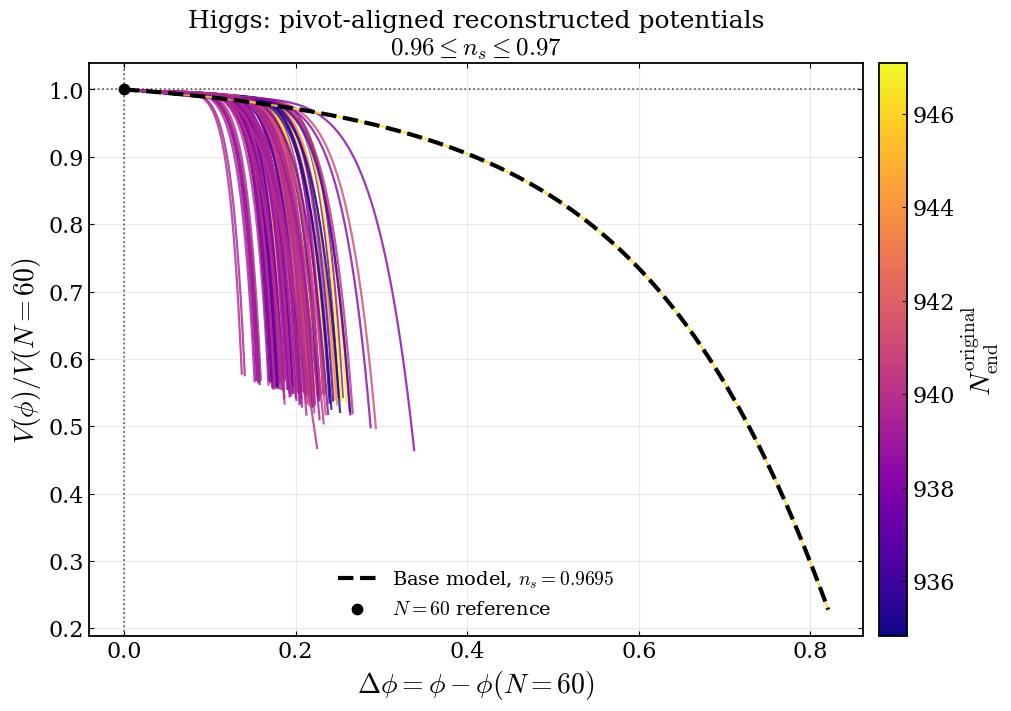


Plotting pivot-aligned V(phi): Deformed Quadratic


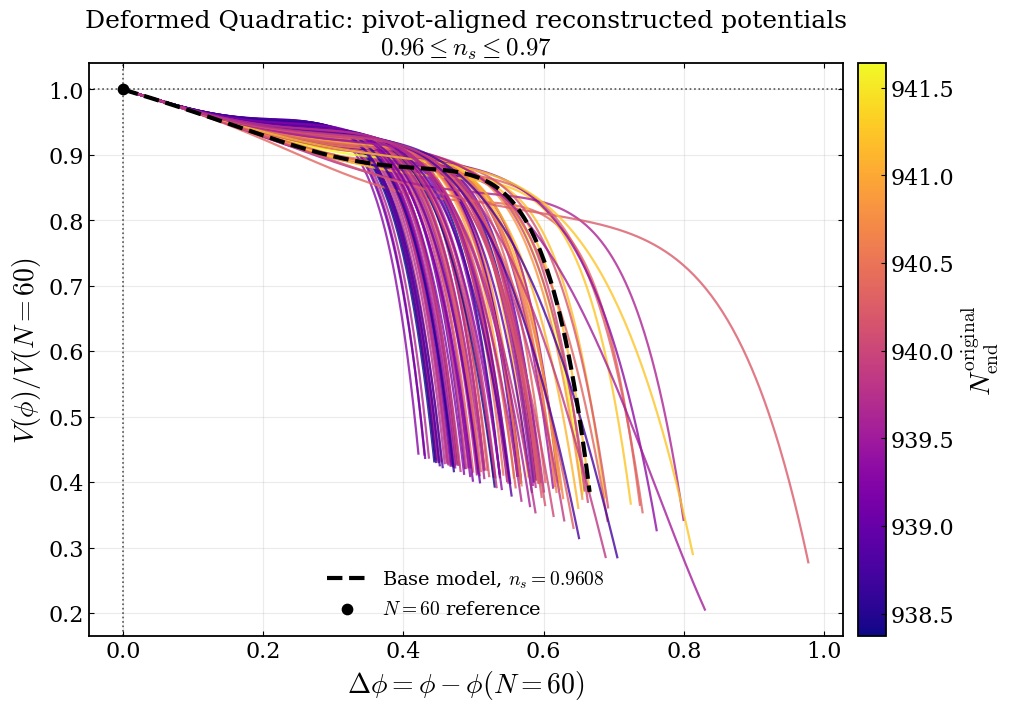

In [201]:
VPHI_ALIGNED_CONFIG = {
    "higgs": {
        "base_value": -8.92461e-9,
        "r_min": 2.737e-3 - 0.001,
        "r_max": 2.737e-3 + 0.001,
        "save_name": (
            "paper_higgs_V_vs_delta_phi.pdf"
        ),
    },

    "nonhiggs": {
        "base_value": -3.3792701497e-5,
        "r_min": 3.2958886892e-2 - 0.001,
        "r_max": 3.2958886892e-2 + 0.001,
        "save_name": (
            "paper_nonhiggs_V_vs_delta_phi.pdf"
        ),
    },
}


Vphi_aligned_results = {}

for model_tag, config in VPHI_ALIGNED_CONFIG.items():

    print("\n" + "=" * 70)
    print(
        f"Plotting pivot-aligned V(phi): "
        f"{MODEL_CONFIG[model_tag]['label']}"
    )
    print("=" * 70)

    Vphi_aligned_results[model_tag] = (
        plot_filtered_V_vs_delta_phi(
            NEQS=8,
            lamX_values=param_values_by_model[model_tag][8],
            baseX=config["base_value"],
            base_path_root=base_path_root,
            model_tag=model_tag,

            ns_min=0.96,
            ns_max=0.97,

            r_min=config["r_min"],
            r_max=config["r_max"],

            max_abs_alpha_s=0.005,

            N_ref=60.0,

            save_name=config["save_name"],
        )
    )

The plot above for the potentials as a function of teh field basically, are *Normalized Inflationary Potentials aligned at the CMB Pivot*. So each reconstructed potential is shifted such that $\phi(N_{ref}) =0$ and normalized by its respective value at the pivot, $V(\phi)/V(N_{ref})$ where $N_{ref}=60$. Doing so removes any arbitrary field offsets and potential normalizations, allowing the intrinsic differences in potential shape near the observable window to be compared more effectively. The reconstruction algorithm is essentially finding many potentials that are locally indistinguishable from Higgs around the pivot, but which differ once inflation progresses away from the observable scales. Whereas it seems that the Deformed Quad model seems to vary parameters that are perturbing the potential without necessarily leaving that fiducial trajectory.

**For Higgs:**
I am seeing that $V(\phi)$ for Higgs model base samples to 0.8. Whereas the other Higgs models found only sample to 0.2 in $\phi$.


**For Deformed Quad:**
The base for the deformed quadratic sits rather comfortably in the sample phi region!


## Impact of Higher Order Parameters on Spectra

Assuming:

$D_s = median |100*\frac{P^s_{shifted} - P^s_{ref}}{P^s_{ref}}|$

$D_t = median |100*\frac{P^t_{shifted} - P^t_{ref}}{P^t_{ref}}|$


First, let's confirm everything saved inside of **spectral results**.

In [202]:
##Tells me what is inside of spectral results

print(
    spectral_results["higgs"]["models"].columns.tolist()
)


['NEQS', 'param_name', 'value', 'lam2', 'lam3', 'lam4', 'lam5', 'r', 'ns', 'alpha_s', 'original_N_end', 'deltaN_from_ref_base', 'abs_deltaN_from_ref_base', 'D_s_unshift', 'D_s_shift', 'D_t_unshift', 'D_t_shift', 'D_s', 'D_t']


In [203]:
spectral_results["higgs"]["models"][
    [
        "lam2",
        "lam3",
        "lam4",
        "lam5",
        "D_s_unshift",
        "D_s_shift",
        "D_t_unshift",
        "D_t_shift",
    ]
].head()

,lam2,lam3,lam4,lam5,D_s_unshift,D_s_shift,D_t_unshift,D_t_shift
0,0.000338,0.001231,-0.000126,-0.000050,0.388936,0.928678,0.586232,0.371686
1,-0.000195,0.003970,0.000437,-0.000049,9.650407,0.447543,0.963855,0.776715
2,-0.000103,0.003268,0.000283,-0.000049,7.930962,0.204351,0.845150,0.553575
3,0.000326,0.001226,-0.000120,-0.000048,3.801170,0.052667,0.740671,0.473907
4,0.000243,0.002204,0.000062,-0.000048,5.661961,0.048912,0.825271,0.569350


In [204]:
print(
    spectral_results["nonhiggs"]["models"].columns.tolist()
)

['NEQS', 'param_name', 'value', 'lam2', 'lam3', 'lam4', 'lam5', 'r', 'ns', 'alpha_s', 'original_N_end', 'deltaN_from_ref_base', 'abs_deltaN_from_ref_base', 'D_s_unshift', 'D_s_shift', 'D_t_unshift', 'D_t_shift', 'D_s', 'D_t']


In [205]:
spectral_results["nonhiggs"]["models"][
    [
        "lam2",
        "lam3",
        "lam4",
        "lam5",
        "D_s_unshift",
        "D_s_shift",
        "D_t_unshift",
        "D_t_shift",
    ]
].head()

,lam2,lam3,lam4,lam5,D_s_unshift,D_s_shift,D_t_unshift,D_t_shift
0,0.000305,0.002208,0.000067,-0.000050,4.155048,2.109447,5.828201,5.309407
1,0.000142,0.000864,-0.000173,-0.000049,3.423024,1.478963,4.960299,4.280455
2,0.000380,0.000127,-0.000301,-0.000049,0.159259,0.454909,3.096870,2.937746
3,-0.000142,0.001310,-0.000090,-0.000049,2.190761,0.643214,5.076391,4.580081
4,0.000181,-0.000158,-0.000335,-0.000048,1.377017,1.372126,2.905234,2.912305


 Now, I can proceed to looking at the spectral distance in terms of the higher order parameters.

In [206]:
def plot_spectral_distance_vs_hierarchy(
    model_df,
    model_tag,
    parameter_columns=("lam2","lam3", "lam4", "lam5"),
    distance_columns=("D_s", "D_t"),
    n_bins=12,
    min_models_per_bin=3,
    color_by=None,
    tolerance=5.0,
    save_name=None,
    show=True,
):
    """
    Plot spectral distance versus higher-order flow parameters.

    Parameters
    ----------
    model_df : DataFrame
        Must contain lam2/lam3/lam4/lam5 and D_s/D_t.

    distance_columns : tuple
        Usually ("D_s","D_t"). Since D_s and D_t are aliases,
        you can point them to shifted or unshifted versions beforehand.
    """

    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)

    required = set(parameter_columns) | set(distance_columns)

    if color_by is not None:
        required.add(color_by)

    missing = required.difference(model_df.columns)

    if missing:
        raise ValueError(
            f"Missing required columns: {sorted(missing)}"
        )

    df = model_df.copy()

    mask = np.ones(len(df), dtype=bool)

    for col in required:
        mask &= np.isfinite(df[col])

    df = df.loc[mask].copy()

    parameter_labels = {
        "lam2": r"$^{2}\lambda_H$",
        "lam3": r"$^{3}\lambda_H$",
        "lam4": r"$^{4}\lambda_H$",
        "lam5": r"$^{5}\lambda_H$",
    }

    distance_labels = {
        "D_s": r"$D_s$ (%)",
        "D_t": r"$D_t$ (%)",
    }

    fig, axes = plt.subplots(
        len(distance_columns),
        len(parameter_columns),
        figsize=(18,10),
        constrained_layout=True,
        sharey="row",
    )

    axes = np.asarray(axes).reshape(
        len(distance_columns),
        len(parameter_columns),
    )

    # -----------------------------------
    # Optional colouring
    # -----------------------------------

    if color_by is not None:

        norm = mcolors.Normalize(
            vmin=df[color_by].min(),
            vmax=df[color_by].max(),
        )

        cmap = plt.cm.viridis

    else:

        norm = None
        cmap = None

    binned_rows = []

    # ===================================
    # Loop over λ3 λ4 λ5
    # ===================================

    for j, parameter in enumerate(parameter_columns):

        x = df[parameter].to_numpy()

        edges = np.linspace(
            x.min(),
            x.max(),
            n_bins + 1,
        )

        centers = 0.5 * (
            edges[:-1] + edges[1:]
        )

        which_bin = np.digitize(
            x,
            edges[1:-1],
        )

        for i, distance in enumerate(distance_columns):

            ax = axes[i, j]

            y = df[distance].to_numpy()

            # -----------------------------
            # Scatter
            # -----------------------------

            if color_by is None:

                ax.scatter(
                    x,
                    y,
                    s=24,
                    alpha=0.45,
                )

            else:

                ax.scatter(
                    x,
                    y,
                    c=df[color_by],
                    cmap=cmap,
                    norm=norm,
                    s=28,
                    alpha=0.6,
                )

            # -----------------------------
            # Median trend
            # -----------------------------

            med = np.full(n_bins, np.nan)
            p16 = np.full(n_bins, np.nan)
            p84 = np.full(n_bins, np.nan)

            for b in range(n_bins):

                m = which_bin == b

                if np.sum(m) < min_models_per_bin:
                    continue

                vals = y[m]

                med[b] = np.nanmedian(vals)
                p16[b] = np.nanpercentile(vals,16)
                p84[b] = np.nanpercentile(vals,84)

                binned_rows.append({

                    "model_tag": model_tag,
                    "parameter": parameter,
                    "distance": distance,
                    "bin_center": centers[b],
                    "count": np.sum(m),
                    "median": med[b],
                    "p16": p16[b],
                    "p84": p84[b],
                })

            valid = np.isfinite(med)

            if np.any(valid):
                #supposed to be 68 % spread
#                 ax.fill_between(
#                     centers[valid],
#                     p16[valid],
#                     p84[valid],
#                     alpha=0.20,
#                 )

                ax.plot(
                    centers[valid],
                    med[valid],
                    "-o",
                    lw=2,
                    ms=5,
                )

            if tolerance is not None:

                ax.axhline(
                    tolerance,
                    color="black",
                    ls="--",
                    lw=1.3,
                    alpha=0.6,
                )

            ax.grid(alpha=0.25)

            ax.set_xlabel(
                parameter_labels.get(
                    parameter,
                    parameter,
                )
            )

            if j == 0:

                ax.set_ylabel(
                    distance_labels[distance]
                )

            if i == 0:

                ax.set_title(
                    parameter_labels.get(
                        parameter,
                        parameter,
                    )
                )

    if color_by is not None:

        sm = ScalarMappable(
            norm=norm,
            cmap=cmap,
        )

        sm.set_array([])

        cbar = fig.colorbar(
            sm,
            ax=axes,
            pad=0.01,
        )

        cbar.set_label(color_by)

    fig.suptitle(
        rf"{model_label}: spectral distance versus higher-order flow parameters",
        fontsize=20,
    )

    if save_name is None:

        save_name = (
            f"{model_tag}_DsDt_vs_hierarchy.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return (
        df,
        pd.DataFrame(binned_rows),
    )

For Higgs:

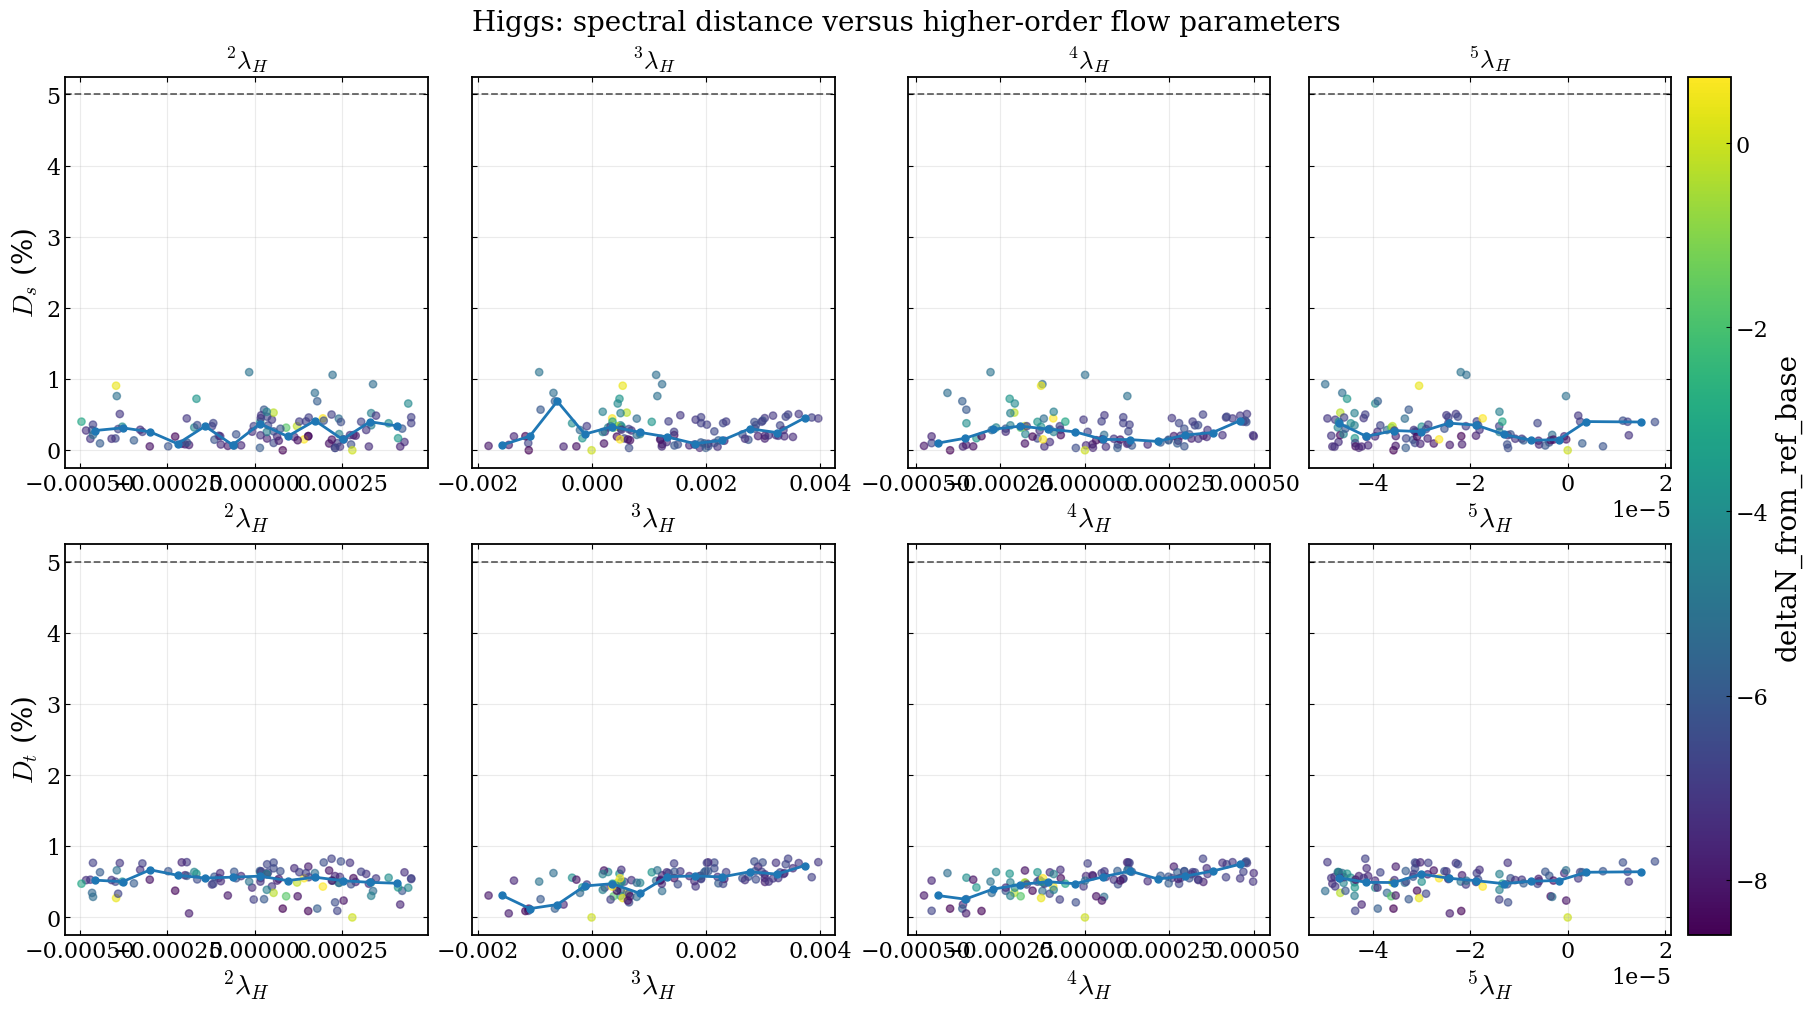

In [207]:
higgs_distance_df, higgs_binned_df = (
    plot_spectral_distance_vs_hierarchy(
        model_df=spectral_results["higgs"]["models"],
        model_tag="higgs",

        parameter_columns=(
            "lam2",
            "lam3",
            "lam4",
            "lam5",
        ),

        n_bins=12,
        min_models_per_bin=3,

        color_by="deltaN_from_ref_base",
        tolerance=5.0,

        save_name=(
            "paper_higgs_Ds_Dt_"
            "vs_lam2_lam3_lam4_lam5.pdf"
        ),
    )
)

For Deformed Quad:

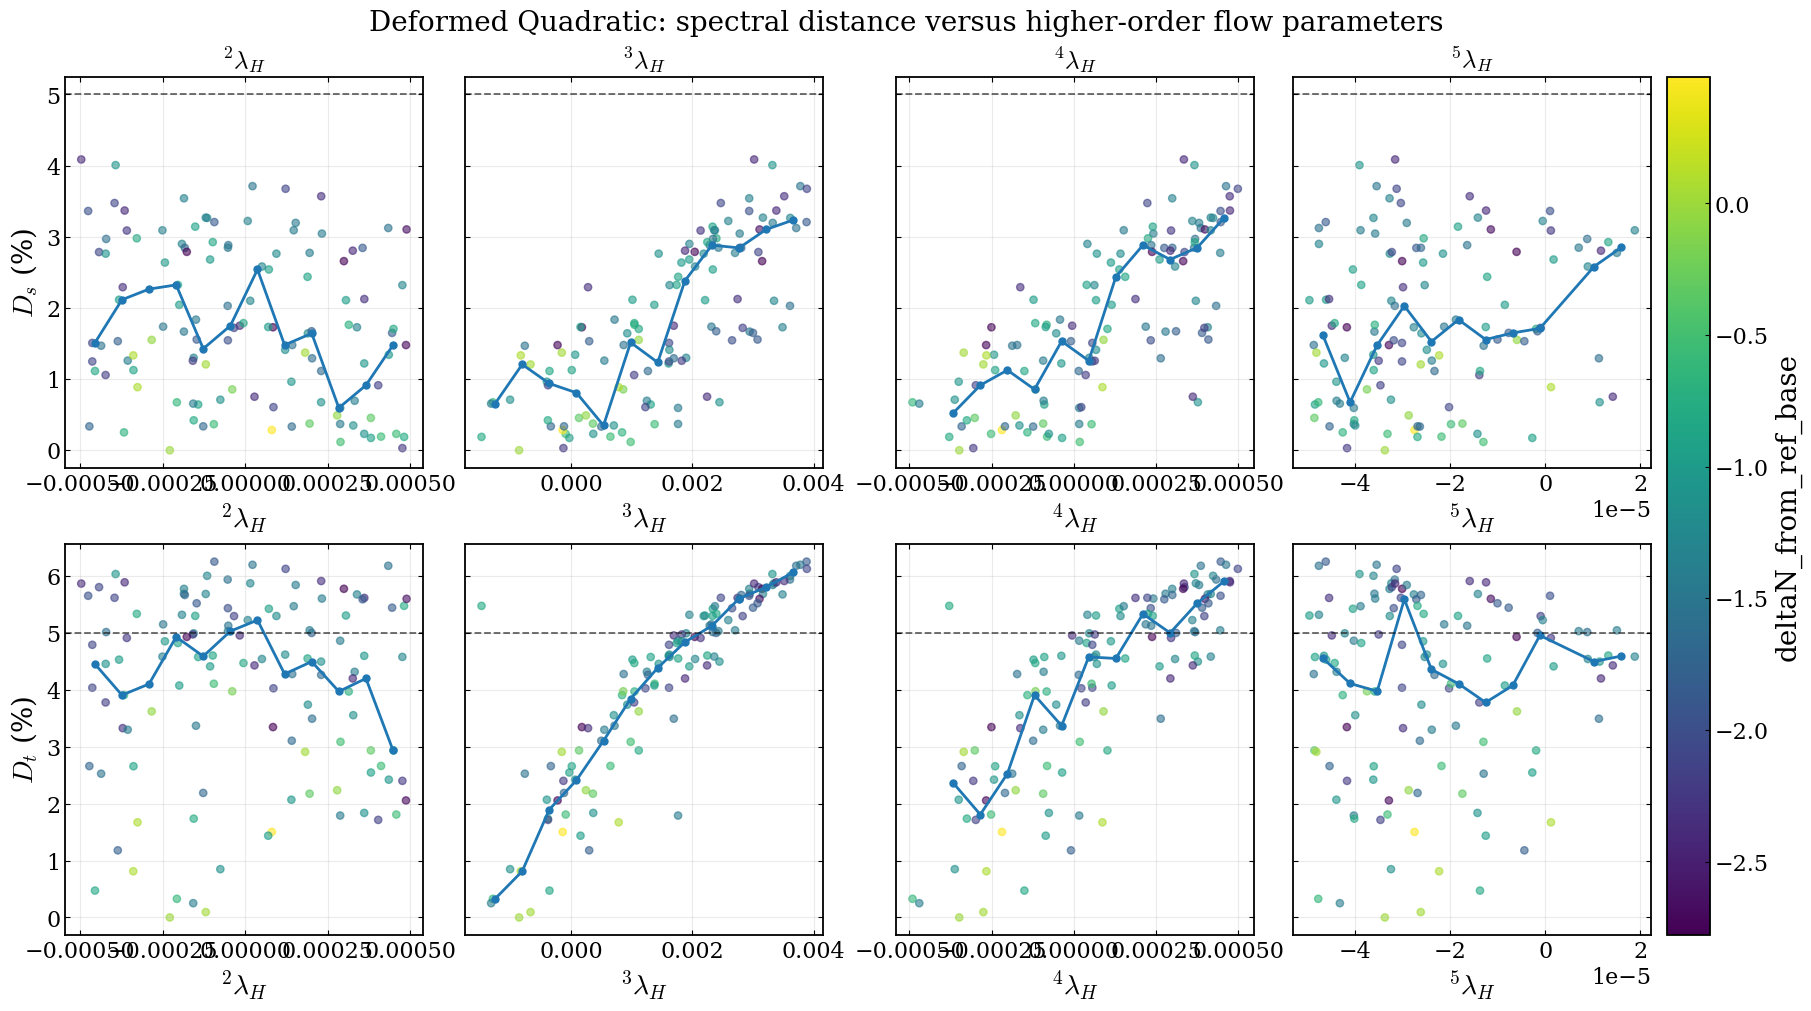

In [208]:
nonhiggs_distance_df, nonhiggs_binned_df = (
    plot_spectral_distance_vs_hierarchy(
        model_df=spectral_results["nonhiggs"]["models"],
        model_tag="nonhiggs",

        parameter_columns=(
            "lam2",
            "lam3",
            "lam4",
            "lam5",
        ),

        n_bins=12,
        min_models_per_bin=3,

        color_by="deltaN_from_ref_base",
        tolerance=5.0,

        save_name=(
            "paper_nonhiggs_Ds_Dt_"
            "vs_lam2_lam3_lam4_lam5.pdf"
        ),
    )
)

This is hard to read, so I am going to look at some Pearson and maybe Spearman coeffcients. 

In [209]:
from scipy.stats import pearsonr, spearmanr

def hierarchy_correlations(
    model_df,
    parameters=("lam2","lam3", "lam4", "lam5", "deltaN_from_ref_base"),
    distances=("D_s", "D_t"),
):
    """
    Compute Pearson and Spearman correlations between
    hierarchy parameters and spectral distances.
    """

    rows = []

    for param in parameters:
        for dist in distances:

            df = model_df[[param, dist]].dropna()

            if len(df) < 3:
                continue

            x = df[param].to_numpy()
            y = df[dist].to_numpy()

            pearson_r, pearson_p = pearsonr(x, y)
            spearman_rho, spearman_p = spearmanr(x, y)

            rows.append({
                "parameter": param,
                "distance": dist,
                "N": len(df),
                "pearson_r": pearson_r,
                "pearson_p": pearson_p,
                "spearman_rho": spearman_rho,
                "spearman_p": spearman_p,
            })

    results = pd.DataFrame(rows)

    print(results.round(4))

    return results

The tables below represent a correlation test between different high order parameters and the absolute percent difference in the unshifted spectra relative to the base. So, we are trying to look at how changing this paramter relates to the spectrum.


The first parameter (lamX) is compared to either Ds or Dt (dependent variable). It looks then at the number of models for this comparison. Following this, we examine pearson r and pearson p. Pearson r measures linear correlation:

    r=1 is perfectly correlated

    r=0 is no linear relationship

    r=-1 is perfectly negatively correlated

Pearson p-value is not the strength of the correlation but rather how likely it is for this relationship to exist. If p is less than maybe 0.05 it is statistically significant and if it is greater 0.05 then you can't really claim a correlation. It is testing validity of claim I guess.

[Most of my pearson p below are above the 0.05 for at least Higgs case]

Then Spearman $\rho$ is testing monotonicity of variables, so asking does it generally increase or decrease? Pays less attention to shape. 

    +1 is perfect monotonic increase

    0 is no linear trend

    -1 is perfect monotonic decrease
    
Spearman p is same as Pearson p, confirming or denying how confident one is about the trend.

For Higgs:

In [210]:
corr_higgs = hierarchy_correlations(
    spectral_results["higgs"]["models"]
)

              parameter distance    N  pearson_r  pearson_p  spearman_rho  \
0                  lam2      D_s  106     0.0518     0.5977        0.0614   
1                  lam2      D_t  106    -0.1205     0.2184       -0.1236   
2                  lam3      D_s  106    -0.0385     0.6955        0.0407   
3                  lam3      D_t  106     0.6661     0.0000        0.6323   
4                  lam4      D_s  106    -0.0695     0.4791        0.0107   
5                  lam4      D_t  106     0.5889     0.0000        0.5936   
6                  lam5      D_s  106    -0.1111     0.2570       -0.1090   
7                  lam5      D_t  106     0.0729     0.4576        0.0706   
8  deltaN_from_ref_base      D_s  106     0.3537     0.0002        0.4664   
9  deltaN_from_ref_base      D_t  106    -0.1746     0.0735       -0.0979   

   spearman_p  
0      0.5319  
1      0.2067  
2      0.6787  
3      0.0000  
4      0.9135  
5      0.0000  
6      0.2661  
7      0.4720  
8      0

Strong Higgs correlations:

    - lam3 and D_t (+)
    - lam4 and D_t (+)
    - deltaN_from_ref_base and D_s (+)

For Quad:

In [211]:
corr_quad = hierarchy_correlations(
    spectral_results["nonhiggs"]["models"]
)

              parameter distance    N  pearson_r  pearson_p  spearman_rho  \
0                  lam2      D_s  120    -0.2398     0.0083       -0.2238   
1                  lam2      D_t  120    -0.0160     0.8623       -0.0394   
2                  lam3      D_s  120     0.7406     0.0000        0.7612   
3                  lam3      D_t  120     0.8913     0.0000        0.9256   
4                  lam4      D_s  120     0.7378     0.0000        0.7435   
5                  lam4      D_t  120     0.8033     0.0000        0.8201   
6                  lam5      D_s  120     0.1783     0.0514        0.1665   
7                  lam5      D_t  120     0.0394     0.6691       -0.0145   
8  deltaN_from_ref_base      D_s  120    -0.3678     0.0000       -0.3523   
9  deltaN_from_ref_base      D_t  120    -0.4351     0.0000       -0.4120   

   spearman_p  
0      0.0140  
1      0.6690  
2      0.0000  
3      0.0000  
4      0.0000  
5      0.0000  
6      0.0692  
7      0.8753  
8      0

Strong Quad correlations:

    - lam3 and D_t (+)
    - lam4 and D_t (+)
    - lam3 and D_s (+)
    - lam4 and D_s (+)
    - deltaN_from_ref_base and D_t (-)
    - deltaN_from_ref_base and D_s (-)
    

## Generate correlation matrix of variables

Look for high correlations ~ 1

In [212]:
def plot_hierarchy_correlation_matrix(
    model_df,
    model_tag,
    columns=(
        "lam2",
        "lam3",
        "lam4",
        "lam5",
        "deltaN_from_ref_base",
    ),
    method="spearman",
    save_name=None,
):
    """
    Correlation matrix among hierarchy parameters.
    """

    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)

    df = model_df[list(columns)].copy()

    df = df.dropna()

    if method.lower() == "pearson":
        corr = df.corr(method="pearson")
        title = "Pearson"
    else:
        corr = df.corr(method="spearman")
        title = "Spearman"

    rename = {
        "lam2": r"$\lambda_2$",
        "lam3": r"$\lambda_3$",
        "lam4": r"$\lambda_4$",
        "lam5": r"$\lambda_5$",
        "deltaN_from_ref_base": r"$\Delta N$",
    }

    corr = corr.rename(
        index=rename,
        columns=rename,
    )

    fig, ax = plt.subplots(figsize=(7,6))

    im = ax.imshow(
        corr,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
    )

    ax.set_xticks(np.arange(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")

    ax.set_yticks(np.arange(len(corr.index)))
    ax.set_yticklabels(corr.index)

    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(
                j,
                i,
                f"{corr.iloc[i,j]:.2f}",
                ha="center",
                va="center",
                fontsize=10,
            )

    cbar = plt.colorbar(
        im,
        ax=ax,
        label=f"{title} correlation",
    )

    cbar.set_label(
        f"{title} correlation",
        fontsize=13,
    )

    ax.set_title(
    f"{model_label}: {title} Correlation Matrix",
    fontsize=13,
)

    if save_name is None:
        save_name = (
            f"{model_tag}_{method.lower()}_correlation_matrix.pdf"
        )

    plt.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    return corr

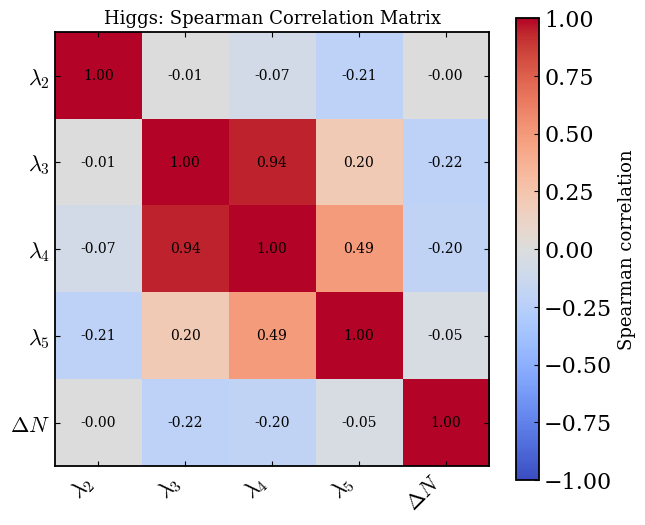

In [213]:
corr_higgs = plot_hierarchy_correlation_matrix(
    spectral_results["higgs"]["models"],
    model_tag="higgs",
    method="spearman",
)

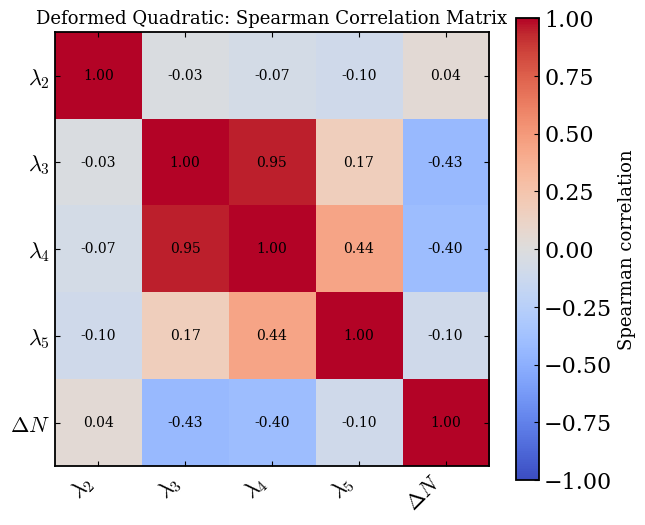

In [214]:
corr_quad = plot_hierarchy_correlation_matrix(
    spectral_results["nonhiggs"]["models"],
    model_tag="nonhiggs",
    method="spearman",
)

Is it the case truly given these numbers that the inflationary duration is more sensitive to changes in the higher order hierarchy for the deformed quadratic model? Is it the case from what we see that for the quad model, perturbations in $\lambda_3$ propogate more efficiently into the background.

$\lambda_3 \rightarrow \lambda_2 \rightarrow \sigma \rightarrow \epsilon$ and where $\epsilon$ ends determines $\Delta N$

Also note and remember, that $r$ for the deformed quadratic is larger than the Higgs model.

## Heatmaps!

In [215]:
from scipy.stats import binned_statistic_2d

def plot_hierarchy_heatmap(
    model_df,
    model_tag,
    x_param,
    y_param,
    value_column,
    bins=15,
    statistic="median",
    cmap="viridis",
    show_counts=False,
    save_name=None,
):

    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)

    df = model_df[
        [x_param, y_param, value_column]
    ].dropna()

    x = df[x_param].values
    y = df[y_param].values
    z = df[value_column].values

    stat, x_edges, y_edges, binnumber = binned_statistic_2d(
        x,
        y,
        z,
        statistic=statistic,
        bins=bins,
    )

    counts, _, _, _ = binned_statistic_2d(
        x,
        y,
        z,
        statistic="count",
        bins=bins,
    )

    fig, ax = plt.subplots(
        figsize=(7,6)
    )

    im = ax.pcolormesh(
        x_edges,
        y_edges,
        stat.T,
        shading="auto",
        cmap=cmap,
    )

    cbar = plt.colorbar(
        im,
        ax=ax,
    )

    cbar.set_label(
        f"{statistic.capitalize()} {value_column}"
    )

    if show_counts:

        xc = 0.5*(x_edges[:-1] + x_edges[1:])
        yc = 0.5*(y_edges[:-1] + y_edges[1:])

        for i in range(len(xc)):
            for j in range(len(yc)):

                if counts[i,j] > 0:

                    ax.text(
                        xc[i],
                        yc[j],
                        int(counts[i,j]),
                        ha="center",
                        va="center",
                        fontsize=7,
                        color="white",
                    )

    pretty = {
        "lam2":r"$\lambda_2$",
        "lam3":r"$\lambda_3$",
        "lam4":r"$\lambda_4$",
        "lam5":r"$\lambda_5$",
    }

    ax.set_xlabel(pretty.get(x_param,x_param))
    ax.set_ylabel(pretty.get(y_param,y_param))

    ax.set_title(
        f"{model_label}\n"
        f"{statistic.capitalize()} {value_column}"
    )

    if save_name is None:
        save_name = (
            f"{model_tag}_{value_column}_"
            f"{x_param}_{y_param}.pdf"
        )

    plt.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    return stat

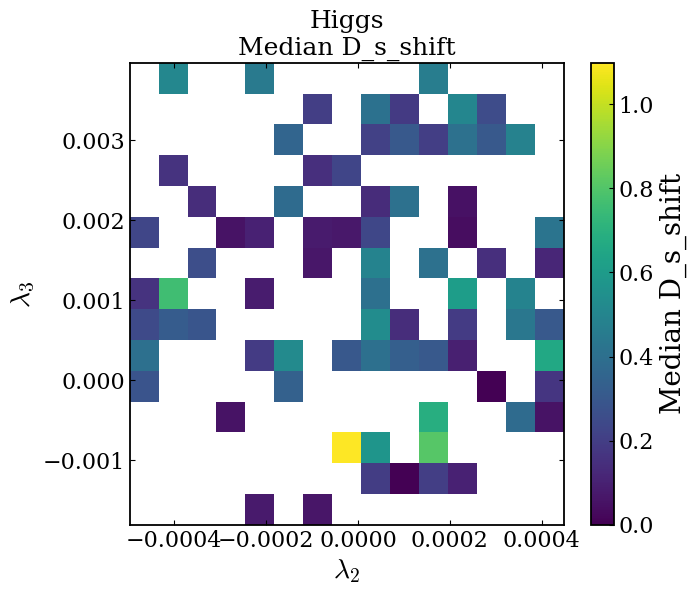

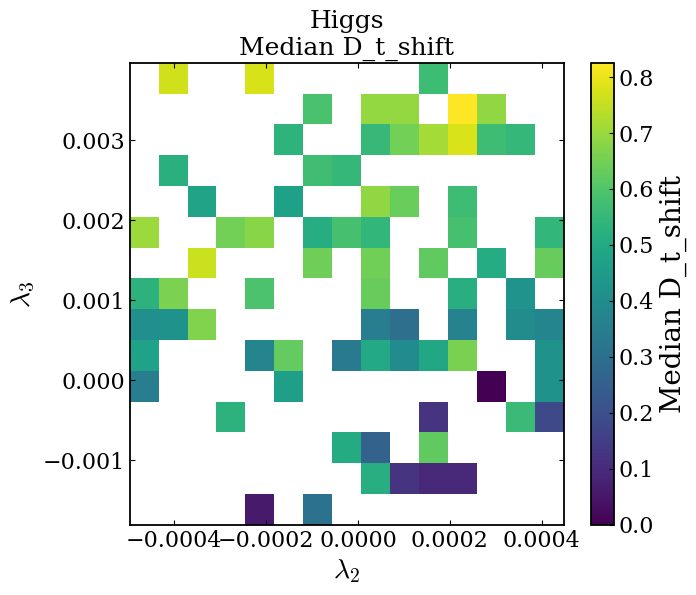

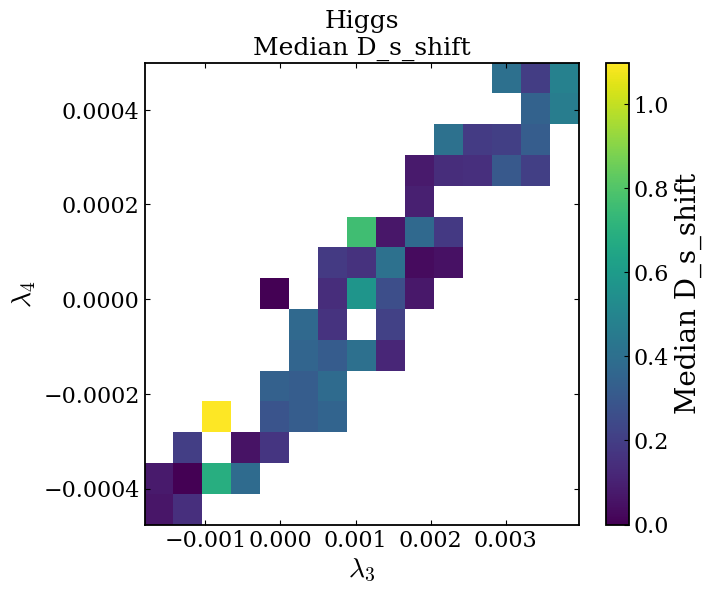

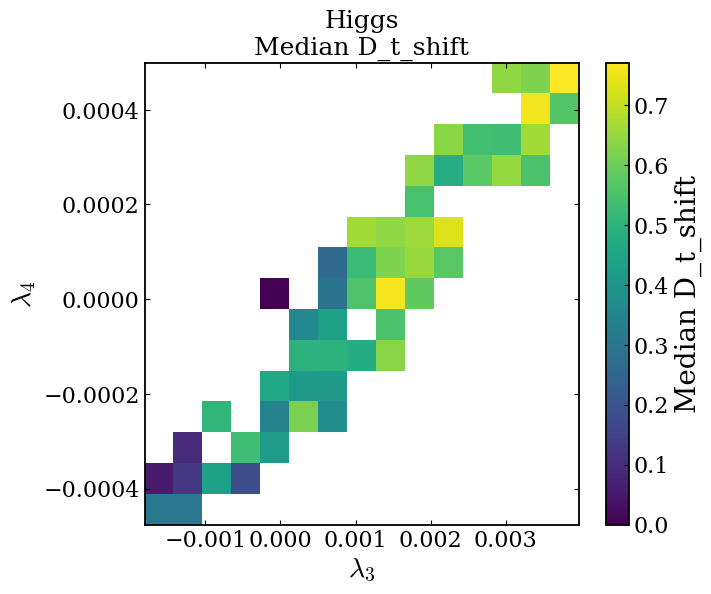

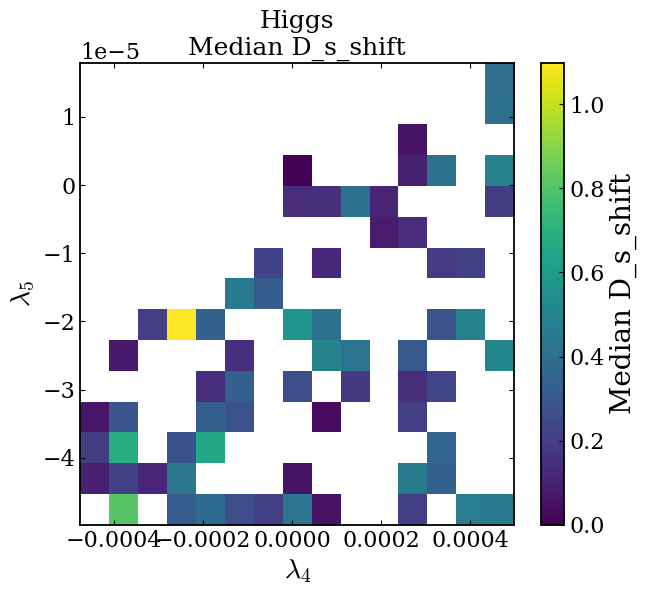

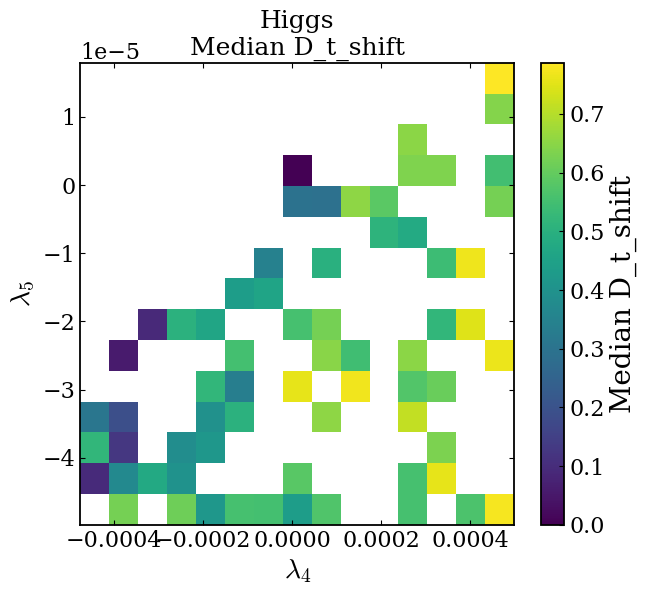

array([[       nan, 0.09320012, 0.51769182, 0.30845871,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [0.62338763, 0.36986502, 0.12432674, 0.19016785,        nan,
        0.05631918,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan, 0.47617355,        nan,        nan,        nan,
               nan, 0.09046628,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [0.61476233, 0.39856597, 0.38216647,        nan,        nan,
               nan, 0.5035379 ,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [0.41558005,        nan, 0.41785319, 0.39429135, 0.51776133,
               nan, 0.46262524,        nan,        nan,        nan,
               nan,        nan,        nan, 

In [216]:
plot_hierarchy_heatmap(
    spectral_results["higgs"]["models"],
    model_tag="higgs",
    x_param="lam2",
    y_param="lam3",
    value_column="D_s_shift",
    bins=15,
)


plot_hierarchy_heatmap(
    spectral_results["higgs"]["models"],
    model_tag="higgs",
    x_param="lam2",
    y_param="lam3",
    value_column="D_t_shift",
    bins=15,
)


plot_hierarchy_heatmap(
    spectral_results["higgs"]["models"],
    model_tag="higgs",
    x_param="lam3",
    y_param="lam4",
    value_column="D_s_shift",
    bins=15,
)

plot_hierarchy_heatmap(
    spectral_results["higgs"]["models"],
    model_tag="higgs",
    x_param="lam3",
    y_param="lam4",
    value_column="D_t_shift",
    bins=15,
)

plot_hierarchy_heatmap(
    spectral_results["higgs"]["models"],
    model_tag="higgs",
    x_param="lam4",
    y_param="lam5",
    value_column="D_s_shift",
    bins=15,
)

plot_hierarchy_heatmap(
    spectral_results["higgs"]["models"],
    model_tag="higgs",
    x_param="lam4",
    y_param="lam5",
    value_column="D_t_shift",
    bins=15,
)

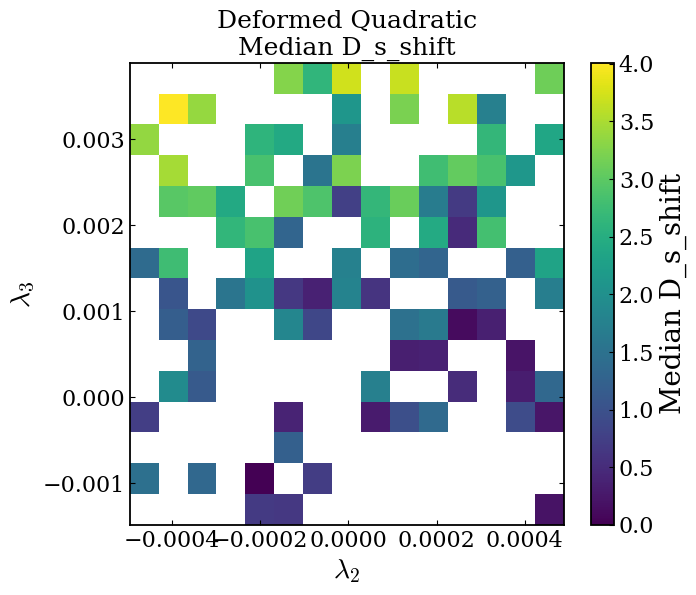

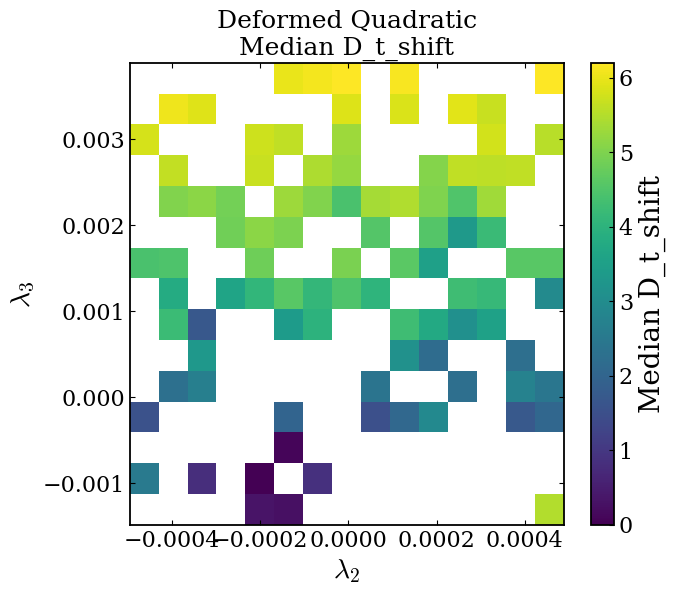

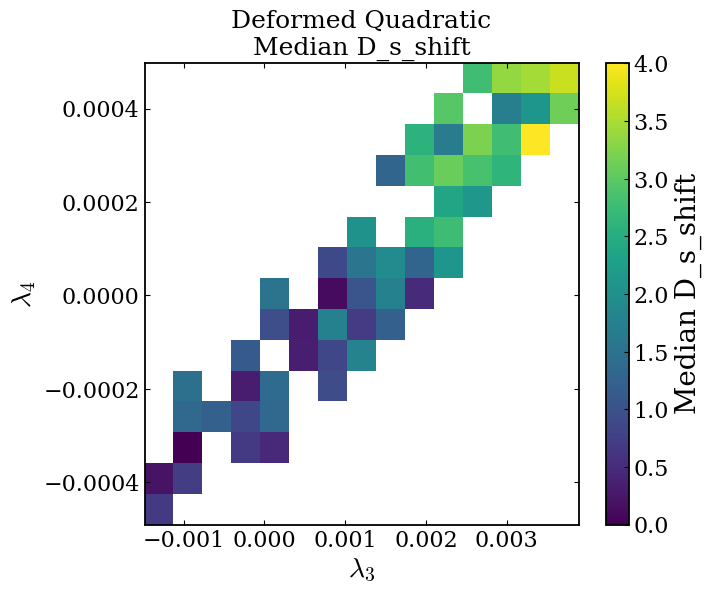

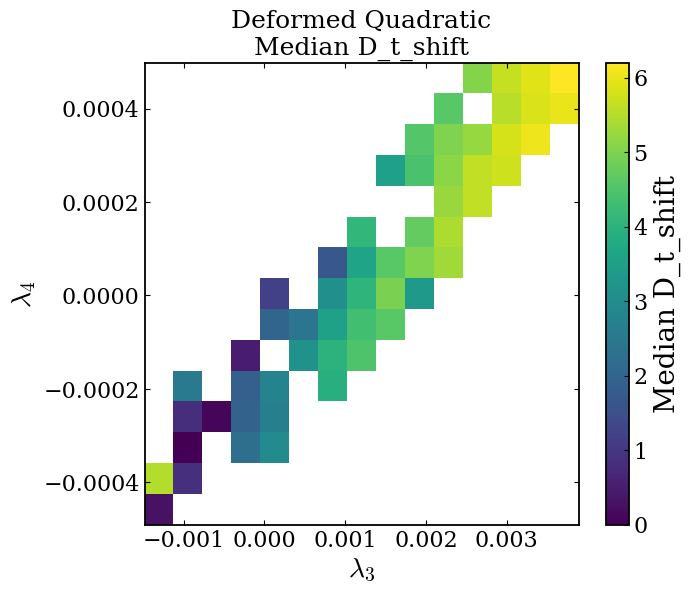

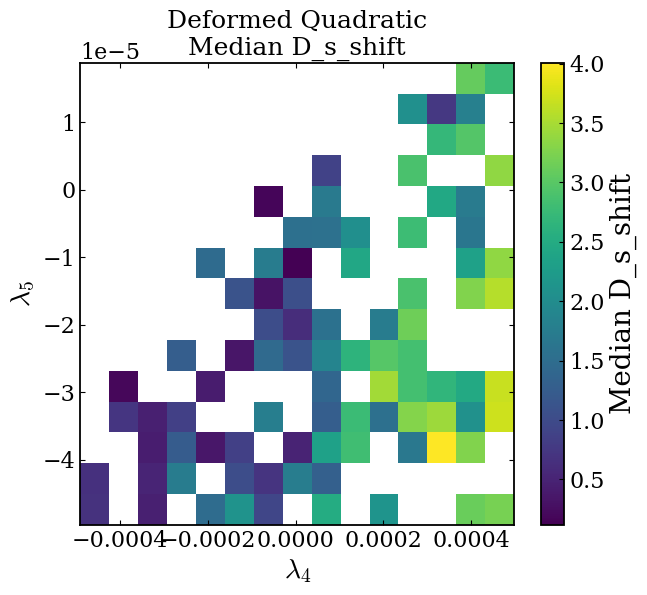

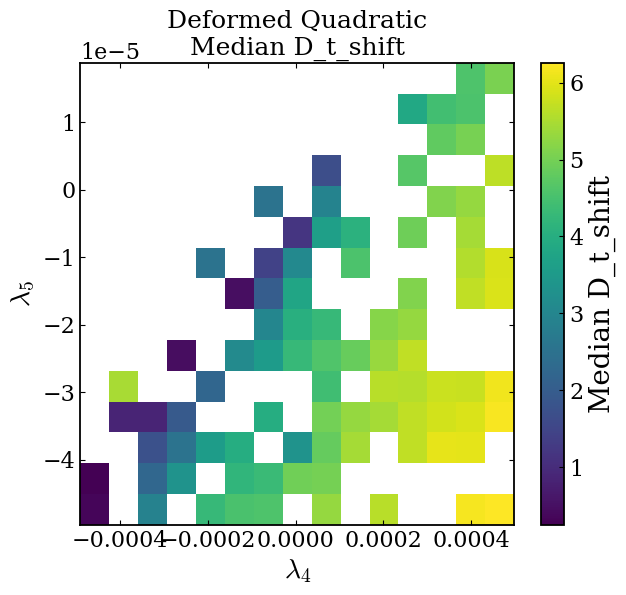

array([[0.3273826 , 0.25081404,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan, 0.84893153, 5.47901867,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [2.91230483, 2.23611717, 1.73717109, 0.85778774,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan, 3.34763371, 2.54085159, 1.93348625,        nan,
        0.45298486,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [4.28045517,        nan, 3.55676191,        nan, 2.21311607,
               nan,        nan,        nan, 2.52795206,        nan,
               nan,        nan,        nan, 

In [218]:
plot_hierarchy_heatmap(
    spectral_results["nonhiggs"]["models"],
    model_tag="nonhiggs",
    x_param="lam2",
    y_param="lam3",
    value_column="D_s_shift",
    bins=15,
)

plot_hierarchy_heatmap(
    spectral_results["nonhiggs"]["models"],
    model_tag="nonhiggs",
    x_param="lam2",
    y_param="lam3",
    value_column="D_t_shift",
    bins=15,
)


plot_hierarchy_heatmap(
    spectral_results["nonhiggs"]["models"],
    model_tag="nonhiggs",
    x_param="lam3",
    y_param="lam4",
    value_column="D_s_shift",
    bins=15,
)

plot_hierarchy_heatmap(
    spectral_results["nonhiggs"]["models"],
    model_tag="nonhiggs",
    x_param="lam3",
    y_param="lam4",
    value_column="D_t_shift",
    bins=15,
)

plot_hierarchy_heatmap(
    spectral_results["nonhiggs"]["models"],
    model_tag="nonhiggs",
    x_param="lam4",
    y_param="lam5",
    value_column="D_s_shift",
    bins=15,
)

plot_hierarchy_heatmap(
    spectral_results["nonhiggs"]["models"],
    model_tag="nonhiggs",
    x_param="lam4",
    y_param="lam5",
    value_column="D_t_shift",
    bins=15,
)



So, is the tensor power spectrum more sensitive to lower order parameters?? I mean I guess higher order param CAN influcence $\epsilon$ . Need to see more.

I know my higher order parameters matter cause they control how the trajectory evolves away from the CMB pivot. I wanna know which higher order param control the extrapolation from the observed CMB region into small scale spectrum. I have to ask:

- Are the models I am looking at in the same family. DeltaN is besr for helping me test this piece since a small DeltaN range means models are not aggressively different. But that DeltaN may mean different ranges for different models?? DeltaN is a family diagnostic.
- How much of the spectral variation is scale misalignment? For higgs and quad, after shifting the spectral variation goes down. But it goes down more for higgs than quad. Why? Likely because higgs is not as impact by higher order param in the same way as quad. Quad has more variation, and more input from higher order param to adjust its shape. The quad case has currently more variation epsilon and thus spectral shape relative to base.
- Which hierarchy param drive the remaining shape variation? Currently it seems that lam3-lam4 drive the sensitivity. lam5 shows little correlation with Ds and Dt. 

In this project CMB fixes local state near the pivot (using r, sigma, etc). Higher order controls continuation away from the pivot. Two models even in the same family can differ far from pivot point. Our next pivot point in the study would be LISA scale. Then PTA. We wanna know what control is happening as we move to these diff scales.

In this case a good multiwavelength model (one that creates a credible band around multi scale spectra):
- Needs to pass CMB consistency
- Must have controlled fam membership with deltaN
- Stable spectrum (gets chosen inside spectrum.py where we set Y=10, 50, etc)
- Hierarchy convergence. Additional parameters are changing where inflation ends for one model basically.
- Physical reasonability ~ so background remains reasonable throughout all scales of interest
- Robustness of the spectra (If I know only the CMB observables and allow reasonable higher-order freedom,what is the predicted range of spectra? This is my enveloples I think. it samples uncertainty in the hierarchy)


The project can be framed like so:
We use Hubble-flow Monte Carlo reconstruction to generate inflationary trajectories consistent with Higgs-like CMB observables. We then track how uncertainty in the higher-order slow-roll hierarchy propagates through the background evolution and into scalar and tensor spectra across CMB, PTA, and LISA scales. A deformed quadratic fiducial is used to test whether the resulting sensitivity is specific to the Higgs-like trajectory or generic to the reconstruction procedure.

The lower higher-order parameters, especially $\lambda_3$ and $\lambda_4$ dominate the residual spectral variation after correcting for differences in inflationary duration. Higgs-like scalar spectra are relatively robust near the CMB window, while tensor predictions remain more sensitive to these parameters. The deformed quadratic exhibits stronger hierarchy-dependent variation in both sectors.

Basically, CMB priors define starting region, deltaN and background test identify coherent families, lam3 and lam4 govern extrapolation, and multiband spectra reveal which allowed models remain distingishable. 

I can think of current phase like here is the family of Higgs spectra allowed by present CMB observations and how we wanna know how uncertainty in the higher-order slow-roll hierarchy propagates into predictions for future detectors such as LISA and PTAs.

As we think to future LISA/PTA scales we can consider:
If every accepted model continues to predict almost identical PTA and LISA spectra,the CMB tightly determines inflation over many decades in scale.If instead the models fan out dramatically,the CMB only determines inflation locally, and higher-order freedom produces substantial uncertainty in small-scale predictions.

## Analyzing relationship by Scale

There are three scales we are interested in looking at. CMB which is around the local pivot, then we also want to examine LISA scales roughly around 23-33 e-folds and PTA scales which are likely around 42-44 e-folds. 

So, now I am going to separate these relationships up into proper scales. 

CMB e-folds would be N=60 (k=0.05 $hMpc^{-1}$) down to let's say: 

    7.791356504680627E-06
    3.227714339430105E-05
    1.337140695680410E-04
    5.539354019663254E-04
    2.294780426194834E-03
    9.506554709726014E-03
    3.938267095944833E-02
    5.000000000000000E-02
    1.631500390265865E-01



For PTA we can do from:

    5.863073216544149E+04
    2.428887124186838E+05
    1.006211664796150E+06
    4.168418961464933E+06
    1.726845081031781E+07
    7.153776915062489E+07


And LISA can range from:

    2.106994748371197E+10
    8.728617614065150E+10
    3.615992185622029E+11
    1.497992014842074E+12
    6.205710525186335E+12
    2.570831001824030E+13
    1.065014556047326E+14
    4.412020874915222E+14
    1.827761704303192E+15
    7.571842795919458E+15
    3.136776702955088E+16
    


In [233]:
K_BANDS = {
    "CMB": {
        "k_min": 7.791356504680627e-06,
        "k_max": 1.631500390265865e-01,
        "N_range": (60, None),
    },

    "PTA": {
        "k_min": 5.863073216544149e04,
        "k_max": 7.153776915062489e07,
        "N_range": (42, 44),
    },

    "LISA": {
        "k_min": 2.106994748371197e10,
        "k_max": 3.136776702955088e16,
        "N_range": (23, 33),
    },
}

Calculate the fraction error curves over that mask!

In [234]:
def summarize_fractional_difference_in_band(
    k,
    frac,
    k_min,
    k_max,
):
    """
    Summarize one fractional-difference curve within a k-band.

    frac is assumed to be fractional, not percent.
    """
    k = np.asarray(k, dtype=float)
    frac = np.asarray(frac, dtype=float)

    mask = (
        np.isfinite(k)
        & np.isfinite(frac)
        & (k >= k_min)
        & (k <= k_max)
    )

    if np.count_nonzero(mask) == 0:
        return {
            "n_k": 0,
            "median_abs_pct": np.nan,
            "p68_abs_pct": np.nan,
            "p95_abs_pct": np.nan,
            "max_abs_pct": np.nan,
            "signed_mean_pct": np.nan,
        }

    frac_pct = 100.0 * frac[mask]
    abs_frac_pct = np.abs(frac_pct)

    return {
        "n_k": np.count_nonzero(mask),
        "median_abs_pct": np.nanmedian(abs_frac_pct),
        "p68_abs_pct": np.nanpercentile(abs_frac_pct, 68),
        "p95_abs_pct": np.nanpercentile(abs_frac_pct, 95),
        "max_abs_pct": np.nanmax(abs_frac_pct),
        "signed_mean_pct": np.nanmean(frac_pct),
    }

In [237]:
## Define fractional error bands uses above function

def build_tensor_band_metrics(
    NEQS,
    lamX_values,
    ref_value,
    base_path_root,
    model_tag,
    k_norm=0.05,
    ns_min=0.96,
    ns_max=0.97,
    r_min=None,
    r_max=None,
    max_abs_alpha_s=0.005,
):
    """
    Calculate shifted tensor-spectrum distances in the
    CMB, PTA, and LISA k-bands for every accepted model.
    """

    param_name, _ = SCAN_INFO[NEQS]

    summary_df = load_batch_summaries(
        NEQS=NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ).copy()

    def sanitize_values(values):
        return np.array(
            [
                item[0] if isinstance(item, tuple) else item
                for item in values
            ],
            dtype=float,
        )

    def get_summary_row(value):
        matches = summary_df.loc[
            np.isclose(
                summary_df[param_name].to_numpy(dtype=float),
                value,
                rtol=1e-8,
                atol=max(1e-15, abs(value) * 1e-8),
            )
        ]

        if matches.empty:
            raise FileNotFoundError(
                f"No summary row for "
                f"{param_name}={value:.10e}, "
                f"model={model_tag}"
            )

        return matches.iloc[0]

    def load_tensor_spectrum(value):
        folder = folder_for(
            NEQS=NEQS,
            param_name=param_name,
            value=value,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )

        tensor_file = os.path.join(
            str(folder),
            f"spec_t_neqs{NEQS}.dat",
        )

        if not os.path.exists(tensor_file):
            raise FileNotFoundError(
                f"Missing tensor spectrum: {tensor_file}"
            )

        data = np.loadtxt(tensor_file)

        k, Pt = prepare_increasing(
            data[:, 0],
            np.abs(data[:, 1]),
        )

        return k, Pt

    def normalize_spectrum(k, P):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_norm <= k.max()):
            raise ValueError(
                f"k_norm={k_norm} outside "
                f"[{k.min():.3e}, {k.max():.3e}]"
            )

        P_norm = np.interp(
            k_norm,
            k,
            P,
        )

        if not np.isfinite(P_norm) or abs(P_norm) < 1e-30:
            raise ValueError(
                f"Invalid tensor normalization at k={k_norm}"
            )

        return k, P / P_norm

    def fractional_difference_on_reference_grid(
        k_ref,
        P_ref,
        k_model,
        P_model,
    ):
        k_ref, P_ref = prepare_increasing(
            k_ref,
            P_ref,
        )

        k_model, P_model = prepare_increasing(
            k_model,
            P_model,
        )

        k_min = max(
            k_ref.min(),
            k_model.min(),
        )

        k_max = min(
            k_ref.max(),
            k_model.max(),
        )

        if k_min >= k_max:
            return np.array([]), np.array([])

        mask = (
            (k_ref >= k_min)
            & (k_ref <= k_max)
        )

        k_use = k_ref[mask]

        if len(k_use) == 0:
            return np.array([]), np.array([])

        P_ref_use = P_ref[mask]

        P_model_interp = np.interp(
            k_use,
            k_model,
            P_model,
        )

        frac = (
            P_model_interp - P_ref_use
        ) / P_ref_use

        return k_use, frac

    # --------------------------------------------------
    # Reference model
    # --------------------------------------------------

    ref_row = get_summary_row(ref_value)

    ref_N_end = float(
        ref_row["original_N_end"]
    )

    k_t_ref_raw, Pt_ref_raw = load_tensor_spectrum(
        ref_value
    )

    k_t_ref, Pt_ref_norm = normalize_spectrum(
        k_t_ref_raw,
        Pt_ref_raw,
    )

    # --------------------------------------------------
    # Loop over models
    # --------------------------------------------------

    rows = []

    for value in sanitize_values(lamX_values):
        try:
            summary_row = get_summary_row(value)

            ns = float(summary_row["n_s"])
            r = float(summary_row["r"])
            alpha_s = float(summary_row["alpha_s"])

            if not (ns_min <= ns <= ns_max):
                continue

            if r_min is not None and r < r_min:
                continue

            if r_max is not None and r > r_max:
                continue

            if (
                max_abs_alpha_s is not None
                and abs(alpha_s) > max_abs_alpha_s
            ):
                continue

            model_N_end = float(
                summary_row["original_N_end"]
            )

            deltaN = model_N_end - ref_N_end

            # Load raw model tensor spectrum.
            k_t_raw, Pt_raw = load_tensor_spectrum(
                value
            )

            # Apply your physical k-shift.
            k_t_shifted = (
                k_t_raw * np.exp(-deltaN)
            )

            # Renormalize shifted spectrum at k_norm.
            k_t_sh, Pt_sh = normalize_spectrum(
                k_t_shifted,
                Pt_raw,
            )

            # Compare shifted model against reference.
            k_pt_sh, frac_pt_sh = (
                fractional_difference_on_reference_grid(
                    k_ref=k_t_ref,
                    P_ref=Pt_ref_norm,
                    k_model=k_t_sh,
                    P_model=Pt_sh,
                )
            )

            if len(k_pt_sh) == 0:
                print(
                    f"Skipping {model_tag}, "
                    f"{param_name}={value:.5e}: "
                    "no overlapping shifted tensor k-range"
                )
                continue

            row = {
                "model_tag": model_tag,
                "NEQS": NEQS,
                "param_name": param_name,
                "value": value,

                "lam2": float(summary_row["lam2"]),
                "lam3": float(summary_row["lam3"]),
                "lam4": float(summary_row["lam4"]),
                "lam5": float(summary_row["lam5"]),

                "n_s": ns,
                "r": r,
                "alpha_s": alpha_s,

                "original_N_end": model_N_end,
                "deltaN_from_ref_base": deltaN,
                "abs_deltaN_from_ref_base": abs(deltaN),
            }

            # ------------------------------------------
            # Summarize each observational band
            # ------------------------------------------

            for band_name, band in K_BANDS.items():
                metrics = (
                    summarize_fractional_difference_in_band(
                        k=k_pt_sh,
                        frac=frac_pt_sh,
                        k_min=band["k_min"],
                        k_max=band["k_max"],
                    )
                )

                row[
                    f"D_t_{band_name}_median"
                ] = metrics["median_abs_pct"]

                row[
                    f"D_t_{band_name}_p68"
                ] = metrics["p68_abs_pct"]

                row[
                    f"D_t_{band_name}_p95"
                ] = metrics["p95_abs_pct"]

                row[
                    f"D_t_{band_name}_max"
                ] = metrics["max_abs_pct"]

                row[
                    f"D_t_{band_name}_signed_mean"
                ] = metrics["signed_mean_pct"]

                row[
                    f"n_k_{band_name}"
                ] = metrics["n_k"]

            rows.append(row)

        except (FileNotFoundError, ValueError) as exc:
            print(
                f"Skipping {model_tag}, "
                f"{param_name}={value:.5e}: {exc}"
            )

    result_df = pd.DataFrame(rows)

    print(
        f"{model_tag}: saved tensor-band metrics "
        f"for {len(result_df)} models"
    )

    return result_df

For Higgs:

In [239]:
tensor_band_results = {}

tensor_band_results["higgs"] = build_tensor_band_metrics(
    NEQS=8,
    lamX_values=param_values_by_model["higgs"][8],
    ref_value=-8.92461e-9,
    base_path_root=base_path_root,
    model_tag="higgs",

    ns_min=0.96,
    ns_max=0.97,

    r_min=2.737e-3 - 0.001,
    r_max=2.737e-3 + 0.001,

    max_abs_alpha_s=0.005,
)

tensor_band_results["higgs"][
    [
        "lam2",
        "lam3",
        "lam4",
        "lam5",
        "D_t_CMB_median",
        "D_t_PTA_median",
        "D_t_LISA_median",
        "n_k_CMB",
        "n_k_PTA",
        "n_k_LISA",
    ]
].head()

#n_k are number of tensor spectrum points contributing to the CMB distance

#Within the CMB scales, this model's tensor spectrum differs from the reference by a typical amount of 0.0026%.




Skipping higgs, lam5=-4.07624e-05: k_norm=0.05 outside [8.260e-02, 9.794e+22]
Skipping higgs, lam5=-3.66361e-05: k_norm=0.05 outside [5.602e-02, 6.642e+22]
Skipping higgs, lam5=-3.56985e-05: k_norm=0.05 outside [2.975e-01, 3.528e+23]
Skipping higgs, lam5=-3.13717e-05: k_norm=0.05 outside [1.062e-01, 1.259e+23]
Skipping higgs, lam5=-2.79589e-05: k_norm=0.05 outside [5.594e-01, 6.633e+23]
Skipping higgs, lam5=-2.75059e-05: k_norm=0.05 outside [1.020e-01, 1.209e+23]
Skipping higgs, lam5=-2.57986e-05: k_norm=0.05 outside [8.281e-02, 9.819e+22]
Skipping higgs, lam5=-2.34737e-05: k_norm=0.05 outside [6.512e-02, 7.722e+22]
Skipping higgs, lam5=-2.28287e-05: k_norm=0.05 outside [5.024e-02, 5.957e+22]
Skipping higgs, lam5=-1.62767e-05: k_norm=0.05 outside [8.194e-02, 9.717e+22]
Skipping higgs, lam5=-1.40324e-05: k_norm=0.05 outside [5.165e-01, 6.125e+23]
Skipping higgs, lam5=-1.39168e-05: k_norm=0.05 outside [2.020e-01, 2.395e+23]
Skipping higgs, lam5=-9.19430e-06: k_norm=0.05 outside [1.765e-0

,lam2,lam3,lam4,lam5,D_t_CMB_median,D_t_PTA_median,D_t_LISA_median,n_k_CMB,n_k_PTA,n_k_LISA
0,0.000338,0.001231,-0.000126,-0.000050,0.002586,0.275300,2.357428,5,6,11
1,-0.000195,0.003970,0.000437,-0.000049,0.010592,0.662729,2.834771,4,6,11
2,-0.000103,0.003268,0.000283,-0.000049,0.001432,0.444850,2.589071,3,6,11
3,0.000326,0.001226,-0.000120,-0.000048,0.004077,0.374760,2.472138,3,6,11
4,0.000243,0.002204,0.000062,-0.000048,0.002832,0.463458,2.594530,3,6,11


For Quad:

In [240]:
tensor_band_results["nonhiggs"] = build_tensor_band_metrics(
    NEQS=8,
    lamX_values=param_values_by_model["nonhiggs"][8],
    ref_value=-3.3792701497e-5,
    base_path_root=base_path_root,
    model_tag="nonhiggs",

    ns_min=0.96,
    ns_max=0.97,

    r_min=3.2958886892e-2 - 0.001,
    r_max=3.2958886892e-2 + 0.001,

    max_abs_alpha_s=0.005,
)

tensor_band_results["nonhiggs"][
    [
        "lam2",
        "lam3",
        "lam4",
        "lam5",
        "D_t_CMB_median",
        "D_t_PTA_median",
        "D_t_LISA_median",
        "n_k_CMB",
        "n_k_PTA",
        "n_k_LISA",
    ]
].head()

nonhiggs: saved tensor-band metrics for 120 models


,lam2,lam3,lam4,lam5,D_t_CMB_median,D_t_PTA_median,D_t_LISA_median,n_k_CMB,n_k_PTA,n_k_LISA
0,0.000305,0.002208,0.000067,-0.000050,0.107579,5.036764,6.260273,8,6,11
1,0.000142,0.000864,-0.000173,-0.000049,0.060555,4.047641,5.073833,7,6,11
2,0.000380,0.000127,-0.000301,-0.000049,0.019862,2.755024,3.557221,8,6,11
3,-0.000142,0.001310,-0.000090,-0.000049,0.074225,4.331755,5.431863,8,6,11
4,0.000181,-0.000158,-0.000335,-0.000048,0.059725,2.740578,3.478437,9,6,11


Now, to get the heatmaps in terms of scales:

In [241]:
from scipy.stats import binned_statistic_2d

def plot_tensor_band_heatmaps(
    tensor_band_df,
    model_tag,
    x_param="lam3",
    y_param="lam4",
    statistic="median",
    bins=12,
    min_count=1,
    common_color_scale=True,
    save_name=None,
    show=True,
):
    """
    Plot CMB, PTA, and LISA tensor-distance heatmaps in the
    (x_param, y_param) hierarchy plane.

    Each bin is colored by the chosen statistic of the model-level
    median absolute tensor-spectrum difference in that k-band.
    """

    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)

    band_columns = {
        "CMB": "D_t_CMB_median",
        "PTA": "D_t_PTA_median",
        "LISA": "D_t_LISA_median",
    }

    required_columns = {
        x_param,
        y_param,
        *band_columns.values(),
    }

    missing = required_columns.difference(
        tensor_band_df.columns
    )

    if missing:
        raise ValueError(
            f"Missing required columns: {sorted(missing)}"
        )

    df = tensor_band_df.copy()

    pretty_labels = {
        "lam2": r"$\lambda_2$",
        "lam3": r"$\lambda_3$",
        "lam4": r"$\lambda_4$",
        "lam5": r"$\lambda_5$",
    }

    heatmaps = {}
    counts_by_band = {}

    # --------------------------------------------------
    # Compute all three binned maps first
    # --------------------------------------------------

    for band_name, value_column in band_columns.items():
        use = df[
            [
                x_param,
                y_param,
                value_column,
            ]
        ].replace(
            [np.inf, -np.inf],
            np.nan,
        ).dropna()

        if use.empty:
            heatmaps[band_name] = None
            counts_by_band[band_name] = None
            continue

        x = use[x_param].to_numpy(dtype=float)
        y = use[y_param].to_numpy(dtype=float)
        z = use[value_column].to_numpy(dtype=float)

        stat, x_edges, y_edges, _ = (
            binned_statistic_2d(
                x,
                y,
                z,
                statistic=statistic,
                bins=bins,
            )
        )

        counts, _, _, _ = (
            binned_statistic_2d(
                x,
                y,
                z,
                statistic="count",
                bins=[x_edges, y_edges],
            )
        )

        stat = np.asarray(stat, dtype=float)
        counts = np.asarray(counts, dtype=float)

        stat[counts < min_count] = np.nan

        heatmaps[band_name] = {
            "stat": stat,
            "x_edges": x_edges,
            "y_edges": y_edges,
        }

        counts_by_band[band_name] = counts

    # --------------------------------------------------
    # Shared color range
    # --------------------------------------------------

    finite_values = []

    for band_name in band_columns:
        item = heatmaps[band_name]

        if item is not None:
            values = item["stat"]
            finite_values.extend(
                values[np.isfinite(values)]
            )

    if len(finite_values) == 0:
        raise ValueError(
            f"No finite heatmap values found for {model_label}."
        )

    finite_values = np.asarray(
        finite_values,
        dtype=float,
    )

    if common_color_scale:
        vmin = 0.0
        vmax = np.nanmax(finite_values)
    else:
        vmin = None
        vmax = None

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5.5),
        constrained_layout=True,
    )

    last_im = None

    for ax, band_name in zip(
        axes,
        band_columns,
    ):
        item = heatmaps[band_name]

        if item is None:
            ax.text(
                0.5,
                0.5,
                "No models",
                transform=ax.transAxes,
                ha="center",
                va="center",
            )
            ax.set_title(band_name)
            continue

        local_vmin = vmin
        local_vmax = vmax

        if not common_color_scale:
            local_values = item["stat"]

            local_vmin = 0.0
            local_vmax = np.nanmax(
                local_values
            )

        last_im = ax.pcolormesh(
            item["x_edges"],
            item["y_edges"],
            item["stat"].T,
            shading="auto",
            cmap="viridis",
            vmin=local_vmin,
            vmax=local_vmax,
        )

        ax.set_title(
            rf"{band_name}: median $D_t$"
        )

        ax.set_xlabel(
            pretty_labels.get(
                x_param,
                x_param,
            )
        )

        ax.set_ylabel(
            pretty_labels.get(
                y_param,
                y_param,
            )
        )

        ax.grid(
            False
        )

    if last_im is not None:
        cbar = fig.colorbar(
            last_im,
            ax=axes,
            pad=0.02,
        )

        cbar.set_label(
            r"Median shifted tensor difference [%]"
        )

    fig.suptitle(
        rf"{model_label}: scale-dependent tensor sensitivity",
        fontsize=19,
    )

    if save_name is None:
        save_name = (
            f"{model_tag}_Dt_CMB_PTA_LISA_"
            f"{x_param}_{y_param}_heatmaps.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return heatmaps, counts_by_band

For Higgs:

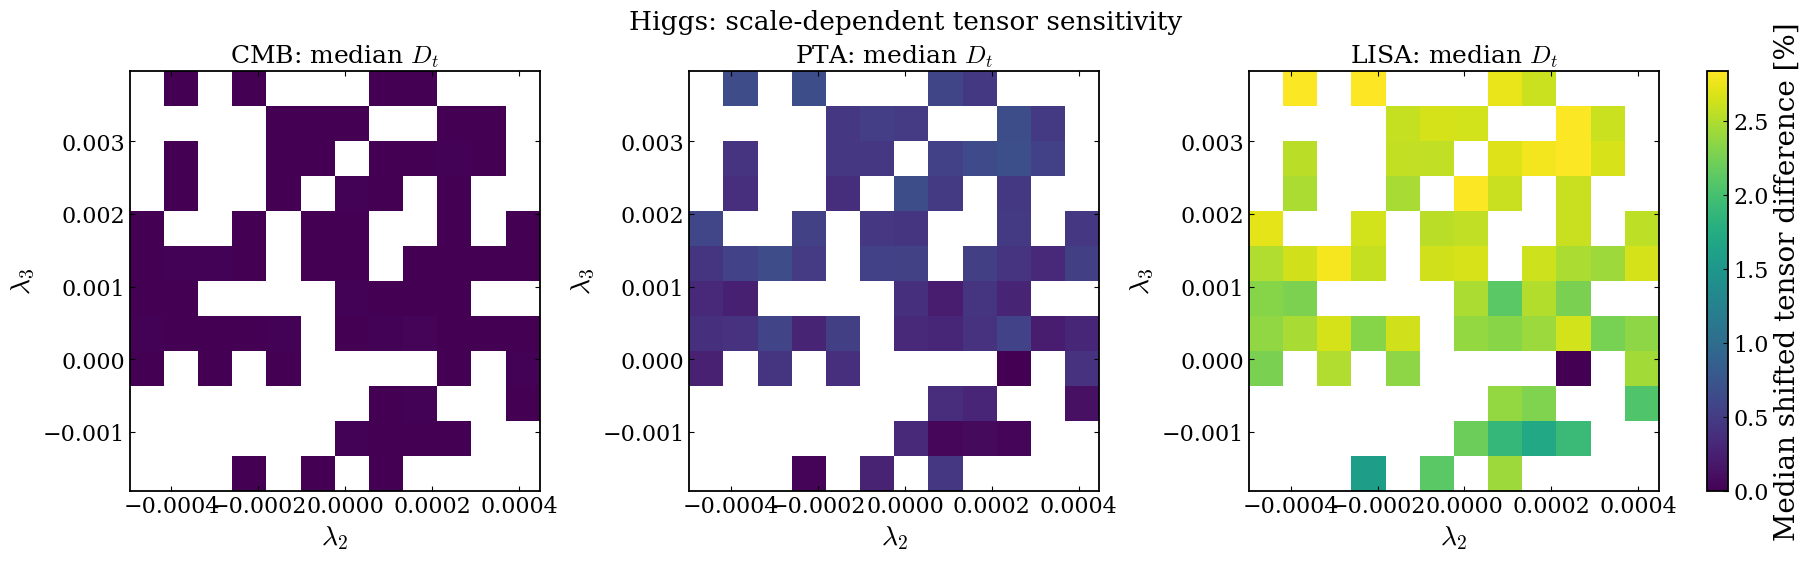

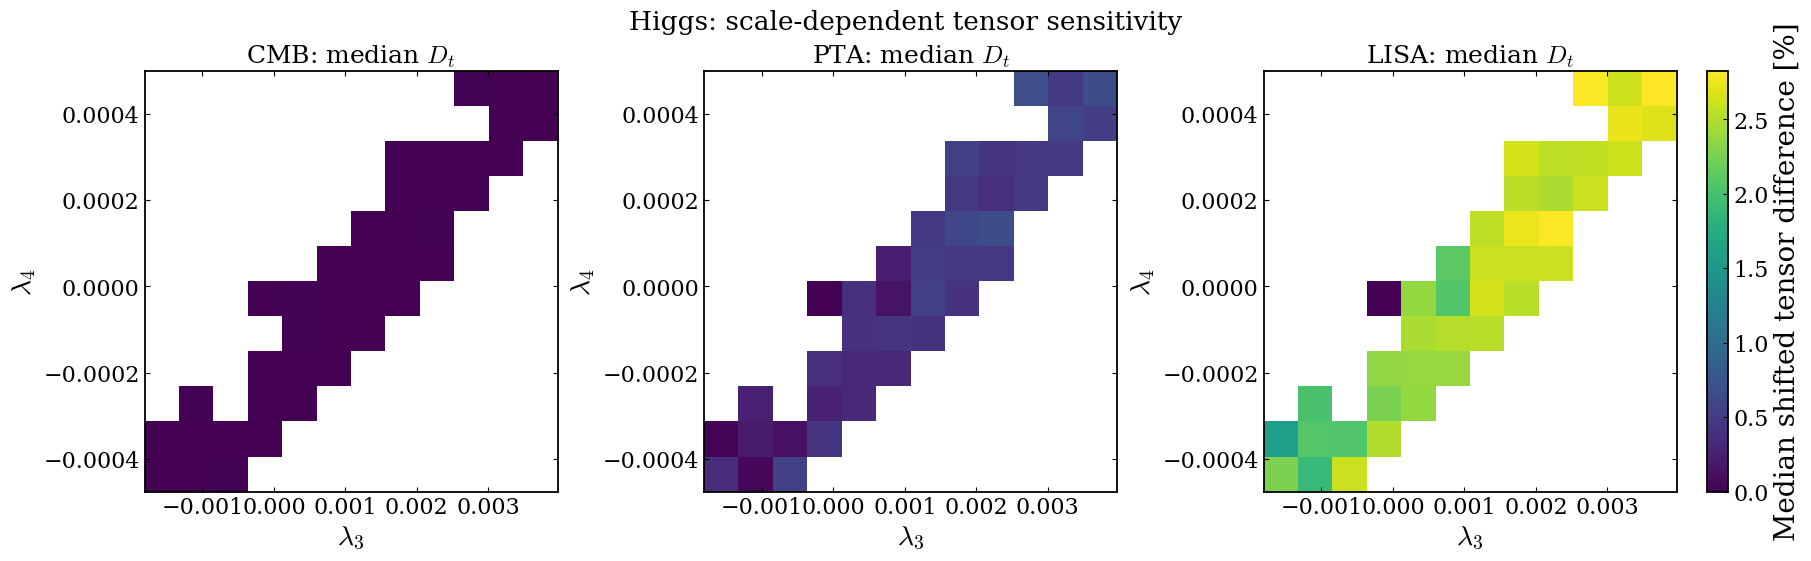

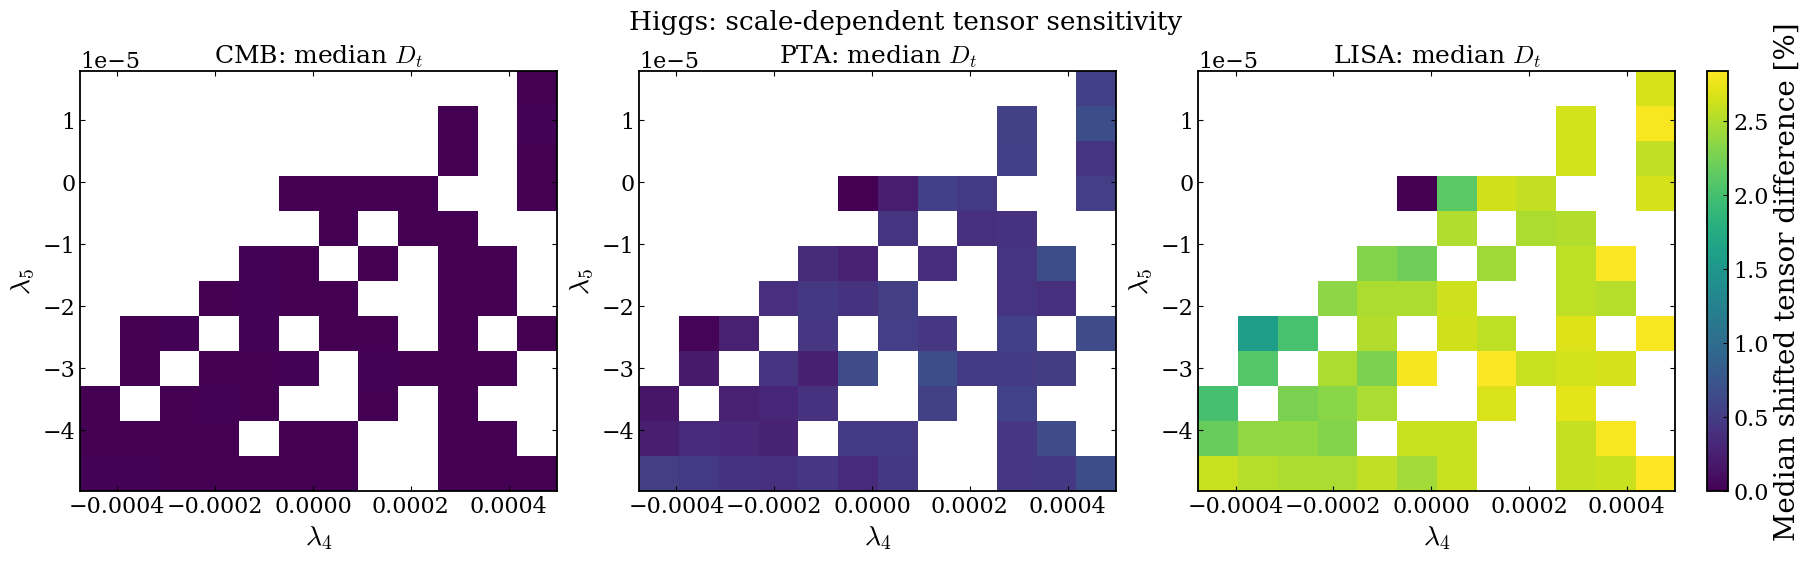

In [242]:
higgs_heatmaps, higgs_counts = (
    plot_tensor_band_heatmaps(
        tensor_band_df=tensor_band_results["higgs"],
        model_tag="higgs",

        x_param="lam2",
        y_param="lam3",

        bins=12,
        min_count=1,

        common_color_scale=True,

        save_name=(
            "paper_higgs_Dt_CMB_PTA_LISA_"
            "lam2_lam3_heatmaps.pdf"
        ),
    )
)





higgs_heatmaps, higgs_counts = (
    plot_tensor_band_heatmaps(
        tensor_band_df=tensor_band_results["higgs"],
        model_tag="higgs",

        x_param="lam3",
        y_param="lam4",

        bins=12,
        min_count=1,

        common_color_scale=True,

        save_name=(
            "paper_higgs_Dt_CMB_PTA_LISA_"
            "lam3_lam4_heatmaps.pdf"
        ),
    )
)


higgs_heatmaps, higgs_counts = (
    plot_tensor_band_heatmaps(
        tensor_band_df=tensor_band_results["higgs"],
        model_tag="higgs",

        x_param="lam4",
        y_param="lam5",

        bins=12,
        min_count=1,

        common_color_scale=True,

        save_name=(
            "paper_higgs_Dt_CMB_PTA_LISA_"
            "lam4_lam5_heatmaps.pdf"
        ),
    )
)

For Quad:

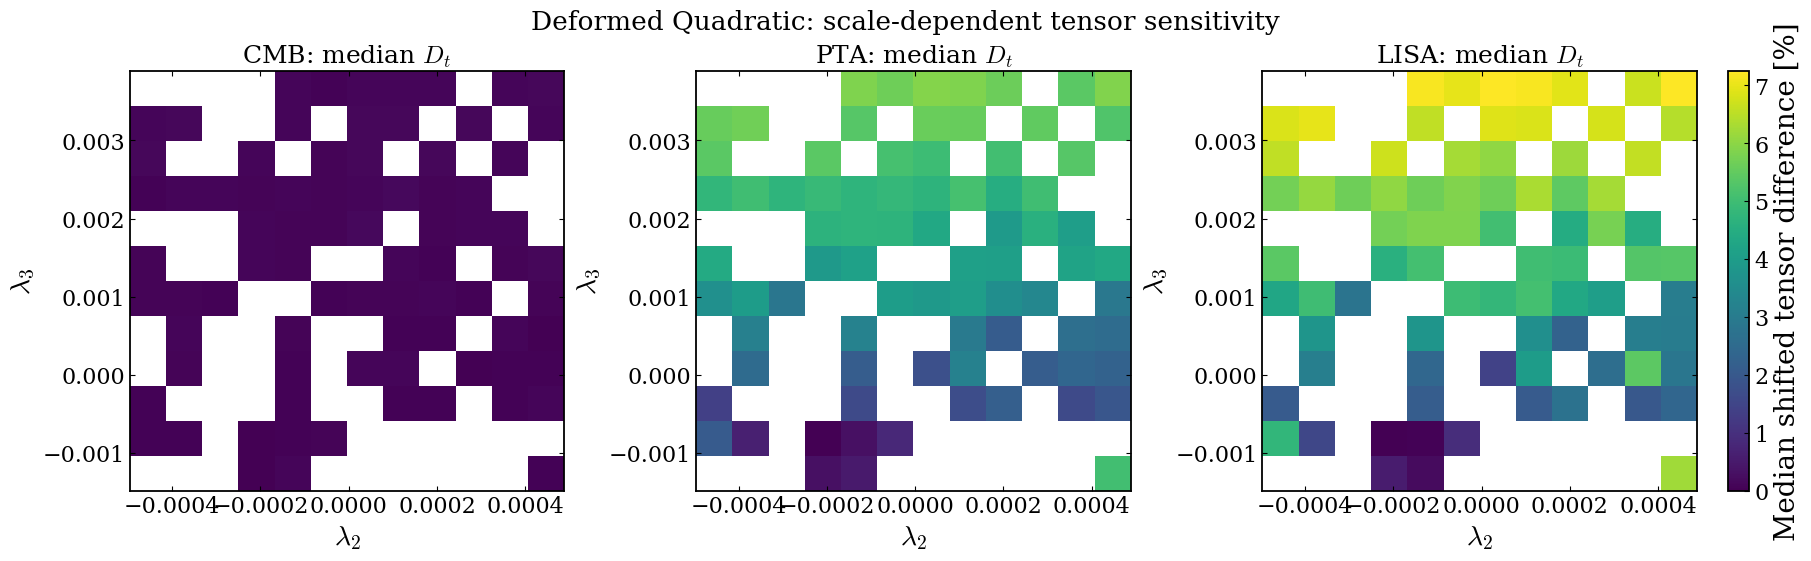

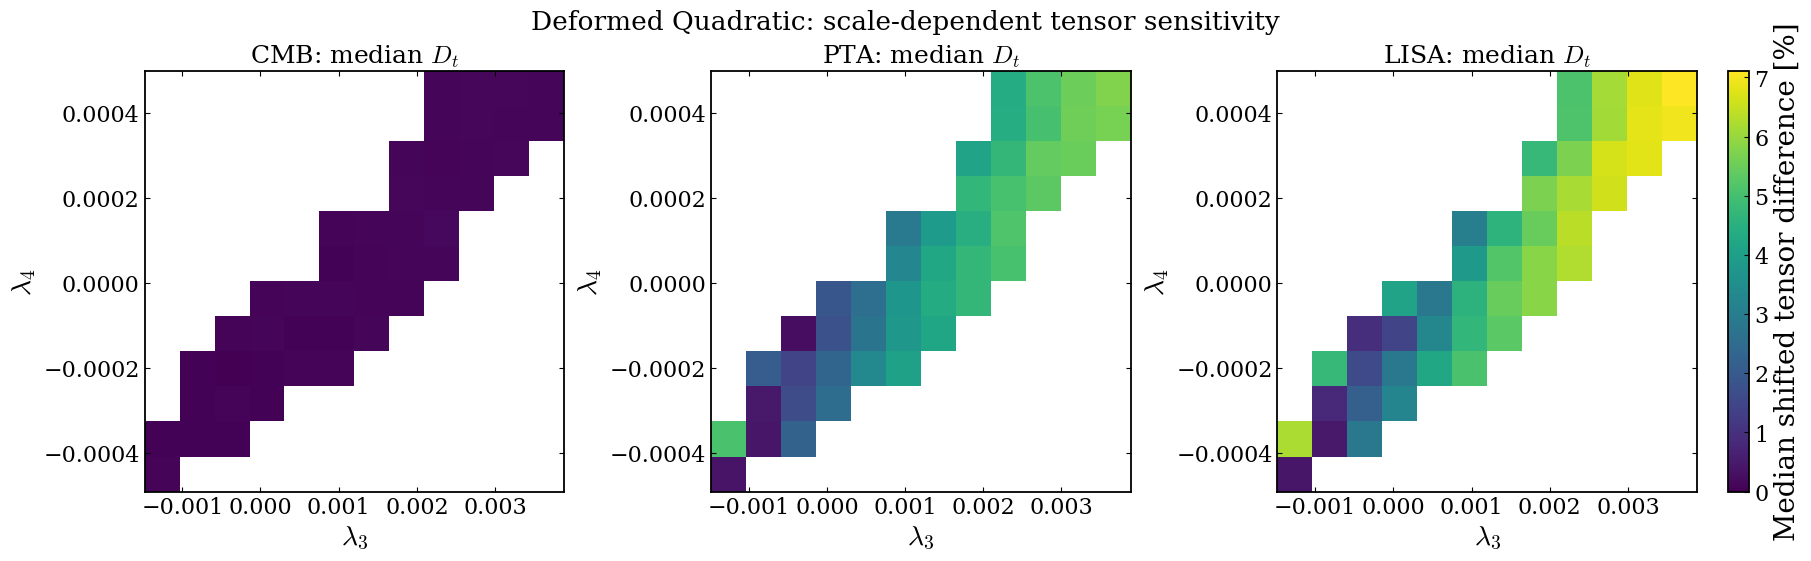

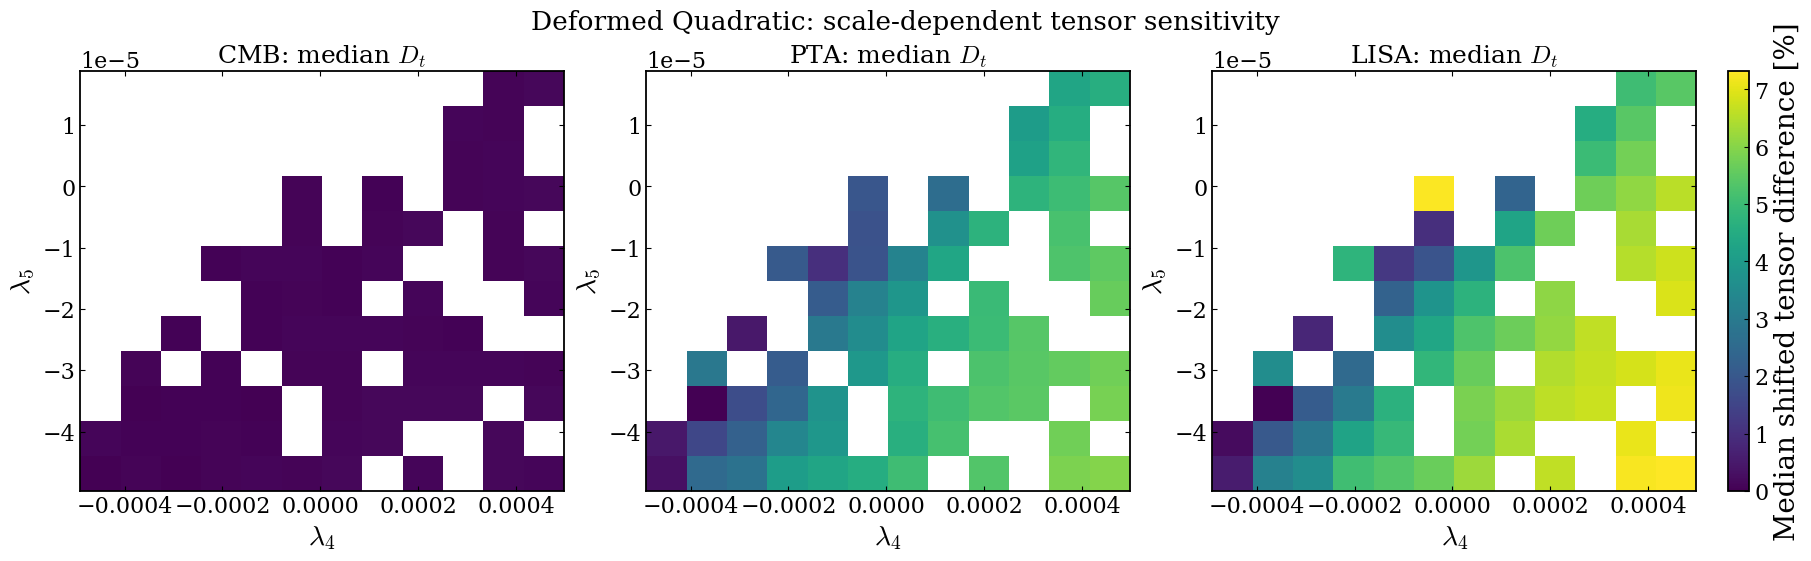

In [244]:
quad_heatmaps, quad_counts = (
    plot_tensor_band_heatmaps(
        tensor_band_df=tensor_band_results["nonhiggs"],
        model_tag="nonhiggs",

        x_param="lam2",
        y_param="lam3",

        bins=12,
        min_count=1,

        common_color_scale=True,

        save_name=(
            "paper_nonhiggs_Dt_CMB_PTA_LISA_"
            "lam2_lam3_heatmaps.pdf"
        ),
    )
)


quad_heatmaps, quad_counts = (
    plot_tensor_band_heatmaps(
        tensor_band_df=tensor_band_results["nonhiggs"],
        model_tag="nonhiggs",

        x_param="lam3",
        y_param="lam4",

        bins=12,
        min_count=1,

        common_color_scale=True,

        save_name=(
            "paper_nonhiggs_Dt_CMB_PTA_LISA_"
            "lam3_lam4_heatmaps.pdf"
        ),
    )
)


quad_heatmaps, quad_counts = (
    plot_tensor_band_heatmaps(
        tensor_band_df=tensor_band_results["nonhiggs"],
        model_tag="nonhiggs",

        x_param="lam4",
        y_param="lam5",

        bins=12,
        min_count=1,

        common_color_scale=True,

        save_name=(
            "paper_nonhiggs_Dt_CMB_PTA_LISA_"
            "lam4_lam5_heatmaps.pdf"
        ),
    )
)

## Influence of Parameters Across Multiple Scales

The plots above are trying to answer a question about whether the influence of higher-order slow roll param grows with distance from our CMB pivot. Basically, does the influence of the higher-order hierarchy stay constant throughout inflation, or does it emerge only as we extrapolate away from the CMB pivot?

It is worth noting that in the code for this initial run, where LAM2 gets sets to keep deltaN in the same fam. The rest get run in the original kinney ranges. 

LAM5_MIN = -5e-5 LAM5_MAX = 5e-5 
LAM4_MIN = -5e-4 LAM4_MAX = 5e-4 
LAM3_MIN = -5e-3 LAM3_MAX = 5e-3 
LAM2_MIN = -5e-4 LAM2_MAX = 5e-4

Currently, what I see above is that the median Dt_med follows this trend: 
$D^{t,med}_{CMB} < D^{t,med}_{PTA} < D^{t,med}_{LISA}$

It says that while the CMB anchors the inflationary trajectory locally, the freedom encoded in the higher-order Hubble-flow hierarchy becomes increasingly important as you extrapolate to much smaller scales.

## Look at Pearson/Spearman for D_t_median on 3 Observable Scales

Given two models that are indistinguishable at the CMB, how much can they diverge in the stochastic gravitational-wave background, and which higher-order flow parameters drive that divergence?

In [249]:
from scipy.stats import pearsonr, spearmanr

def hierarchy_band_correlations(
    tensor_band_df,
    parameters=("lam3", "lam4", "lam5"),
    band_metrics=(
        "D_t_CMB_median",
        "D_t_PTA_median",
        "D_t_LISA_median",
    ),
):
    rows = []

    for param in parameters:
        for metric in band_metrics:

            use = tensor_band_df[
                [param, metric]
            ].replace(
                [np.inf, -np.inf],
                np.nan,
            ).dropna()

            if len(use) < 3:
                continue

            x = use[param].to_numpy(dtype=float)
            y = use[metric].to_numpy(dtype=float)

            pearson_r, pearson_p = pearsonr(x, y)
            spearman_rho, spearman_p = spearmanr(x, y)

            rows.append({
                "parameter": param,
                "metric": metric,
                "N": len(use),

                "pearson_r": pearson_r,
                "pearson_p": pearson_p,

                "spearman_rho": spearman_rho,
                "spearman_p": spearman_p,
            })

    result = pd.DataFrame(rows)

    print(
        result.round(4).to_string(index=False)
    )

    return result

In [250]:
corr_higgs_bands = hierarchy_band_correlations(
    tensor_band_results["higgs"]
)

parameter          metric   N  pearson_r  pearson_p  spearman_rho  spearman_p
     lam3  D_t_CMB_median 104    -0.1604     0.1038       -0.1422      0.1498
     lam3  D_t_PTA_median 104     0.6340     0.0000        0.5983      0.0000
     lam3 D_t_LISA_median 104     0.5795     0.0000        0.7250      0.0000
     lam4  D_t_CMB_median 104    -0.1549     0.1163       -0.1236      0.2112
     lam4  D_t_PTA_median 104     0.5695     0.0000        0.5657      0.0000
     lam4 D_t_LISA_median 104     0.4582     0.0000        0.6581      0.0000
     lam5  D_t_CMB_median 104    -0.0272     0.7841       -0.0267      0.7875
     lam5  D_t_PTA_median 104     0.0952     0.3364        0.0868      0.3809
     lam5 D_t_LISA_median 104    -0.0525     0.5966        0.0454      0.6475


In [251]:
corr_quad_bands = hierarchy_band_correlations(
    tensor_band_results["nonhiggs"]
)

parameter          metric   N  pearson_r  pearson_p  spearman_rho  spearman_p
     lam3  D_t_CMB_median 120     0.5855     0.0000        0.5937      0.0000
     lam3  D_t_PTA_median 120     0.9141     0.0000        0.9421      0.0000
     lam3 D_t_LISA_median 120     0.8604     0.0000        0.8871      0.0000
     lam4  D_t_CMB_median 120     0.5493     0.0000        0.5483      0.0000
     lam4  D_t_PTA_median 120     0.8247     0.0000        0.8363      0.0000
     lam4 D_t_LISA_median 120     0.7746     0.0000        0.7823      0.0000
     lam5  D_t_CMB_median 120     0.0800     0.3849        0.0467      0.6128
     lam5  D_t_PTA_median 120     0.0537     0.5606       -0.0029      0.9750
     lam5 D_t_LISA_median 120     0.0231     0.8019       -0.0331      0.7194


In [273]:
def plot_Dt_vs_lam3_lam4_by_scale(
    tensor_band_df,
    model_tag,
    n_bins=10,
    min_models_per_bin=3,
    save_name=None,
    show=True,
):
    """
    Plot shifted tensor-spectrum distance versus lambda_3 and lambda_4
    separately across the CMB, PTA, and LISA bands.

    Rows
    ----
    Row 1: D_t versus lam3
    Row 2: D_t versus lam4

    Columns
    -------
    CMB, PTA, LISA

    The scatter shows individual models.
    The line shows the binned median.
    The shaded region shows the 16th–84th percentile range.
    """

    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)

    parameters = [
        ("lam3", r"$\lambda_3$"),
        ("lam4", r"$\lambda_4$"),
    ]

    bands = [
        ("CMB", "D_t_CMB_median"),
        ("PTA", "D_t_PTA_median"),
        ("LISA", "D_t_LISA_median"),
    ]

    required_columns = {
        "lam3",
        "lam4",
        "D_t_CMB_median",
        "D_t_PTA_median",
        "D_t_LISA_median",
    }

    missing = required_columns.difference(
        tensor_band_df.columns
    )

    if missing:
        raise ValueError(
            f"Missing required columns: {sorted(missing)}"
        )

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(22, 14),
        constrained_layout=True,
        sharey="col",
    )

    binned_rows = []

    for row_index, (parameter, parameter_label) in enumerate(
        parameters
    ):
        for column_index, (band_name, metric_column) in enumerate(
            bands
        ):
            ax = axes[row_index, column_index]

            use = tensor_band_df[
                [
                    parameter,
                    metric_column,
                ]
            ].replace(
                [np.inf, -np.inf],
                np.nan,
            ).dropna()

            if use.empty:
                ax.text(
                    0.5,
                    0.5,
                    "No finite models",
                    transform=ax.transAxes,
                    ha="center",
                    va="center",
                )
                continue

            x = use[parameter].to_numpy(dtype=float)
            y = use[metric_column].to_numpy(dtype=float)

            # ------------------------------------------
            # Individual models
            # ------------------------------------------

            ax.scatter(
                x,
                y,
                s=28,
                alpha=0.4,
                edgecolors="none",
            )

            # ------------------------------------------
            # Equal-width parameter bins
            # ------------------------------------------

            bin_edges = np.linspace(
                np.nanmin(x),
                np.nanmax(x),
                n_bins + 1,
            )

            bin_centers = 0.5 * (
                bin_edges[:-1] + bin_edges[1:]
            )

            bin_indices = np.digitize(
                x,
                bin_edges[1:-1],
            )

            median_values = np.full(
                n_bins,
                np.nan,
            )

            p16_values = np.full(
                n_bins,
                np.nan,
            )

            p84_values = np.full(
                n_bins,
                np.nan,
            )

            counts = np.zeros(
                n_bins,
                dtype=int,
            )

            for bin_index in range(n_bins):
                mask = bin_indices == bin_index
                counts[bin_index] = np.count_nonzero(mask)

                if counts[bin_index] < min_models_per_bin:
                    continue

                values = y[mask]

                median_values[bin_index] = np.nanmedian(
                    values
                )

                p16_values[bin_index] = np.nanpercentile(
                    values,
                    16,
                )

                p84_values[bin_index] = np.nanpercentile(
                    values,
                    84,
                )

                binned_rows.append({
                    "model_tag": model_tag,
                    "parameter": parameter,
                    "band": band_name,
                    "bin_center": bin_centers[bin_index],
                    "count": counts[bin_index],
                    "median_Dt_pct": median_values[bin_index],
                    "p16_Dt_pct": p16_values[bin_index],
                    "p84_Dt_pct": p84_values[bin_index],
                })

            valid = np.isfinite(median_values)

            if np.any(valid):
                ax.fill_between(
                    bin_centers[valid],
                    p16_values[valid],
                    p84_values[valid],
                    alpha=0.18,
                    label="16th–84th percentile",
                )

                ax.plot(
                    bin_centers[valid],
                    median_values[valid],
                    marker="o",
                    linewidth=2.4,
                    markersize=5,
                    label="Binned median",
                )

            # ------------------------------------------
            # Labels
            # ------------------------------------------

            ax.set_xlabel(parameter_label)

            if column_index == 0:
                ax.set_ylabel(
                    r"Median shifted tensor difference $D_t$ [\%]"
                )

            if row_index == 0:
                ax.set_title(
                    f"{band_name} scales"
                )

            ax.grid(
                True,
                alpha=0.25,
            )

    handles, labels = axes[0, 0].get_legend_handles_labels()

    if handles:
        fig.legend(
            handles,
            labels,
            frameon=False,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.98),
            ncol=2,
        )

    fig.suptitle(
        rf"{model_label}: scale-dependent tensor response "
        rf"to $\lambda_3$ and $\lambda_4$",
        fontsize=20,
        y=1.02
    )

    if save_name is None:
        save_name = (
            f"{model_tag}_Dt_vs_lam3_lam4_"
            f"CMB_PTA_LISA.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    binned_df = pd.DataFrame(binned_rows)

    return tensor_band_df.copy(), binned_df

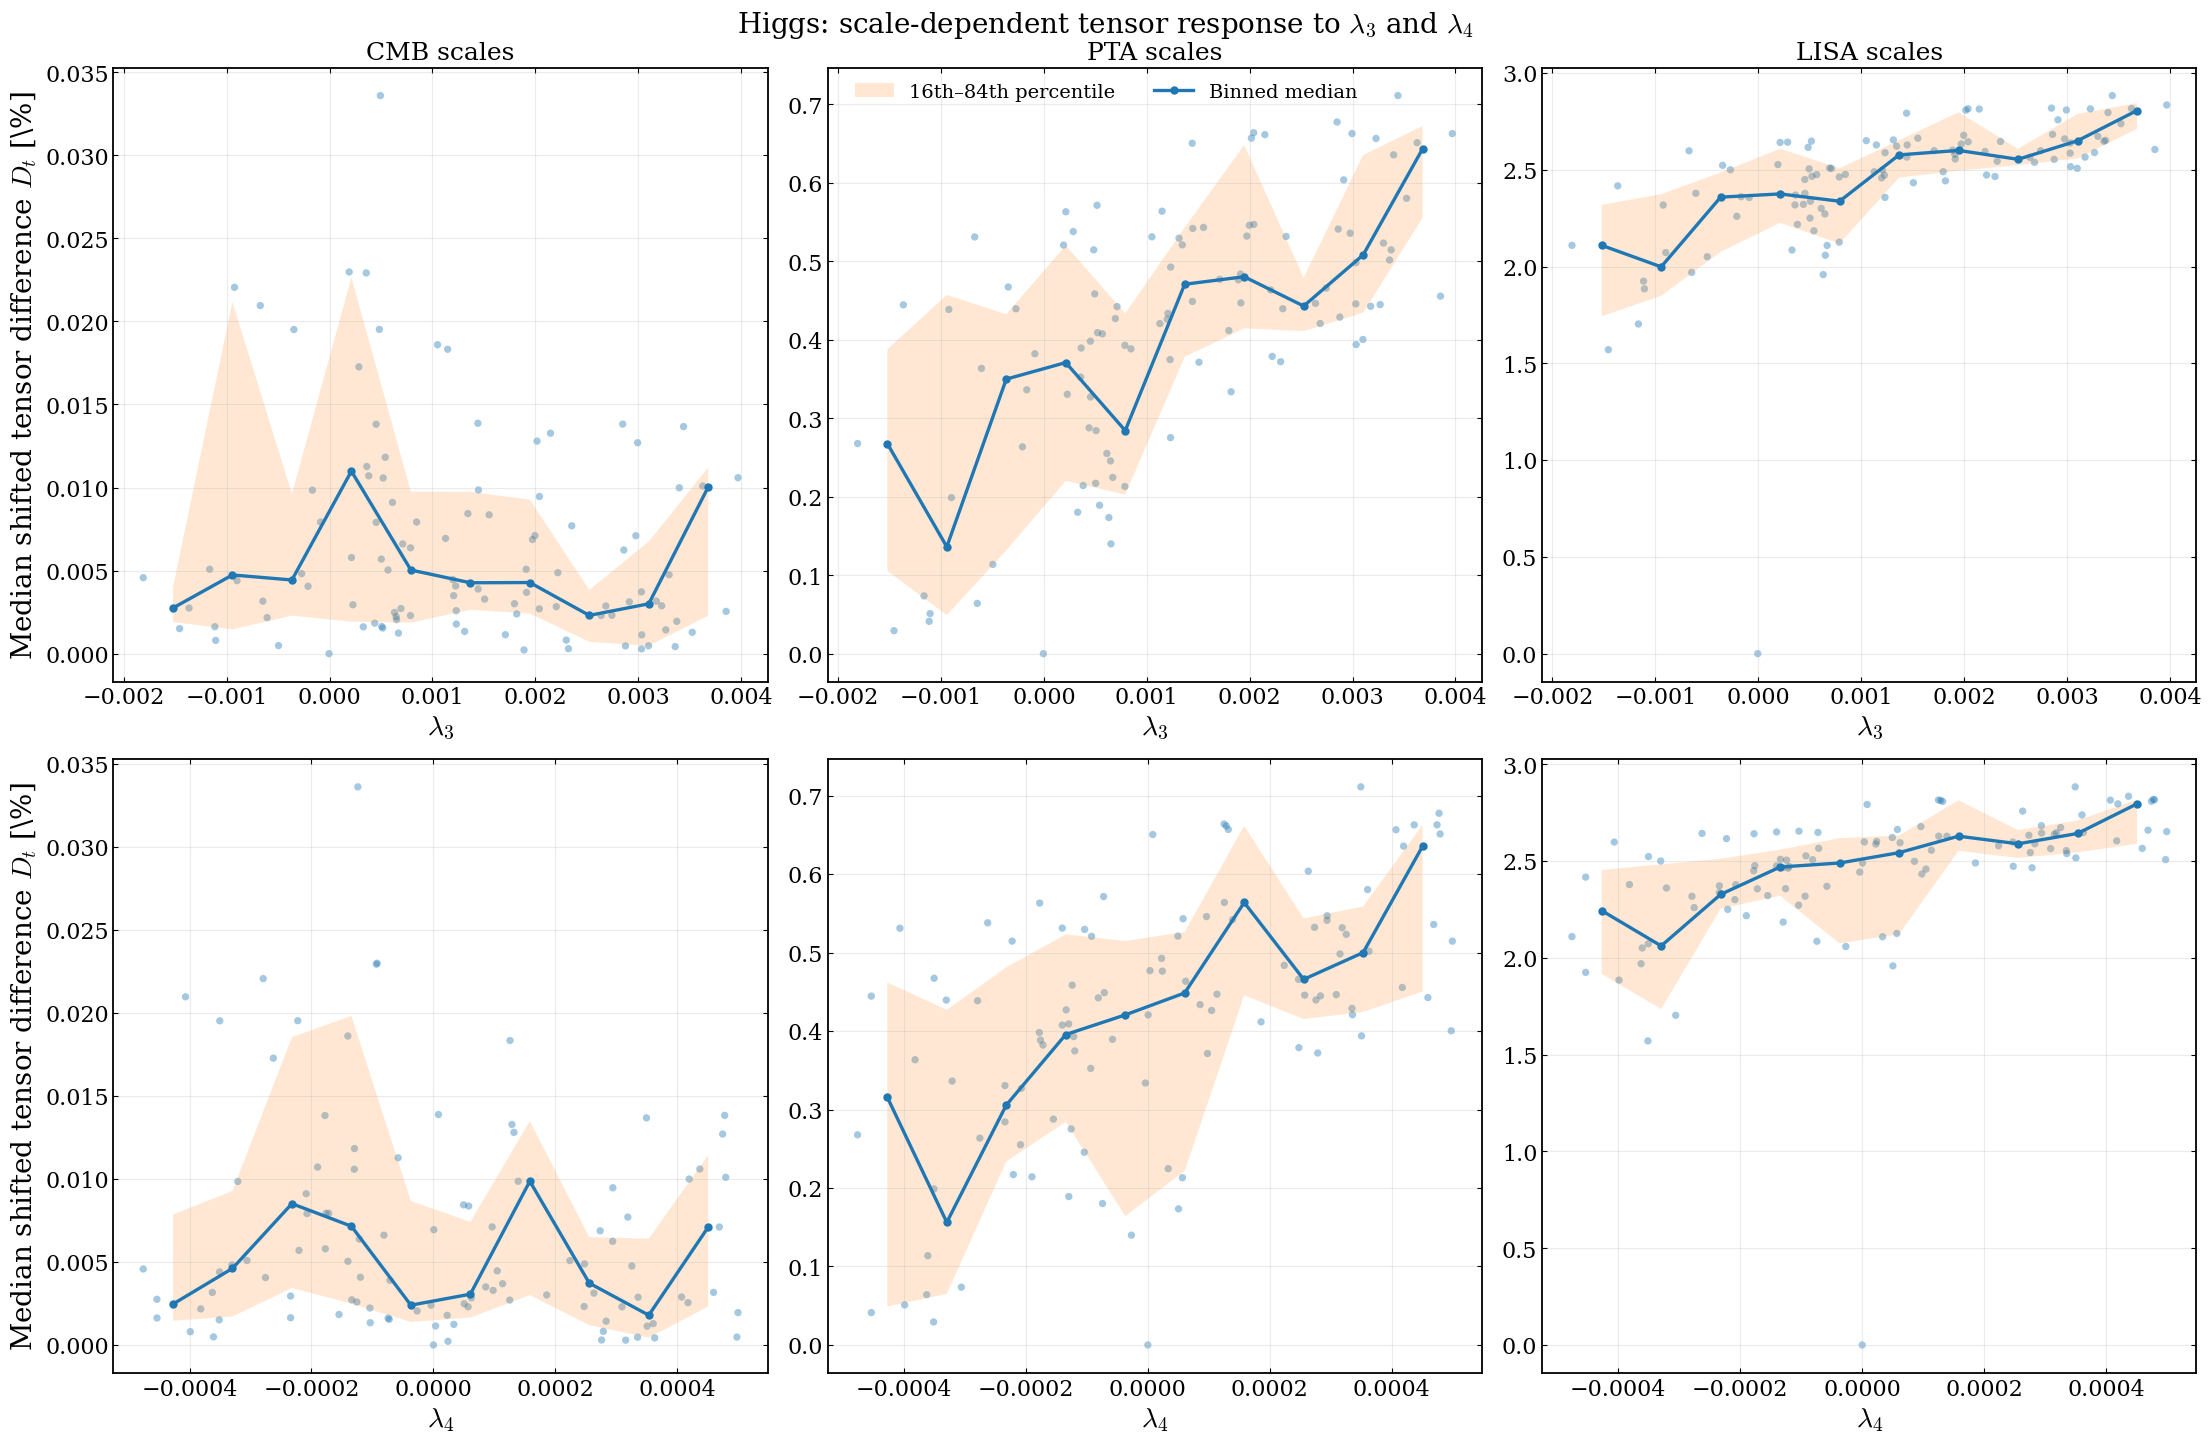

In [274]:
higgs_Dt_response, higgs_Dt_binned = (
    plot_Dt_vs_lam3_lam4_by_scale(
        tensor_band_df=tensor_band_results["higgs"],
        model_tag="higgs",
        n_bins=10,
        min_models_per_bin=3,
        save_name=(
            "paper_higgs_Dt_vs_lam3_lam4_"
            "CMB_PTA_LISA.pdf"
        ),
    )
)

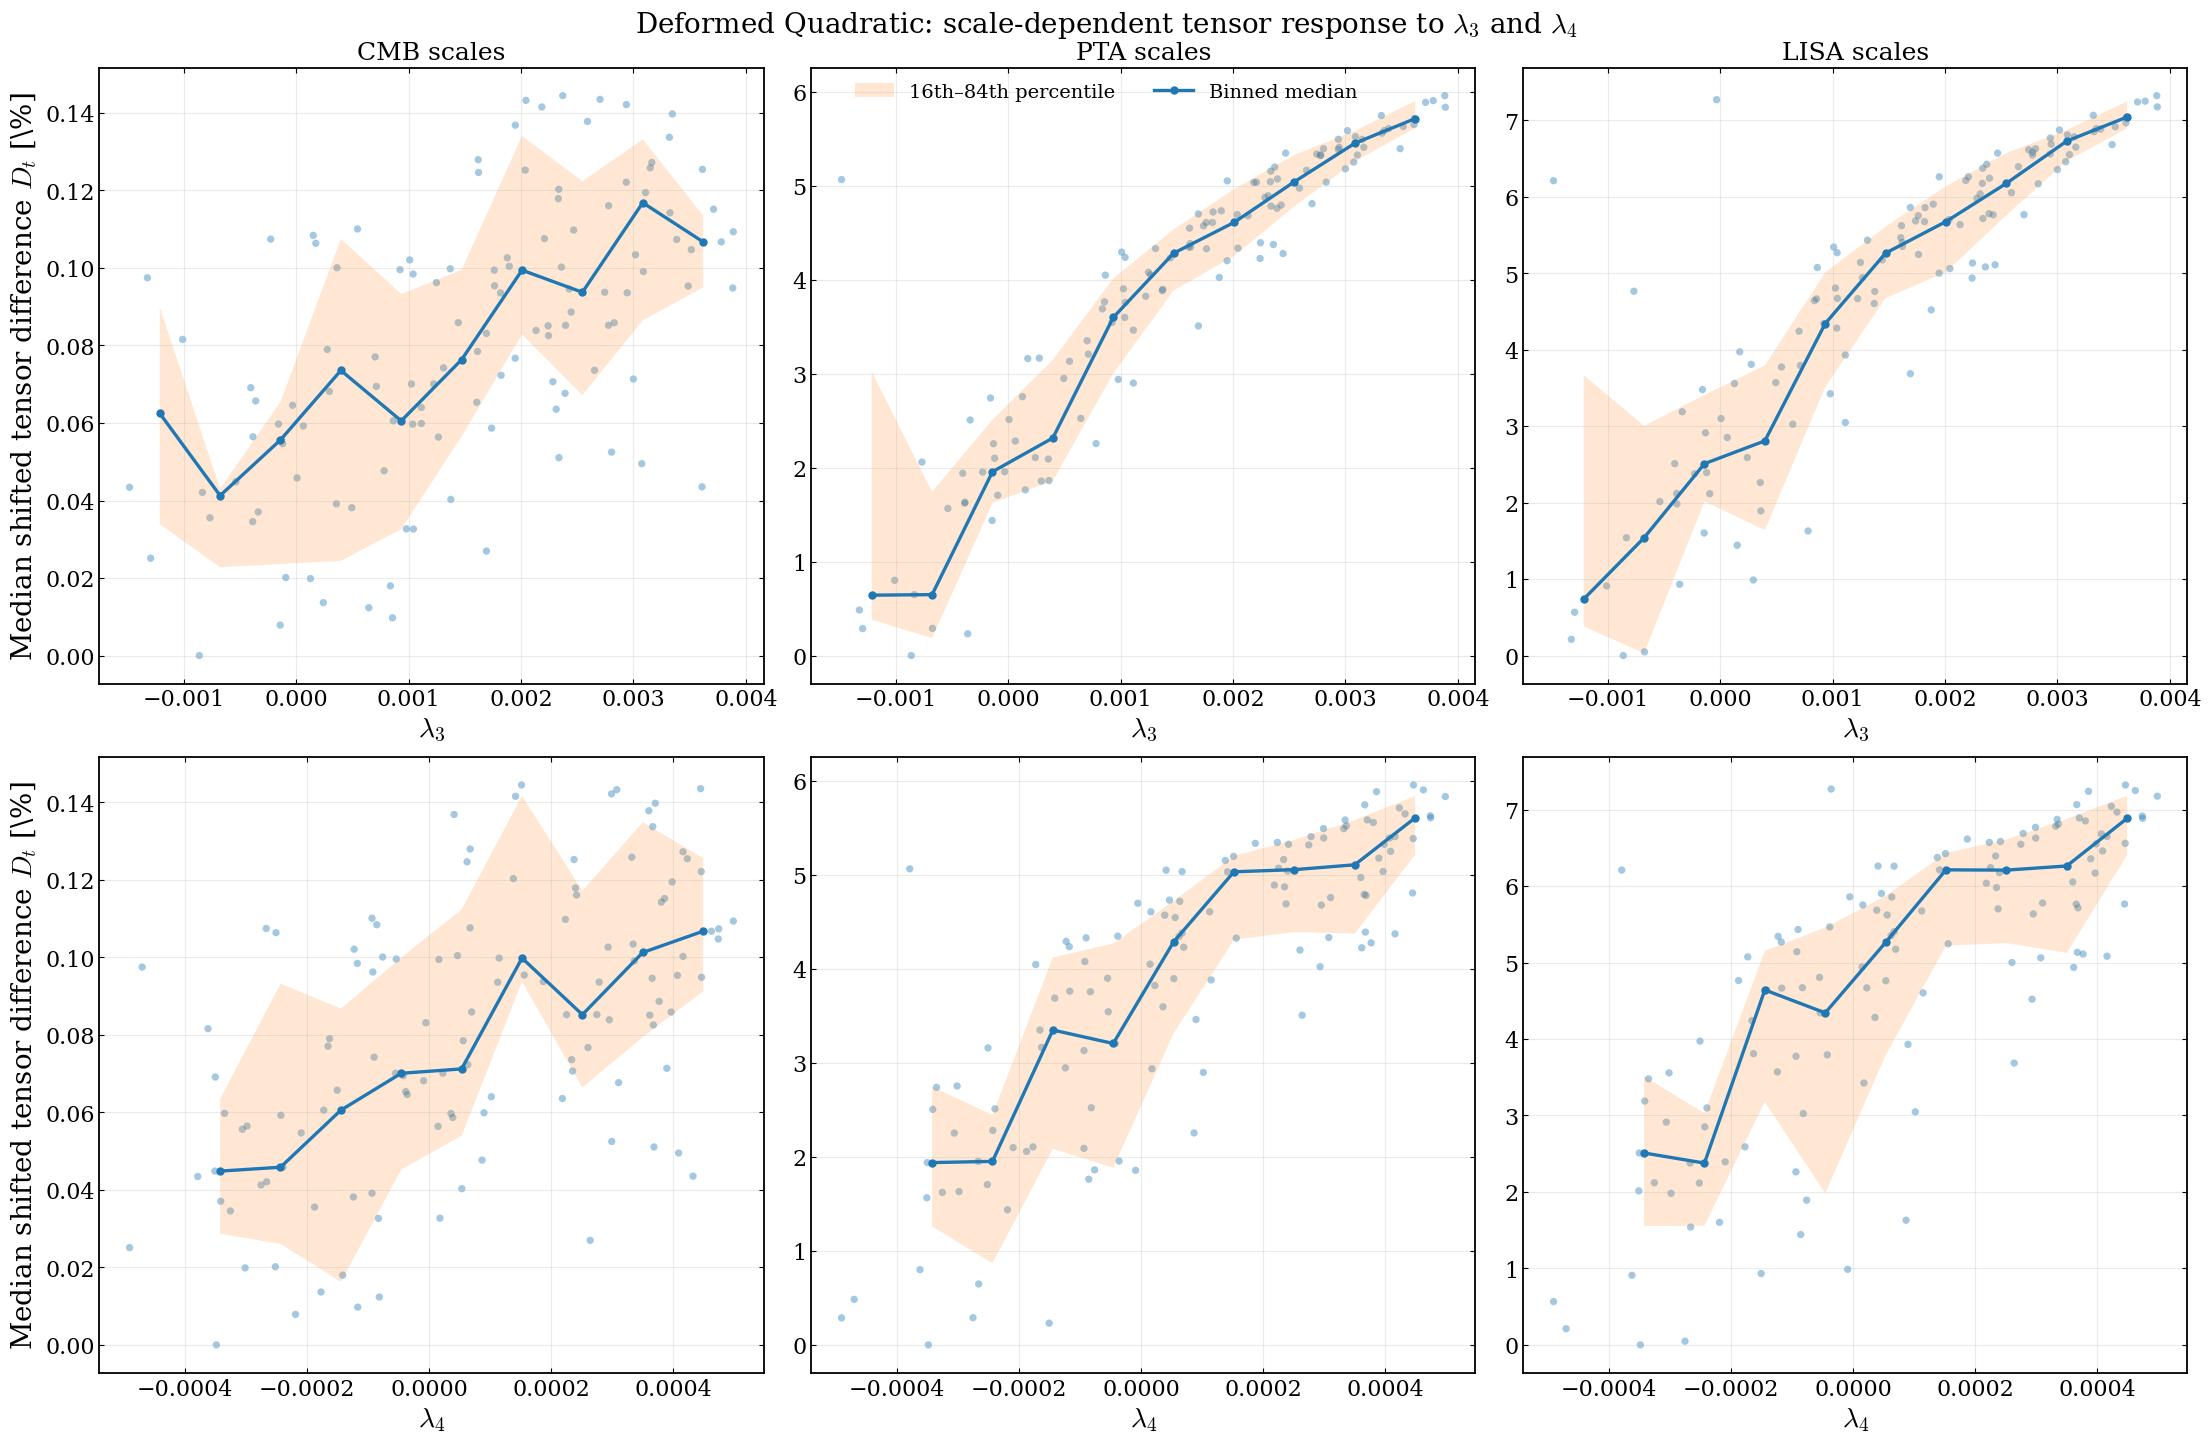

In [275]:
quad_Dt_response, quad_Dt_binned = (
    plot_Dt_vs_lam3_lam4_by_scale(
        tensor_band_df=tensor_band_results["nonhiggs"],
        model_tag="nonhiggs",
        n_bins=10,
        min_models_per_bin=3,
        save_name=(
            "paper_nonhiggs_Dt_vs_lam3_lam4_"
            "CMB_PTA_LISA.pdf"
        ),
    )
)